In [1]:
# load librairies
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import os
from os.path import join
import seaborn as sns
import scipy
import json

from functions import utils, io, hrm

In [2]:
# pick format to save figures : png for quick visualization, pdf for illustrator
save_as = 'png'
color_dict = {
    'DBS OFF': '#20a39e', 
    'DBS ON': '#ef5b5b', 
    'control': '#ffba49', 
    'preop': '#8E7DBE'
    }

# 1. Load all subjects data #

In [3]:
included_subjects = [
    #'preop001 mSST',  # preop group hasn't really be recorded, let's discard for now

    # 'C001 mSST', 'C002 mSST', # pilot participants
    'C003 mSST', 'C004 mSST', 'C006 mSST', 
    'C007 mSST','C008 mSST','C009 mSST', 
    'C010 mSST', 'C011 mSST', 'C012 mSST', 'C013 mSST',
    'C014 mSST', 'C015 mSST', 'C016 mSST',
    'sub006 DBS ON mSST', 'sub006 DBS OFF mSST', 
    #'sub007 DBS OFF mSST', # no ON session
    'sub008 DBS ON mSST', 'sub008 DBS OFF mSST', 
    'sub009 DBS ON mSST', 'sub009 DBS OFF mSST', 
    'sub011 DBS OFF mSST', 'sub011 DBS ON mSST', 
    'sub012 DBS ON mSST', 'sub012 DBS OFF mSST',
    #'sub013 DBS OFF mSST', # no ON session
    #'sub014 DBS ON mSST', # no OFF session
    'sub015 DBS OFF mSST', 'sub015 DBS ON mSST', 
    'sub017 DBS ON mSST',  'sub017 DBS OFF mSST', 
    'sub019 DBS ON mSST', 'sub019 DBS OFF mSST', 
    #'sub020 DBS ON mSST', # no OFF session
    'sub021 DBS OFF mSST', 'sub021 DBS ON mSST', 
    #'sub022 DBS ON mSST', # no OFF session
    'sub023 DBS OFF mSST', 'sub023 DBS ON mSST',
    'sub024 DBS ON mSST', 'sub024 DBS OFF mSST',
    'sub025 DBS ON mSST', 'sub025 DBS OFF mSST',
    'sub027 DBS ON mSST', 'sub027 DBS OFF mSST',
    'sub028 DBS OFF mSST', 'sub028 DBS ON mSST',
    'sub029 DBS ON mSST', 'sub029 DBS OFF mSST',
    #'sub030 DBS ON mSST', 'sub030 DBS OFF mSST', # didn't finish OFF session, symptoms too strong
    #'sub031 DBS OFF mSST', # didn't finish ON session, too tired, didn't want to continue
    'sub032 DBS ON mSST', 'sub032 DBS OFF mSST',
    'sub033 DBS ON mSST', 'sub033 DBS OFF mSST'
    ]

# prepare a list to store subjects that should be excluded
excluded_subjects = []

# create subdictionnaries for each subject:
results_dict = {}
for subject in included_subjects:
    results_dict[subject] = {}

In [4]:
# set paths
# onedrive_path = utils._get_onedrive_path()
working_path = os.path.dirname(os.getcwd())

data_path = json.load(open(join(working_path, 'scripts', 'SETTINGS.json')))["DATA_STORAGE_PATH"]
behav_data_path = join(data_path, "behav")

results_path = json.load(open(join(working_path, 'scripts', 'SETTINGS.json')))["RESULTS_SAVING_PATH"]
if not os.path.exists(results_path):
    os.makedirs(results_path)  # Create the directory if it doesn't exist
# results_path = join(working_path, "results")

behav_results_saving_path = join(results_path, "behav_results", "hrm_assumptions_checking")
if not os.path.isdir(behav_results_saving_path):
    os.makedirs(behav_results_saving_path)

In [5]:
# load behavioral data (csv files)
data = io.load_behav_data(included_subjects, behav_data_path)

C003 mSST
C004 mSST
C006 mSST
C007 mSST
C008 mSST
C009 mSST
C010 mSST
C011 mSST
C012 mSST
C013 mSST
C014 mSST
C015 mSST
C016 mSST
sub006 DBS ON mSST
sub006 DBS OFF mSST
sub008 DBS ON mSST
sub008 DBS OFF mSST
sub009 DBS ON mSST
sub009 DBS OFF mSST
sub011 DBS OFF mSST
sub011 DBS ON mSST
sub012 DBS ON mSST
sub012 DBS OFF mSST
sub015 DBS OFF mSST
sub015 DBS ON mSST
sub017 DBS ON mSST
sub017 DBS OFF mSST
sub019 DBS ON mSST
sub019 DBS OFF mSST
sub021 DBS OFF mSST
sub021 DBS ON mSST
sub023 DBS OFF mSST
sub023 DBS ON mSST
sub024 DBS ON mSST
sub024 DBS OFF mSST
sub025 DBS ON mSST
sub025 DBS OFF mSST
sub027 DBS ON mSST
sub027 DBS OFF mSST
sub028 DBS OFF mSST
sub028 DBS ON mSST
sub029 DBS ON mSST
sub029 DBS OFF mSST
sub032 DBS ON mSST
sub032 DBS OFF mSST
sub033 DBS ON mSST
sub033 DBS OFF mSST


# 2. Extract main statistics and values for each subject and compile in a dictionnary #

In [6]:
stats = utils.extract_stats(data)

# store stats in a json file
# If no file was found, create a new JSON file
filename = "stats.json"
file_path = os.path.join(results_path, filename)
if not os.path.isfile(file_path):
   with open(file_path, "w", encoding="utf-8") as file:
           json.dump({}, file, indent=4)

# Save the updated or new JSON file
with open(file_path, "w", encoding="utf-8") as file:
    json.dump(stats, file, indent=4)


GO omissions for C003 mSST: 26 out of 240 go trials. Replacing with mximum available RT = 1000ms.
GO omissions for C004 mSST: 4 out of 180 go trials. Replacing with mximum available RT = 1000ms.
GO omissions for C006 mSST: 14 out of 240 go trials. Replacing with mximum available RT = 1000ms.
GO omissions for C007 mSST: 9 out of 180 go trials. Replacing with mximum available RT = 1000ms.
GO omissions for C008 mSST: 7 out of 180 go trials. Replacing with mximum available RT = 1000ms.
GO omissions for C009 mSST: 4 out of 180 go trials. Replacing with mximum available RT = 1000ms.
GO omissions for C010 mSST: 20 out of 180 go trials. Replacing with mximum available RT = 1000ms.
GO omissions for C011 mSST: 18 out of 180 go trials. Replacing with mximum available RT = 1000ms.
GO omissions for C012 mSST: 24 out of 180 go trials. Replacing with mximum available RT = 1000ms.
GO omissions for C013 mSST: 20 out of 180 go trials. Replacing with mximum available RT = 1000ms.
GO omissions for C014 mS

In [ ]:
# # Initialize empty dictionaries
# stats_OFF = {}
# stats_ON = {}
# stats_CONTROL = {}
# stats_PREOP = {}

# # Loop through the original dictionary and filter into sub-dictionaries
# for key, value in stats.items():
#     if "OFF" in key:
#         stats_OFF[key] = value
#     elif "ON" in key:
#         stats_ON[key] = value
#     elif "C" in key:
#         stats_CONTROL[key] = value
#     elif "preop" in key:
#         stats_PREOP[key] = value

# 3. TEST 1: independence assumption of the horse race model #

"""

Action initiation and action inhibition are two independent processes --> assumption of independence.

The independence assumption predicts that 
the RT for unsuccessful STOP trials should be faster than GO trials 
the RT for unsuccessful STOP trials should increase with SSD

“To accept the assumption with confidence, however, we need to show that the data are inconsistent with alternatives to independence.”
(Logan et al., 1984).


“The first major alternative to independence is the possibility that the stopping process and the primary-task process race against each other but share limited resources, so that the two processes cannot function at the same time without interfering with one another.”
“The primary-task process would be operating with less resources on stop-signal trials than on no-signal trials, so signal-respond reaction times should be substantially longer than no-signal reaction times. 

-->  (a) If (u)GS RT > GO RT , the independence assumption is violated.

Also, the sooner the stop signal occurred, the sooner the primary task would have to operate with reduced resources, and so signal-respond reaction times should be longer the earlier the delay (i.e., signal-respond reaction times should decrease with stop-signal delay).”

-->  (b) If (u)GS RT with small SSD > (u)GS RT with long SSD, the independence assumption is violated


Also important, 

(c) the omission rate on GO trials should be lower than 15%, otherwise it becomes difficult to know whether the "successful STOP trials" were really successful STOPS and not just "NOT GOING". So, success rate for GO, GC, and GF trials should be at least 75%, and success rate on GStop trials should not deviate substantially from 50%.

"""

## 3.1. Single session level ##

Testing independence assumption at the single session level...


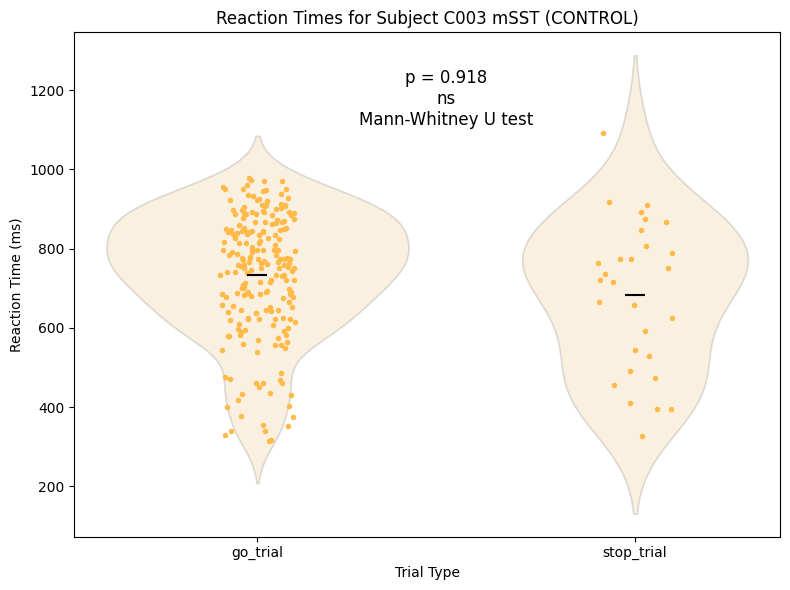

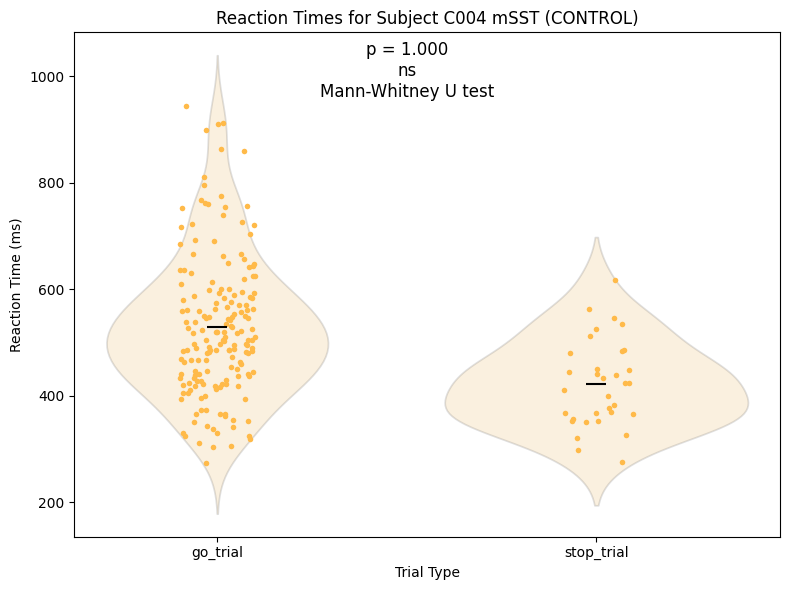

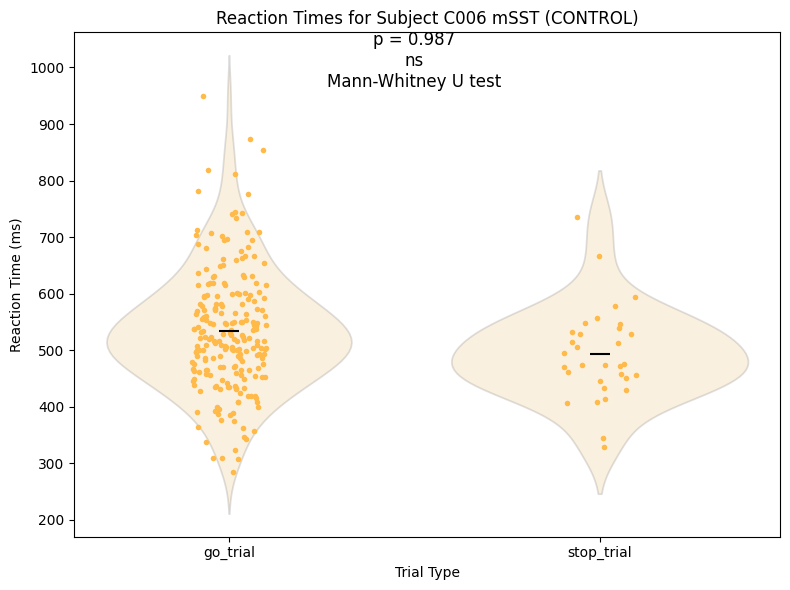

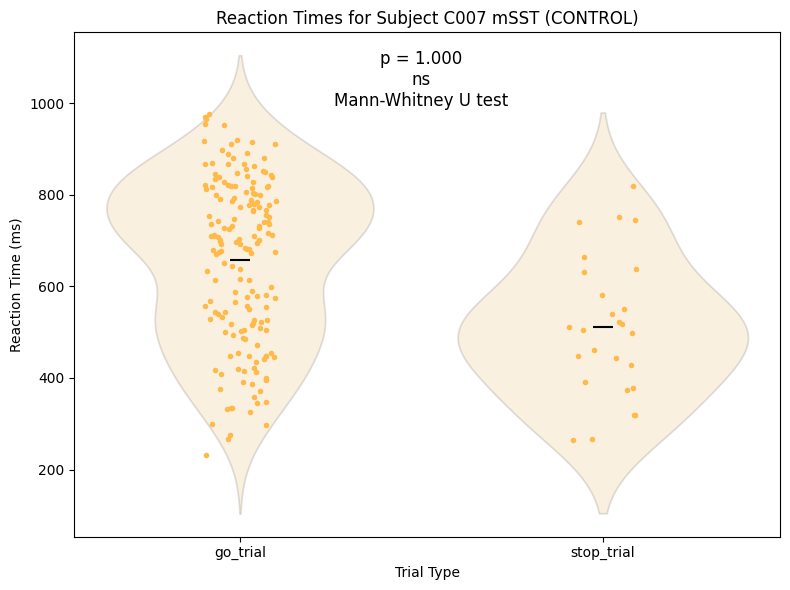

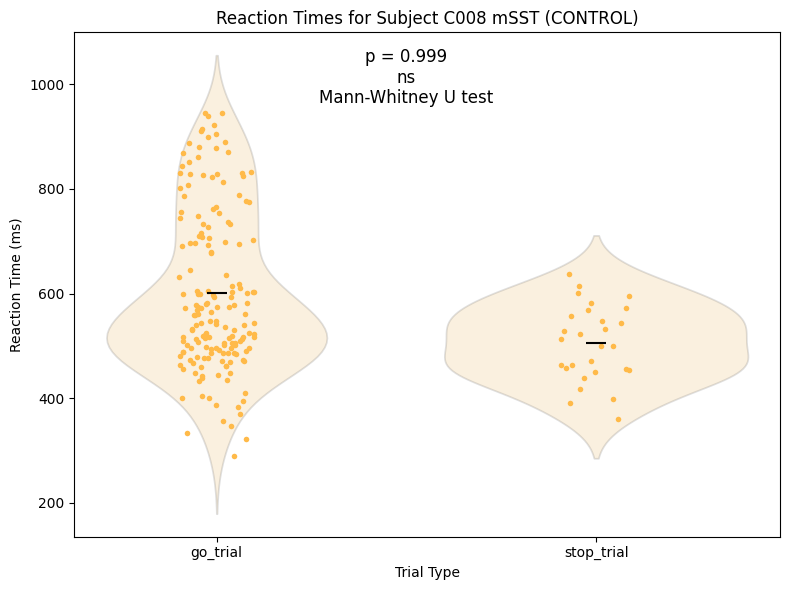

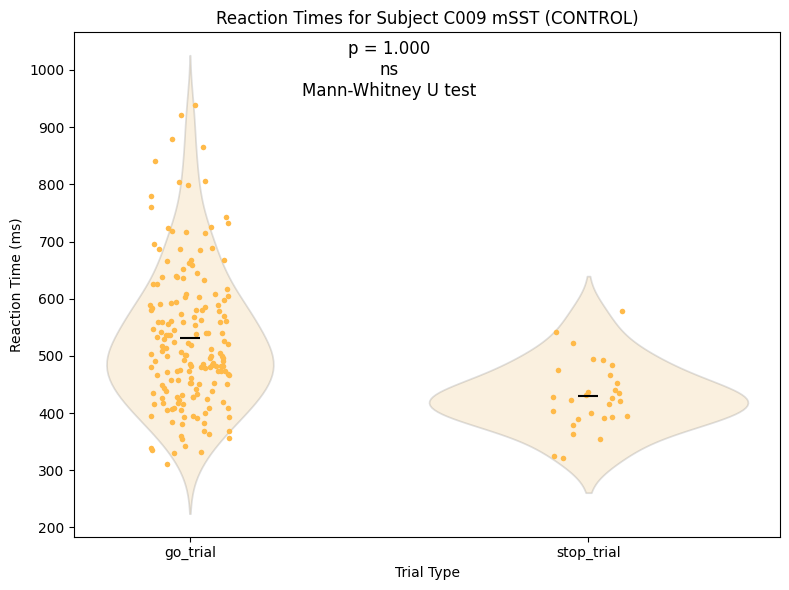

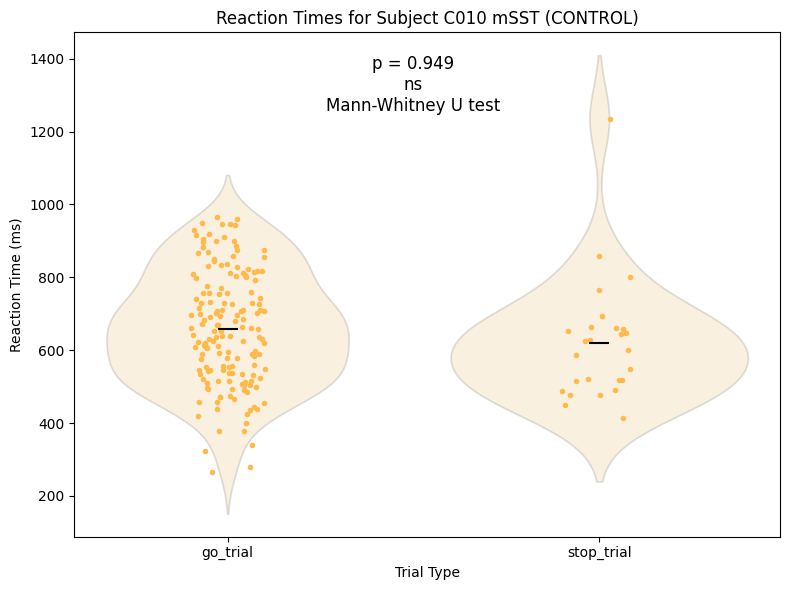

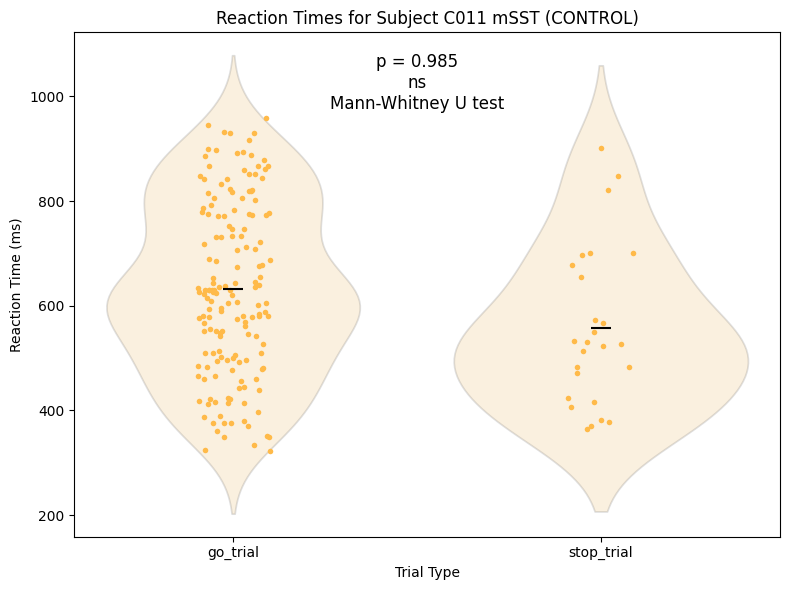

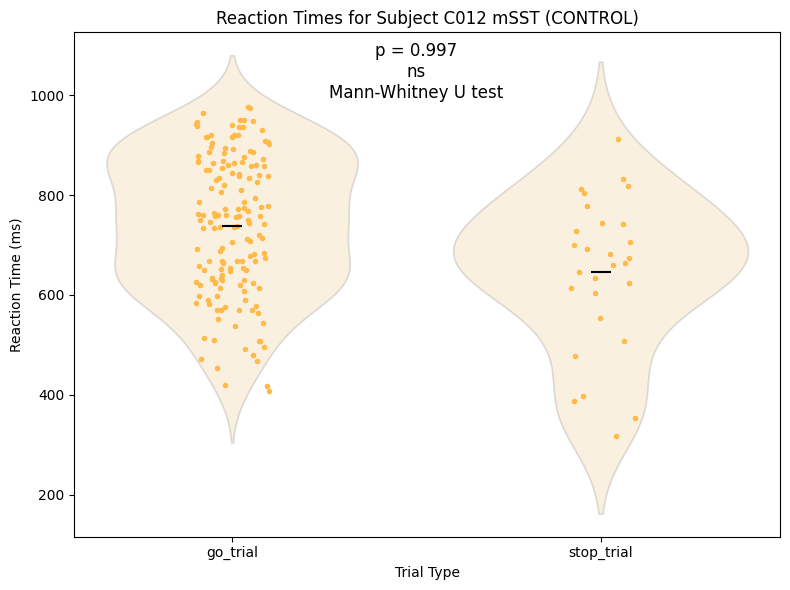

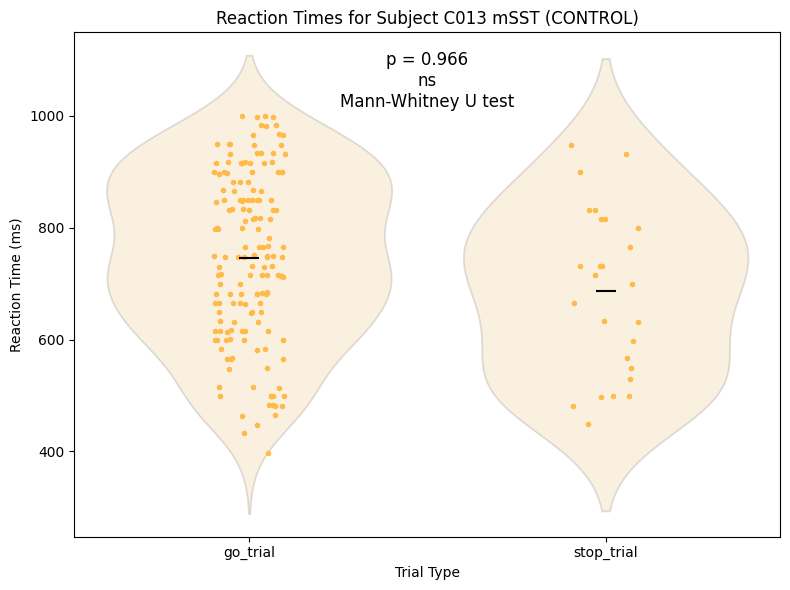

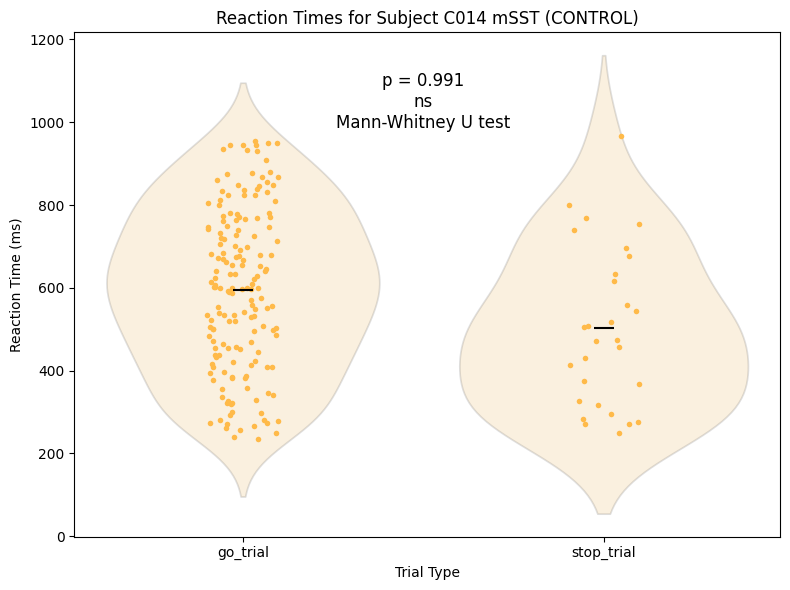

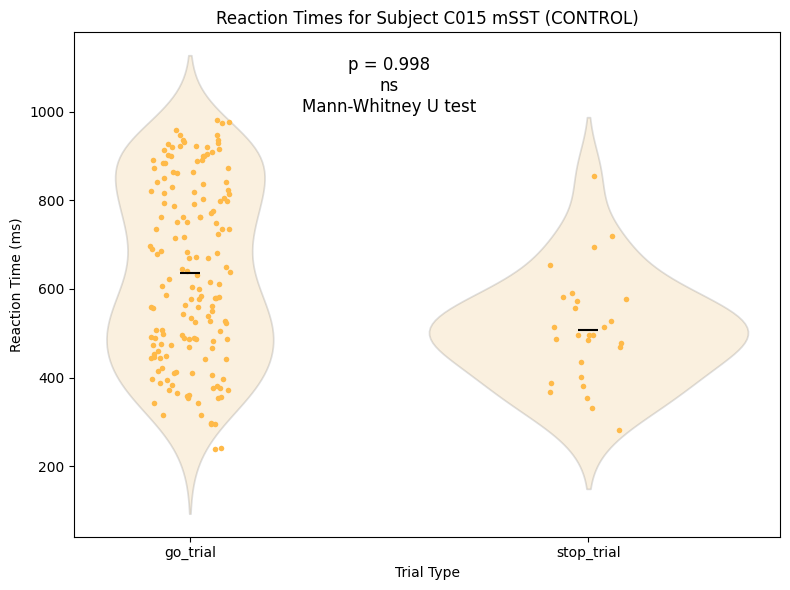

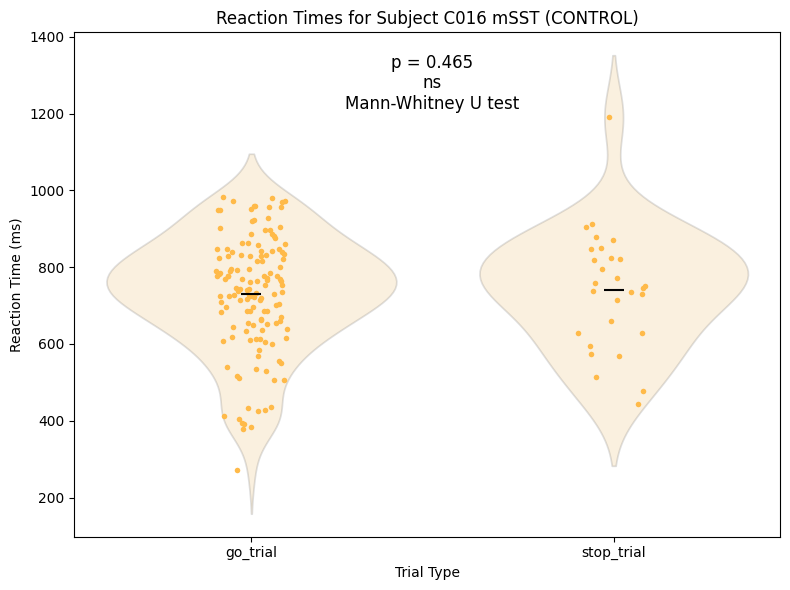

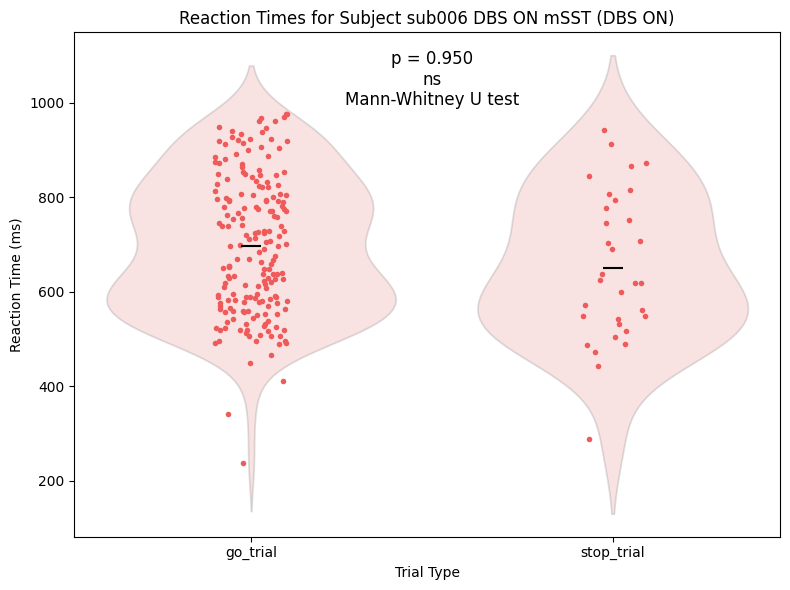

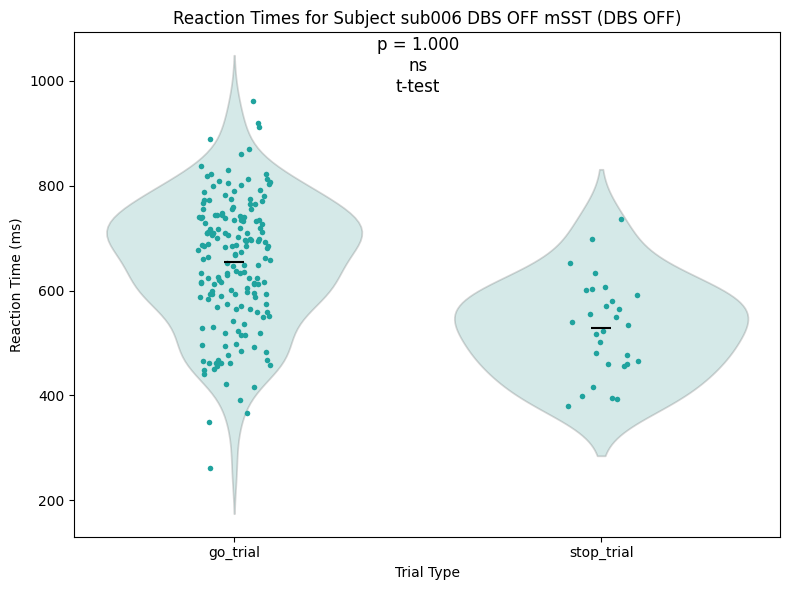

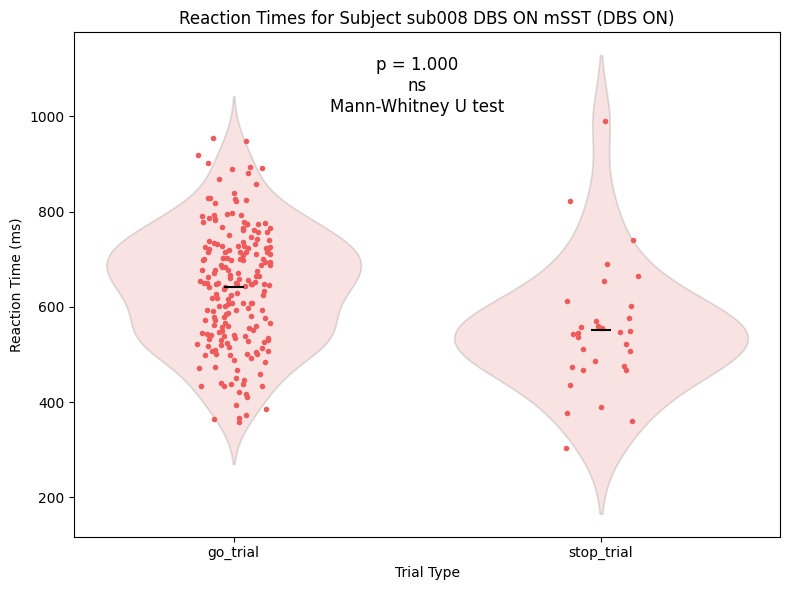

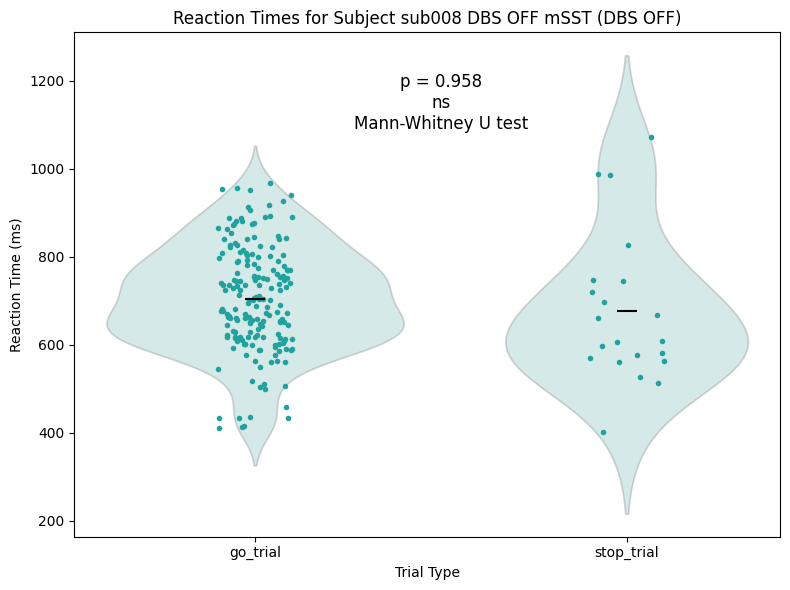

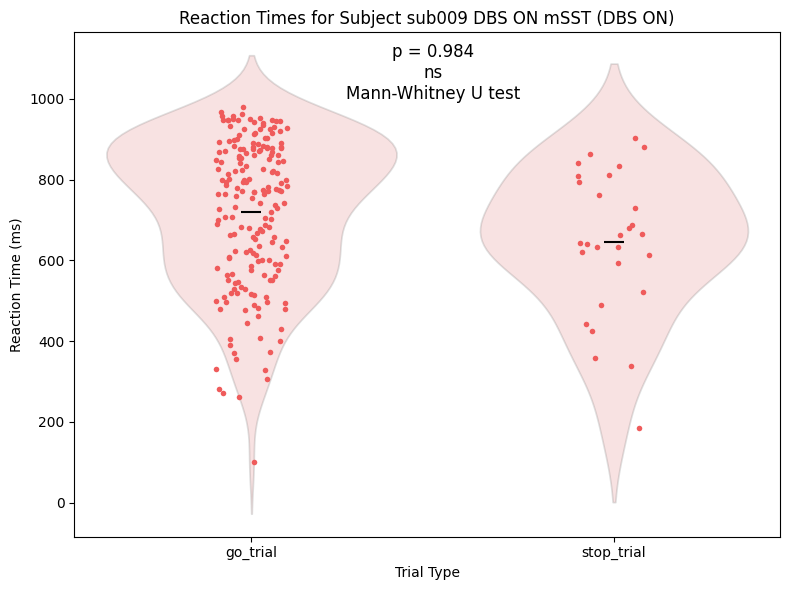

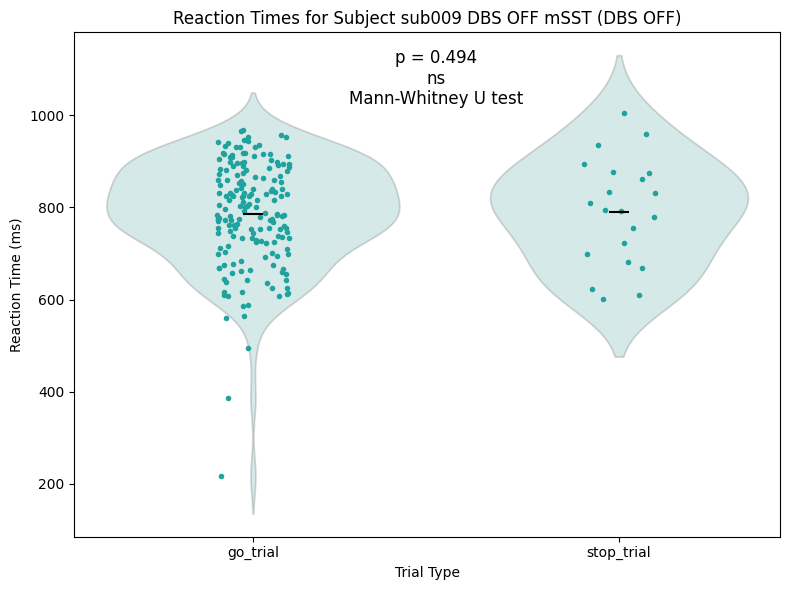

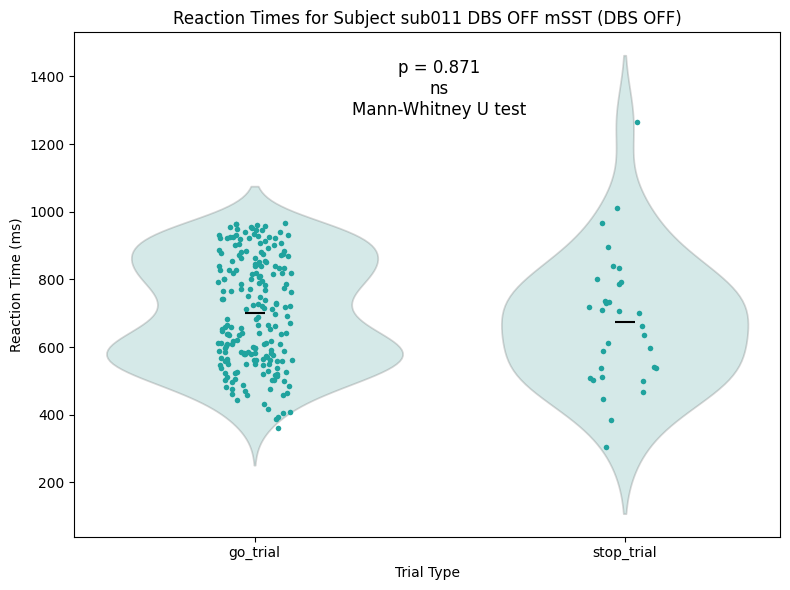

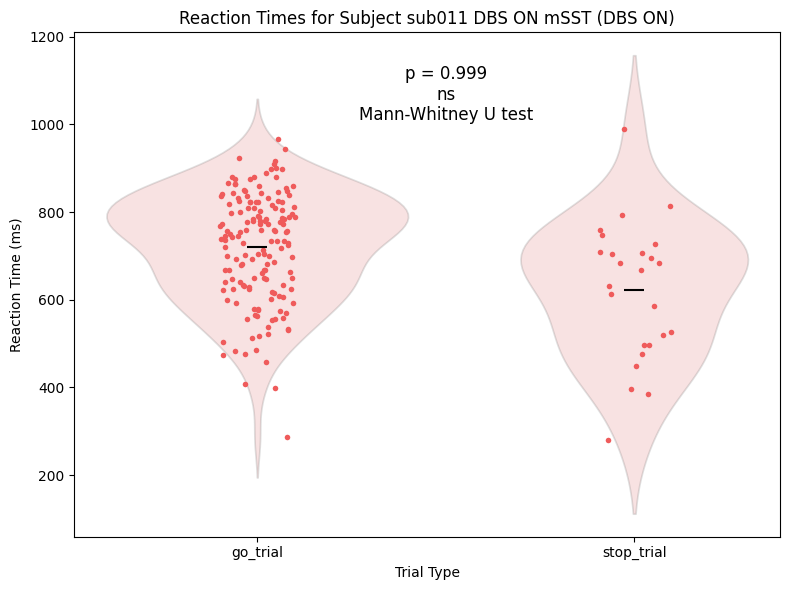

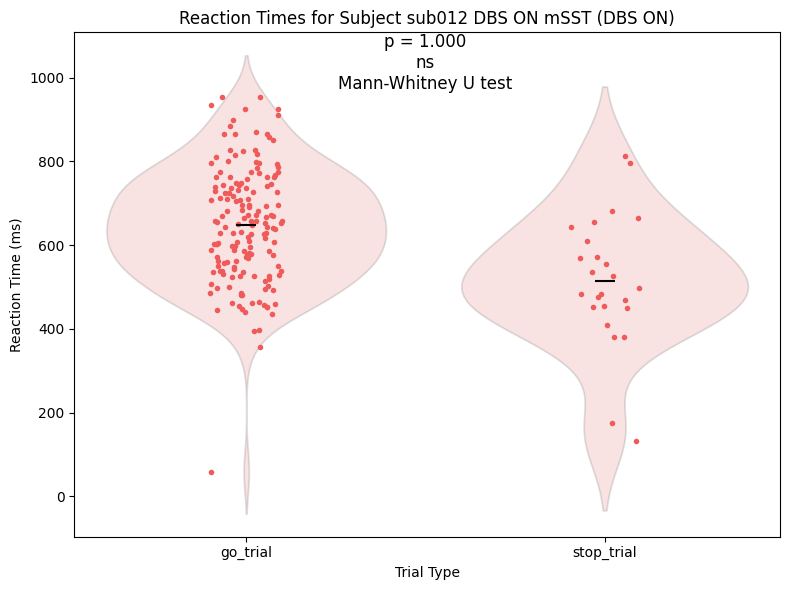

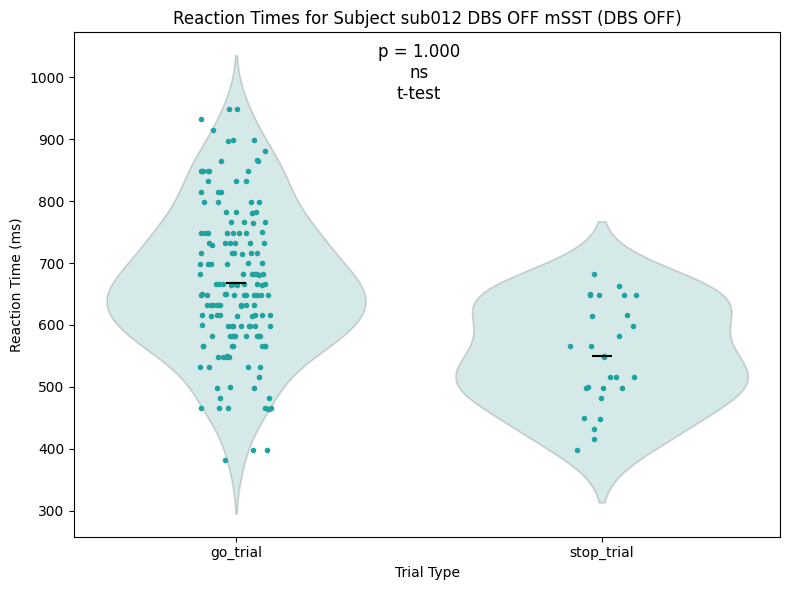

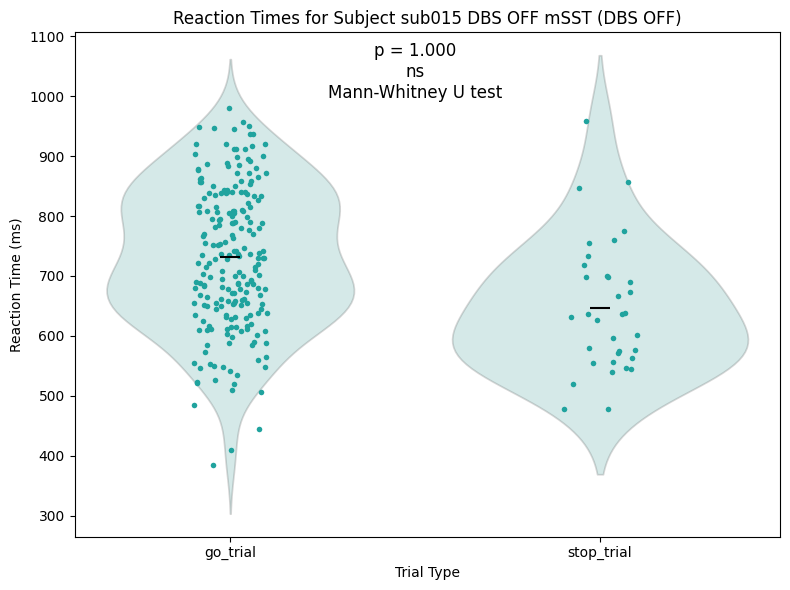

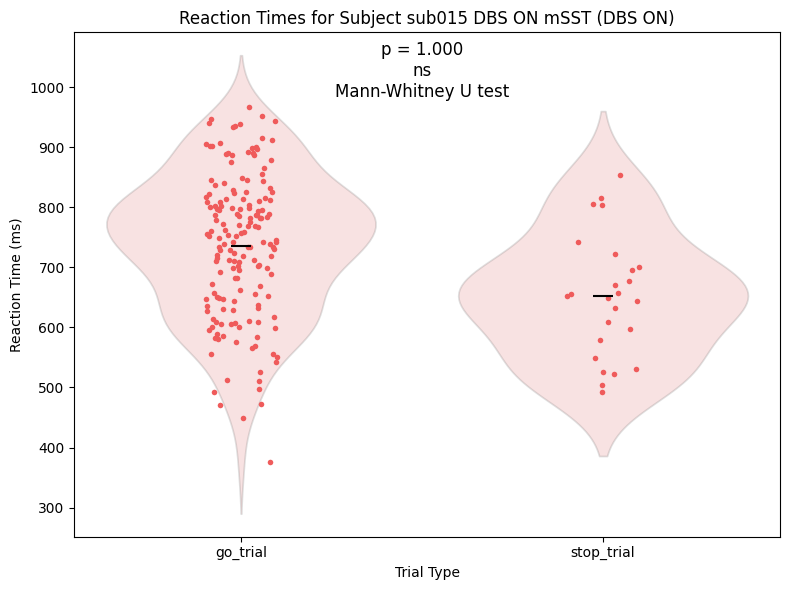

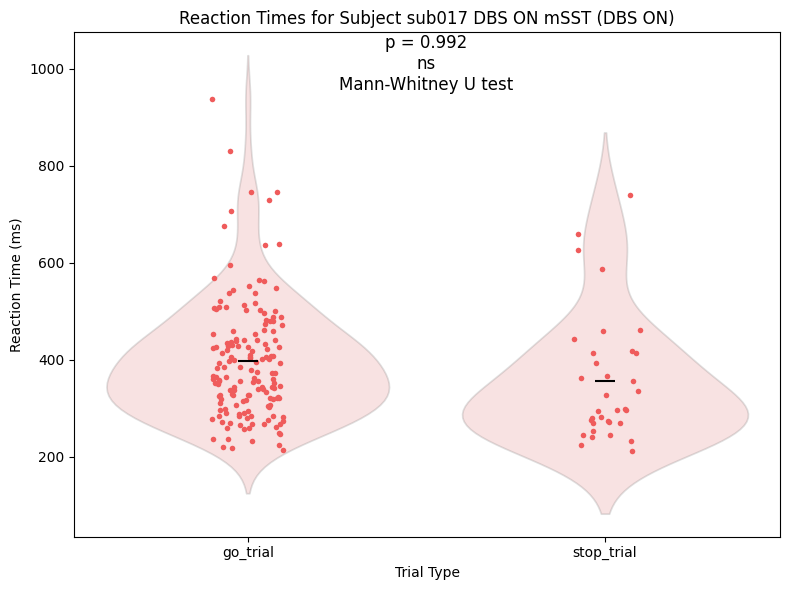

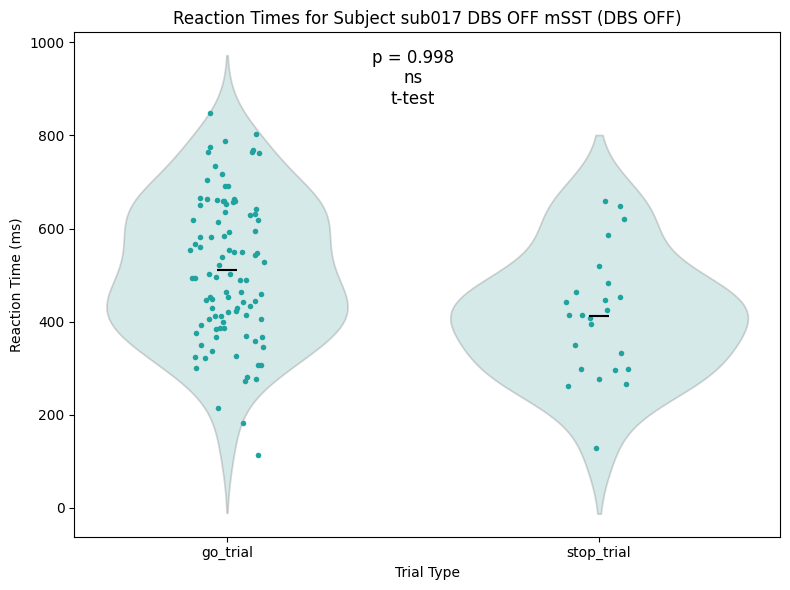

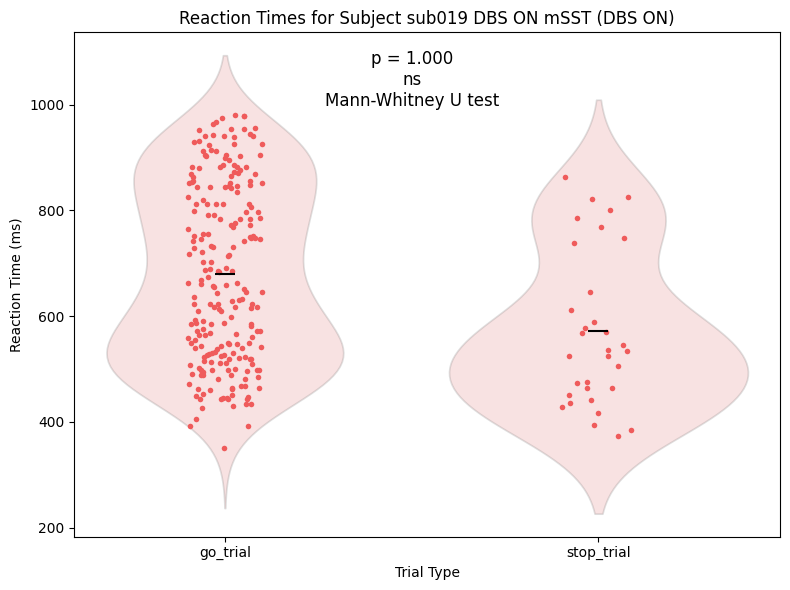

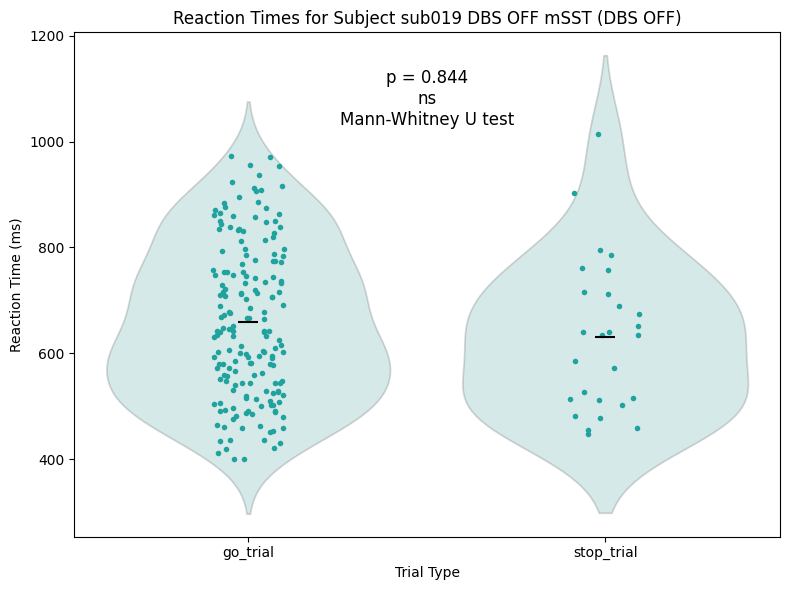

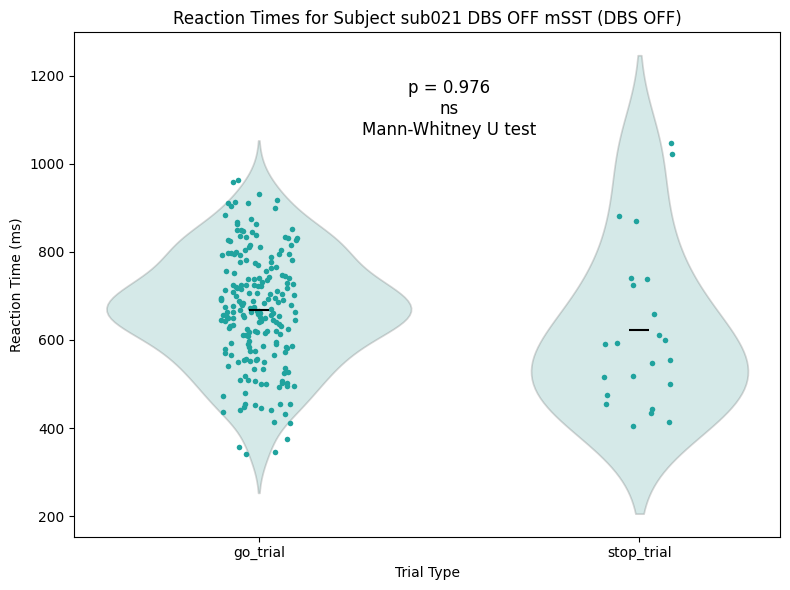

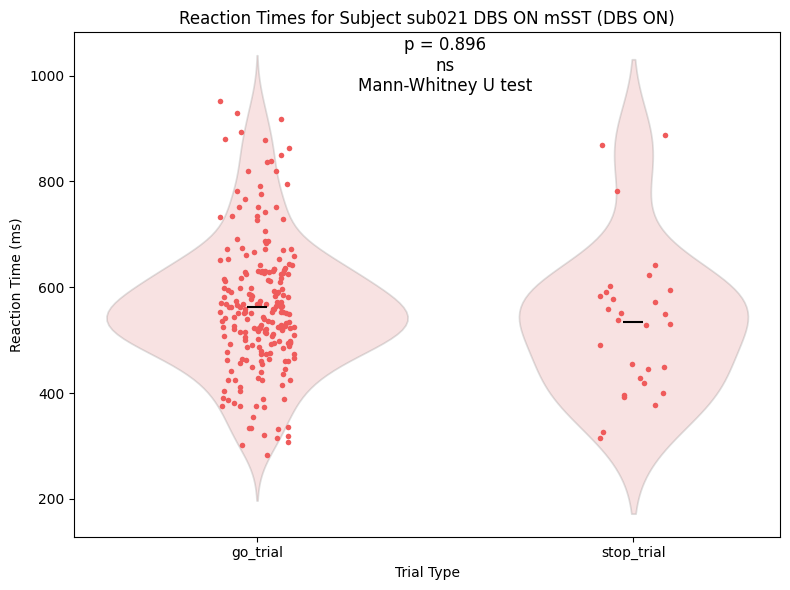

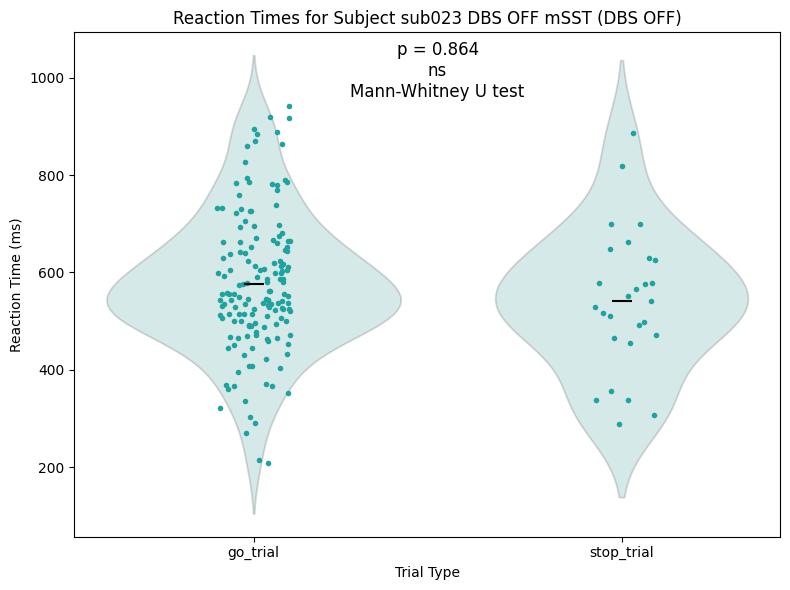

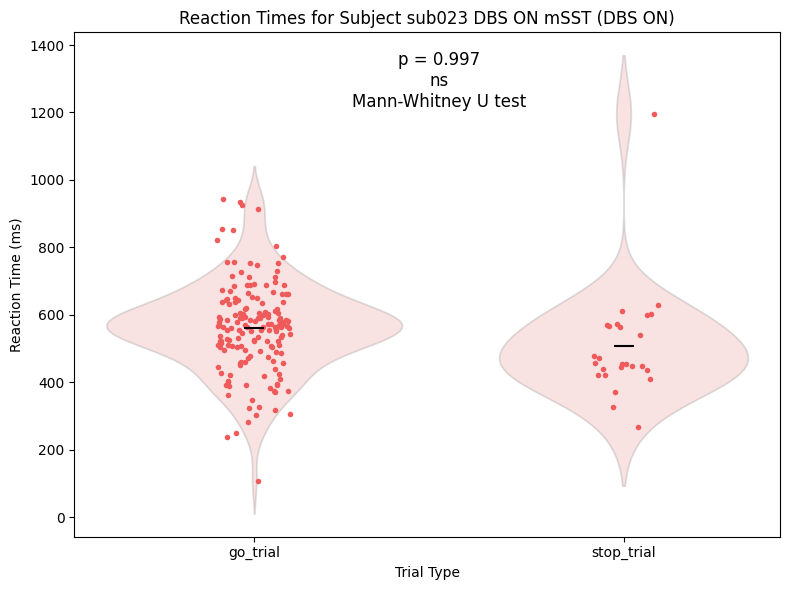

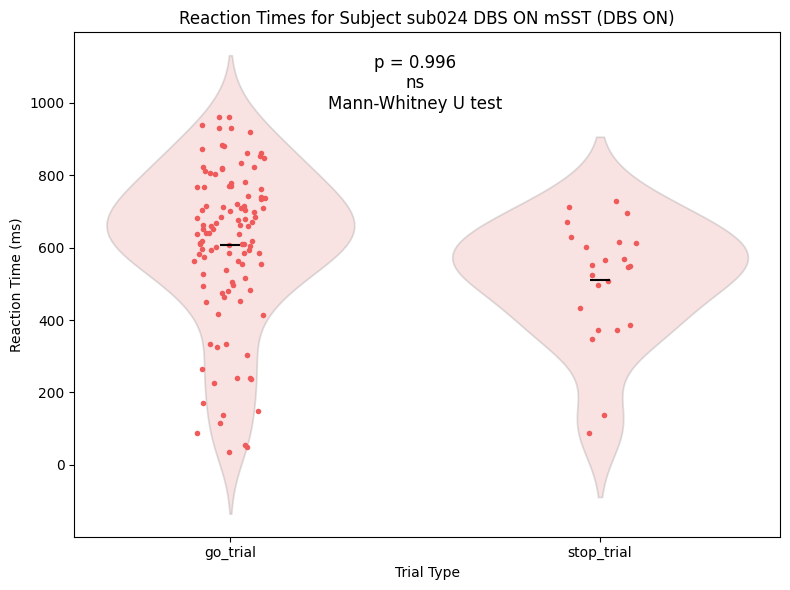

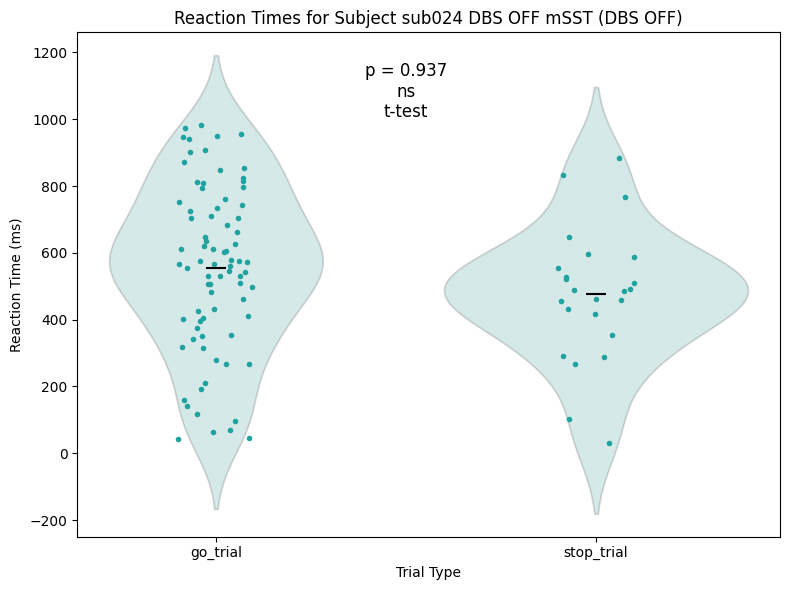

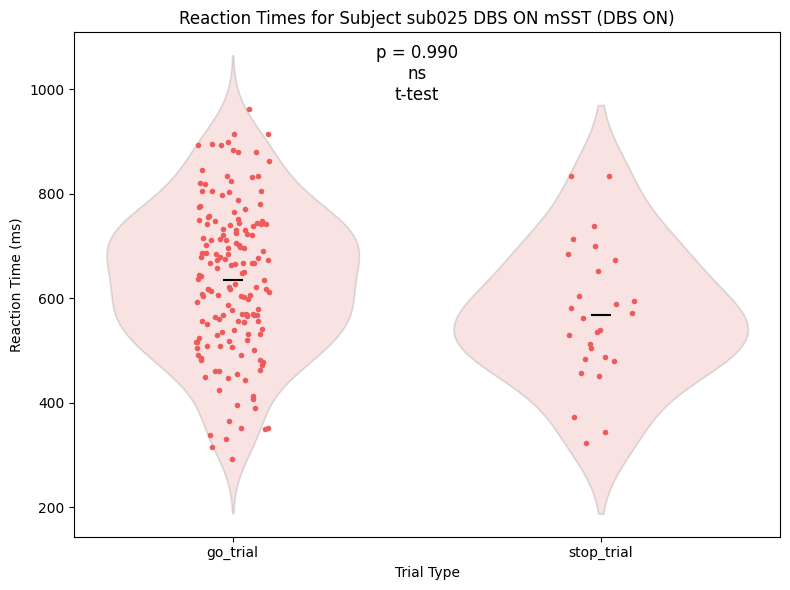

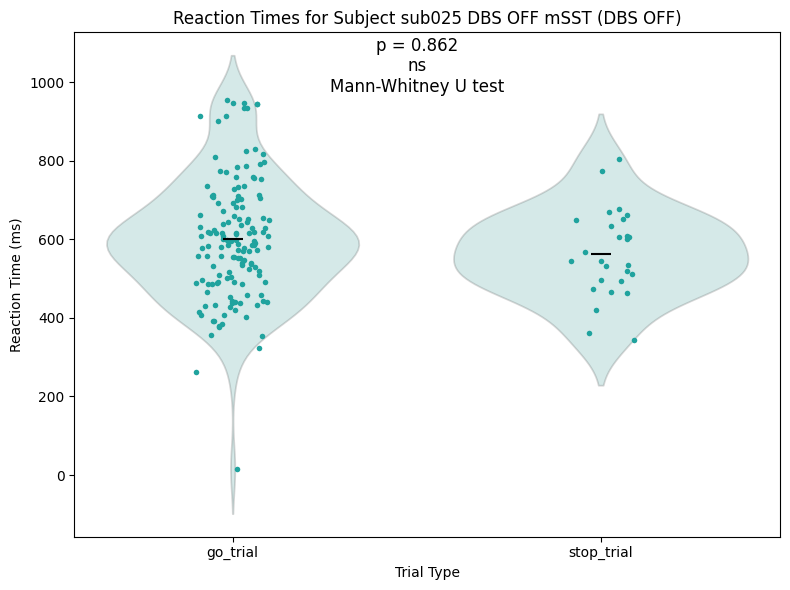

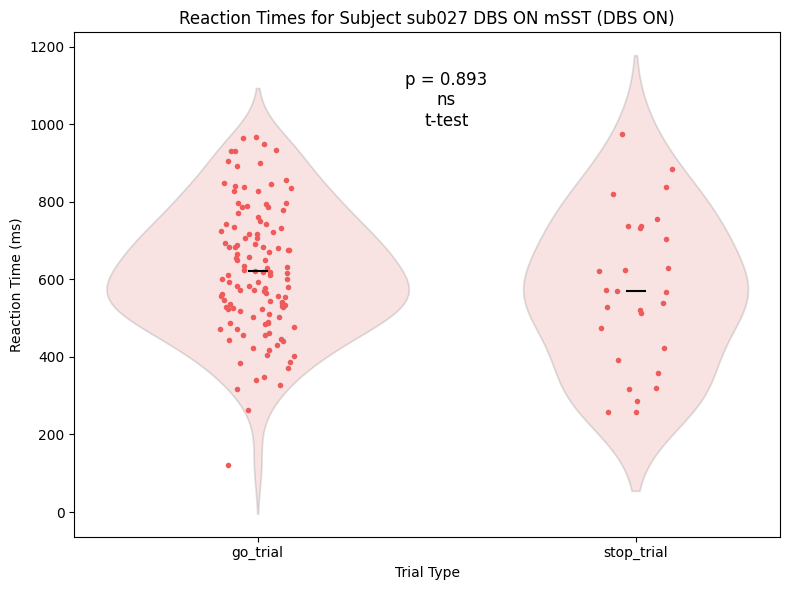

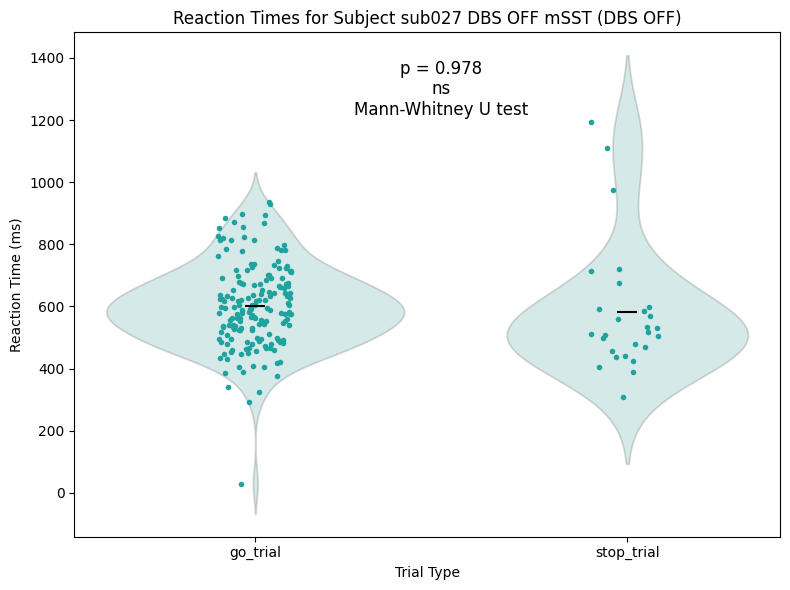

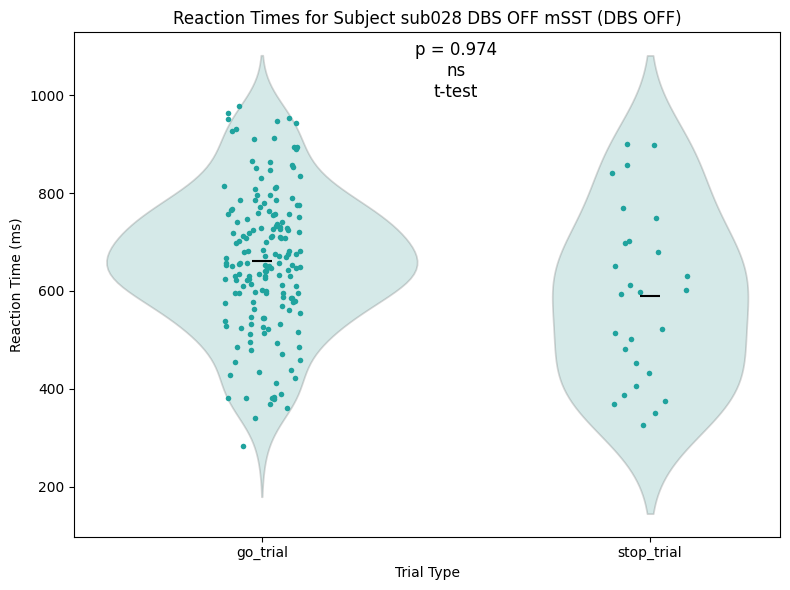

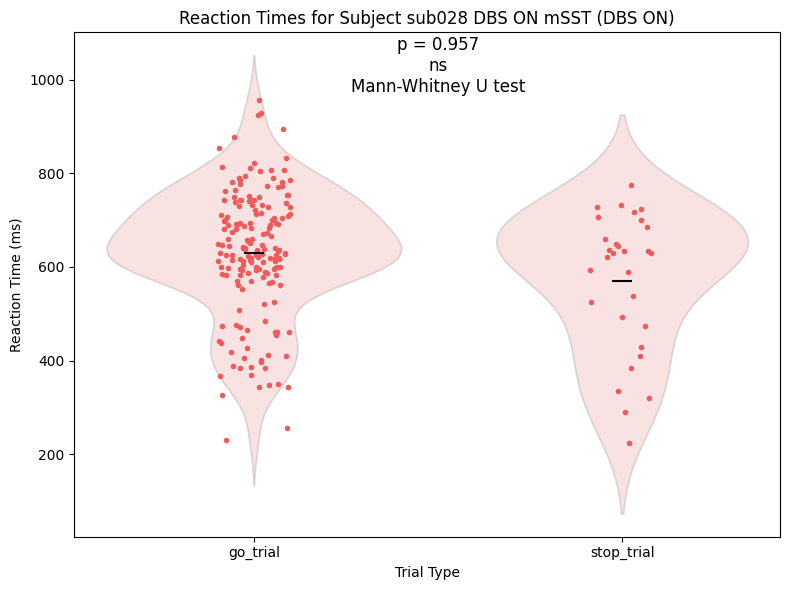

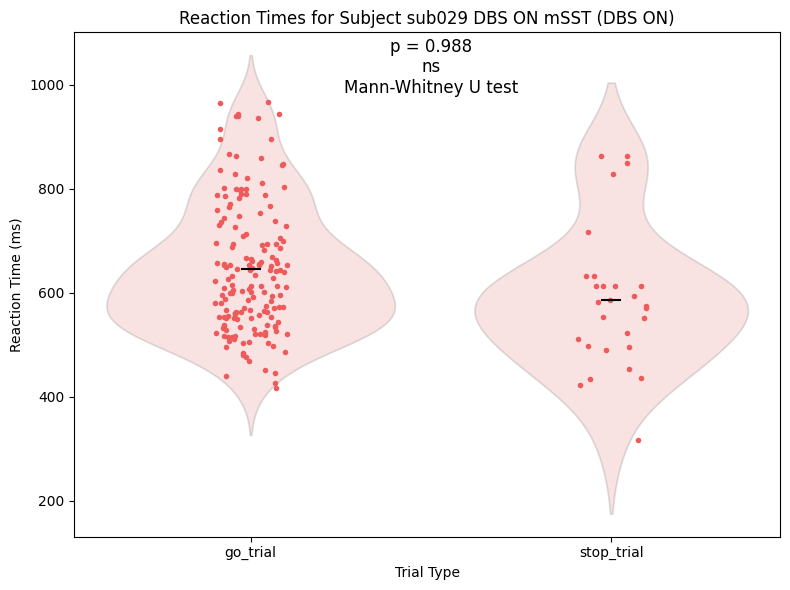

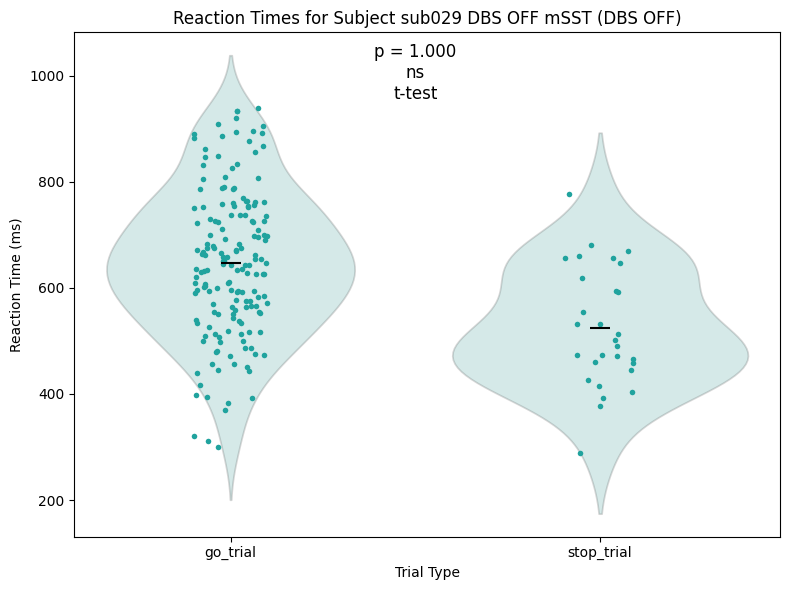

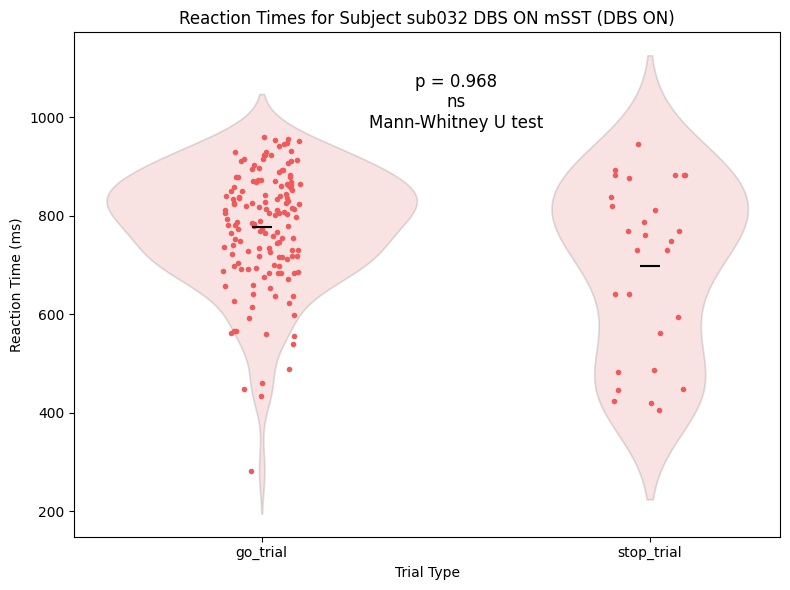

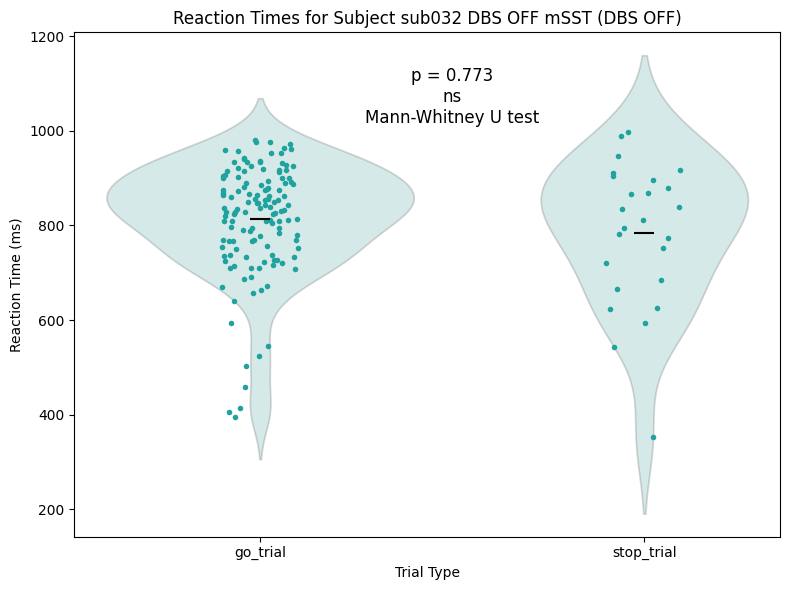

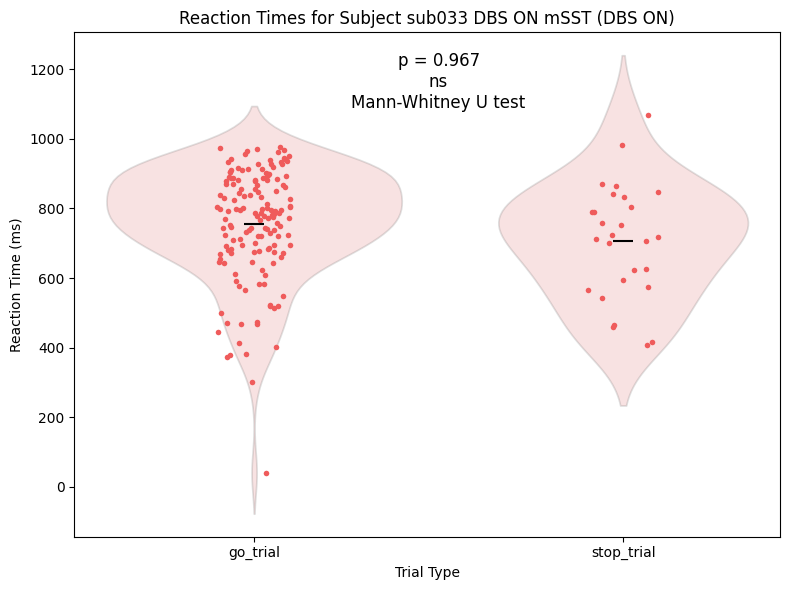

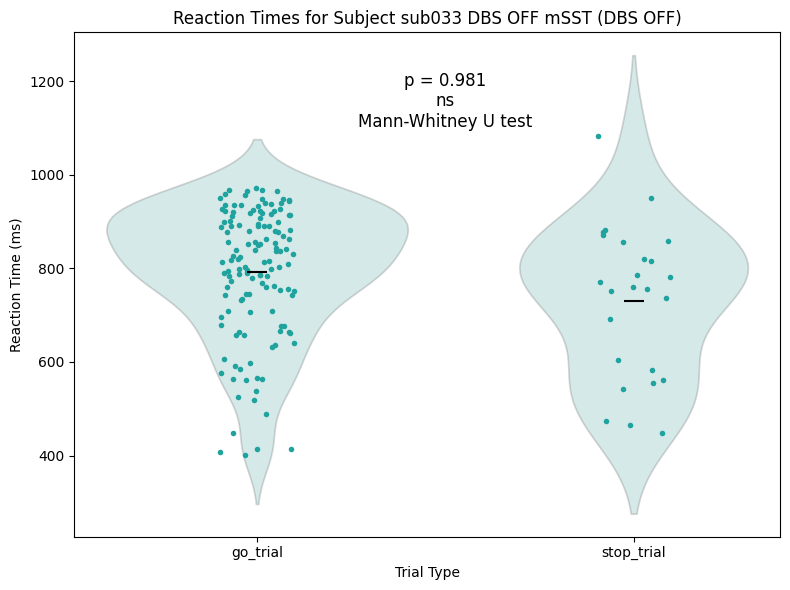

Excel file saved as 'p_values_independance_test.xlsx'.


In [30]:
print("Testing independence assumption at the single session level...")
temp_save = join(behav_results_saving_path, "independence single sub")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)
excluded_subjects = hrm.check_independence_assumption_single_sub(
    stats = stats,
    excluded_subjects = excluded_subjects,
    color_dict = color_dict,
    save_as = save_as,
    saving_path = temp_save,
    show_plot = True
)

In [31]:
excluded_subjects

[]

## 3.2. Group level (test replicated from Hervault et al., 2021) ##

"every single participant had a shorter mean RT in failed–STOP trials than in GO trials. This was the case in both the pressing (t(39) = 8.42, p < .001, d =1.35) and the swiping type (t(39) = 13.72, p < .001, d = 2.0)"
Statistical test used:
t(39) → A paired t-test with 40 participants (degrees of freedom = 39).

t-value:
Pressing: t = 8.42
Swiping: t = 13.72

p < .001 → Very strong evidence against the null hypothesis.

Cohen’s d (effect size):
Pressing: d = 1.35 (large effect)
Swiping: d = 2.0 (very large effect)

Testing independence assumption at the group level...
Paired t-test results: t-statistic(46) = -12.913346276300413, p-value = 3.3099942777454117e-17
Negative differences found at indices: [12 18], corresponding subjects: ['C016 mSST', 'sub009 DBS OFF mSST']
Excluded subjects: ['C016 mSST', 'sub009 DBS OFF mSST', 'sub009 DBS ON mSST']
Cohen's d = 1.88


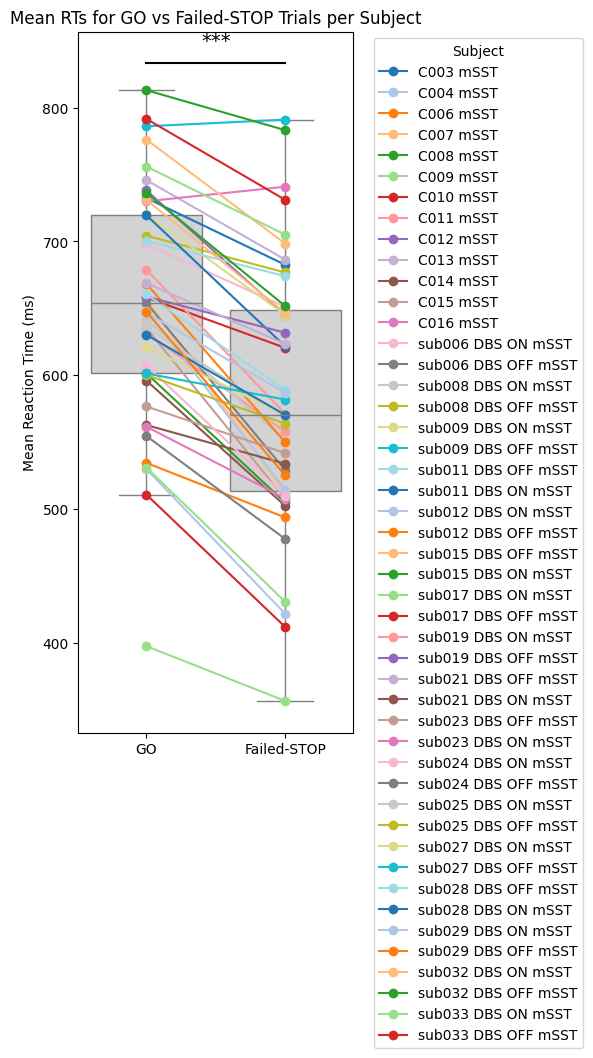

Overall, participants had a shorter mean RT in unsuccessful STOP trials than in GO trials (t(46) = -12.913346276300413, p-value = 3.3099942777454117e-17, d = 1.88). At the individual level, this didn't hold true for the following subject(s): (['sub009 DBS OFF mSST', 'sub009 DBS ON mSST', 'C016 mSST']), who was/were therefore removed from subsequent analysis.


In [32]:
print("Testing independence assumption at the group level...")
temp_save = join(behav_results_saving_path, "independence group level")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)
excluded_subjects = hrm.check_independence_assumption_group_level(
    stats = stats,    
    excluded_subjects = excluded_subjects,
    save_as = save_as,
    saving_path = temp_save,
    show_plot = True
)


In [33]:
excluded_subjects

['sub009 DBS OFF mSST', 'sub009 DBS ON mSST', 'C016 mSST']

## 3.3. OPTIONAL: If (u)GS RT with small SSD > (u)GS RT with long SSD, the independence assumption is violated ##

Testing RT-SSD relation at the single subject level...


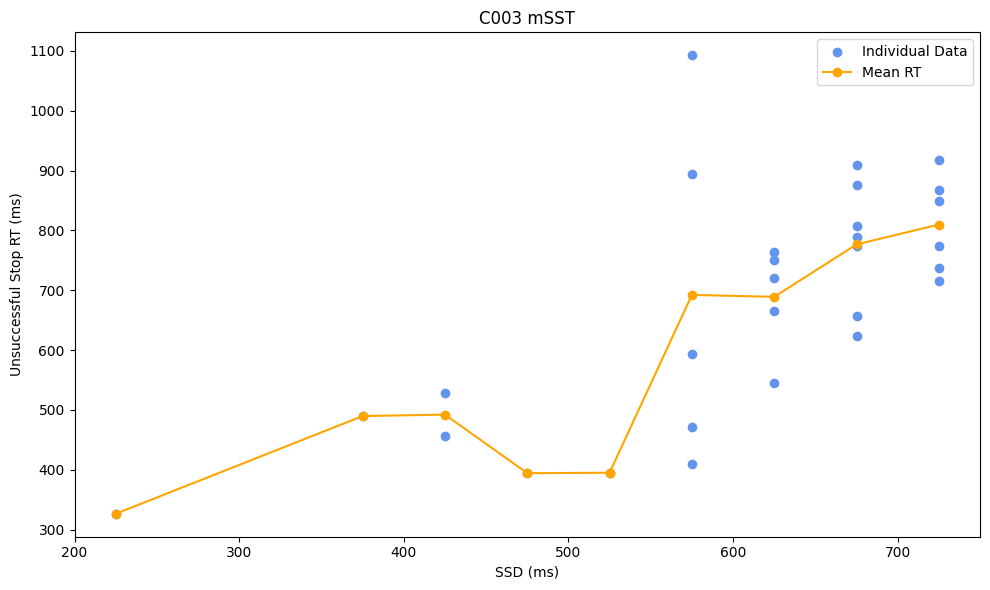

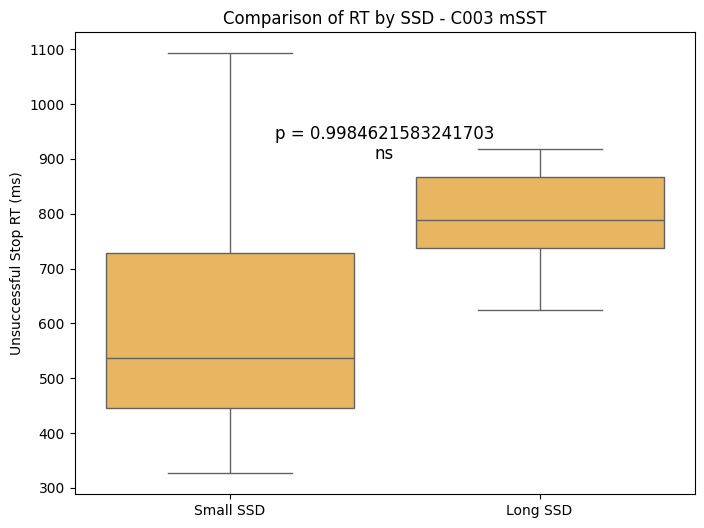

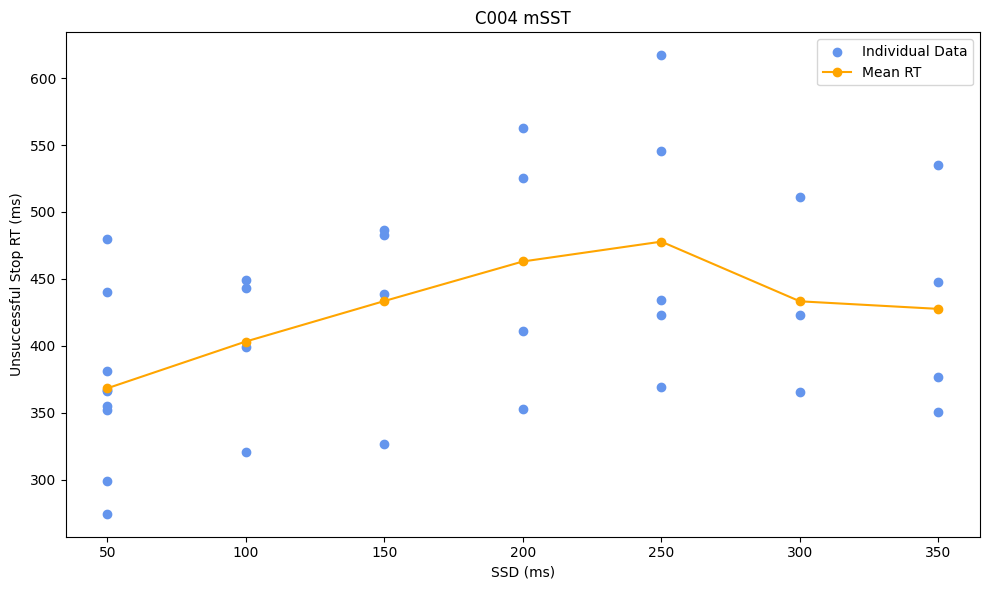

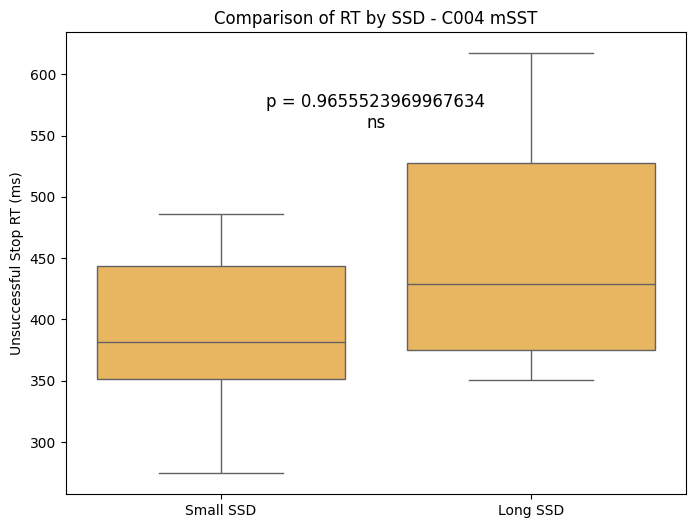

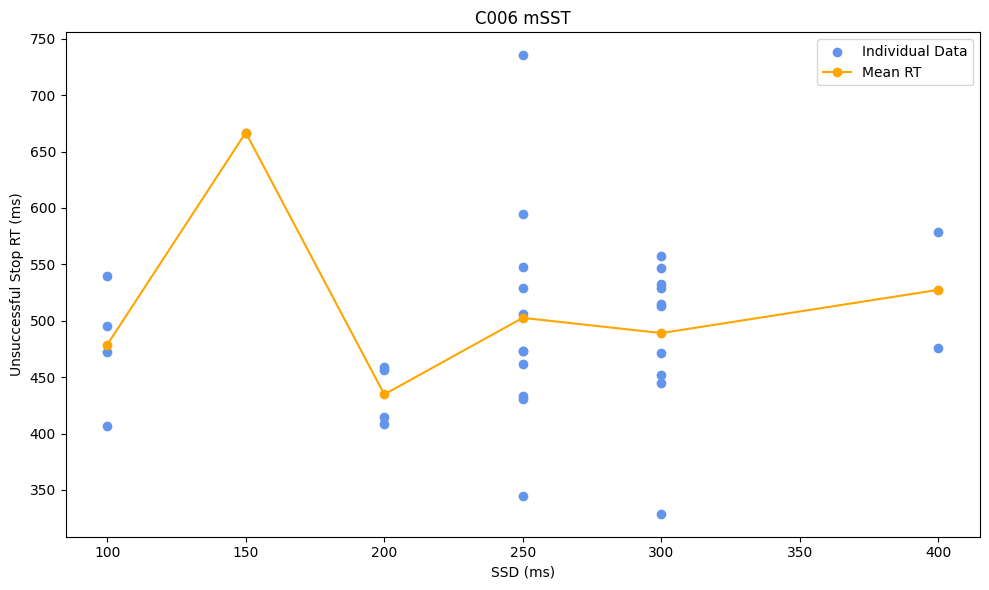

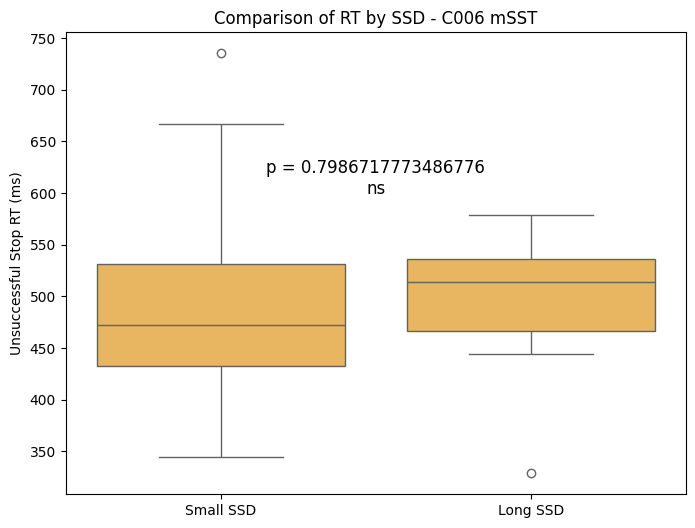

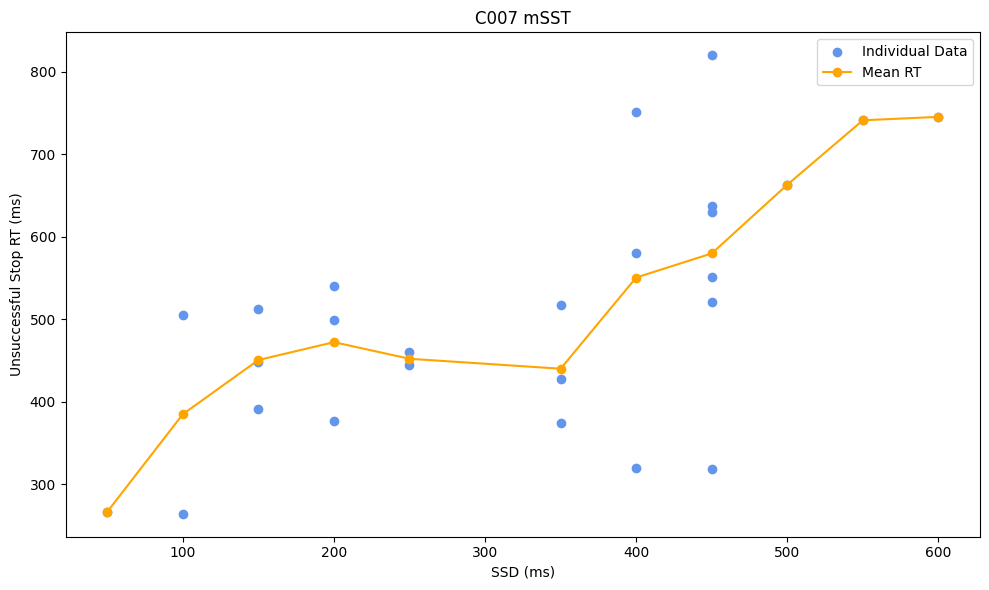

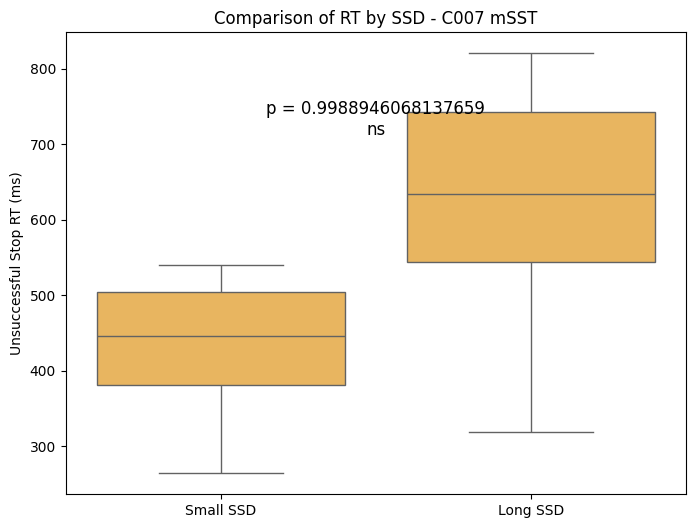

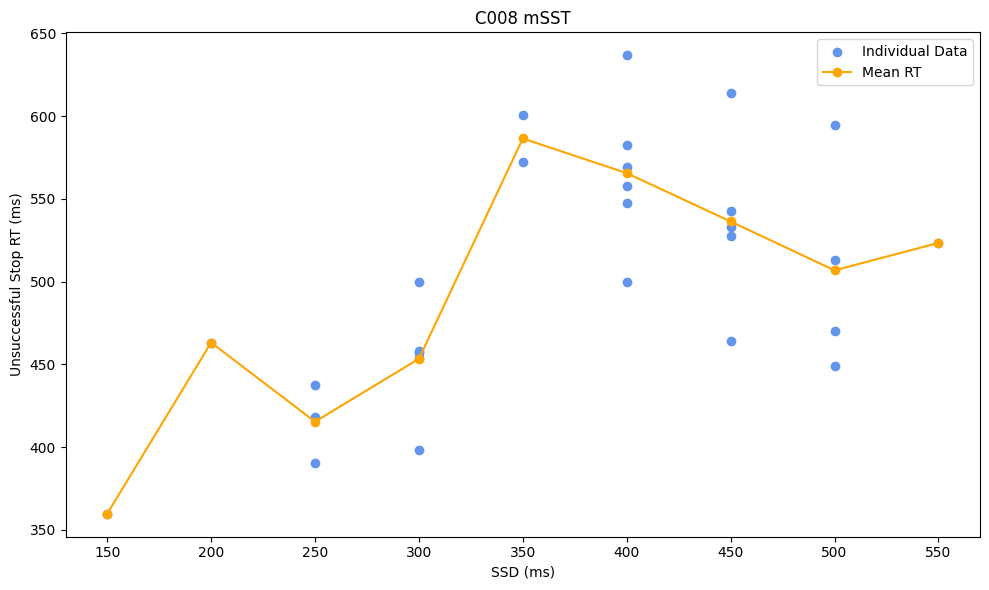

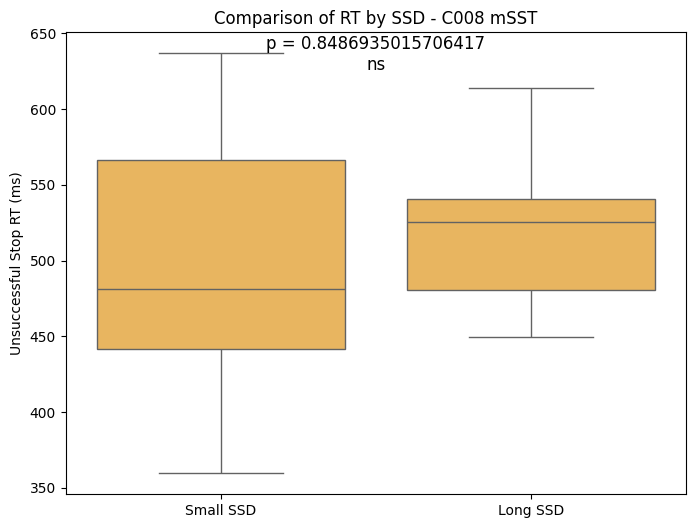

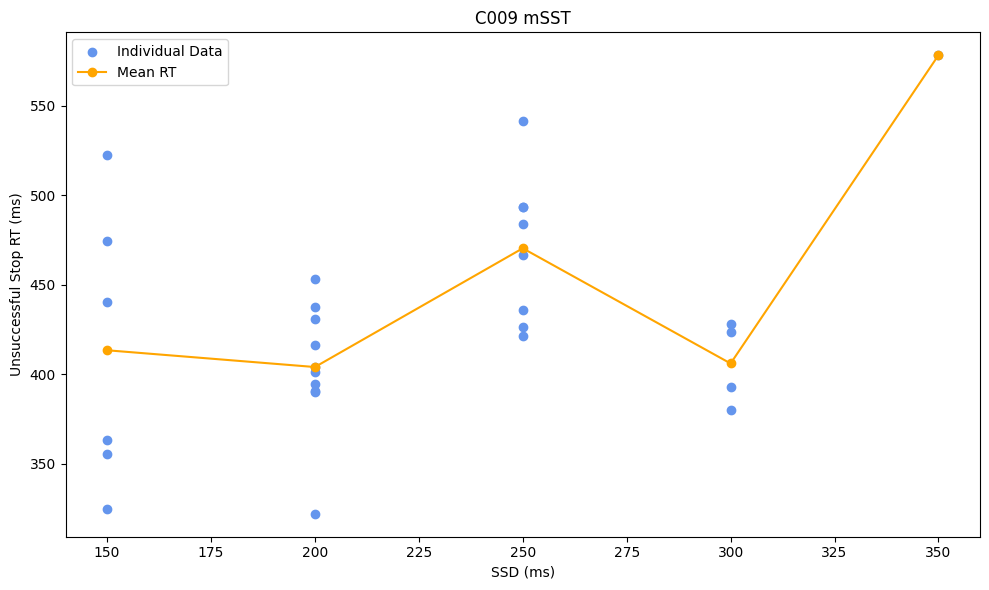

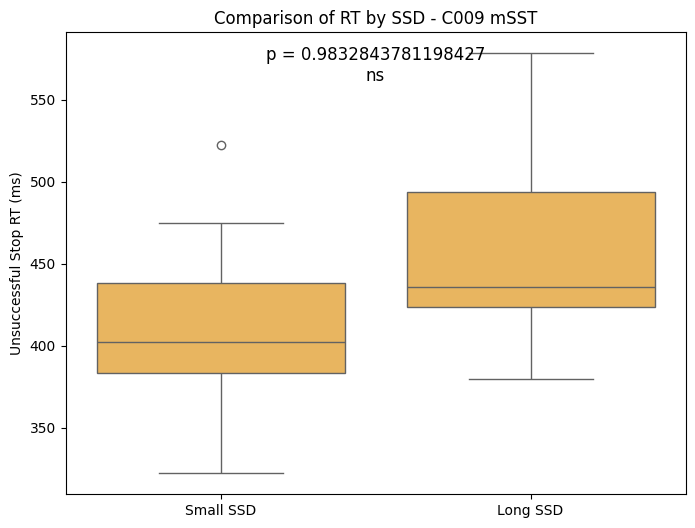

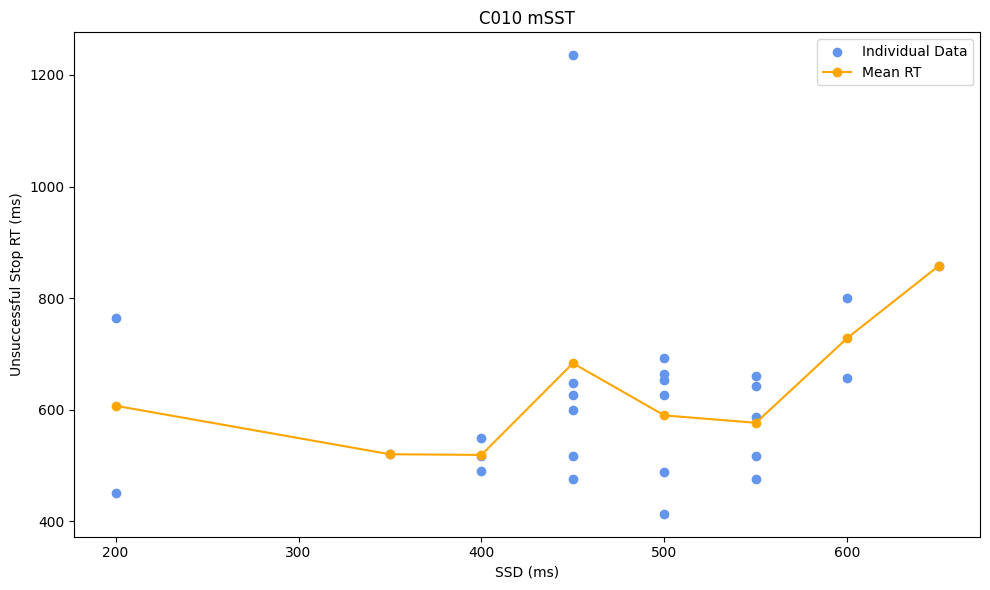

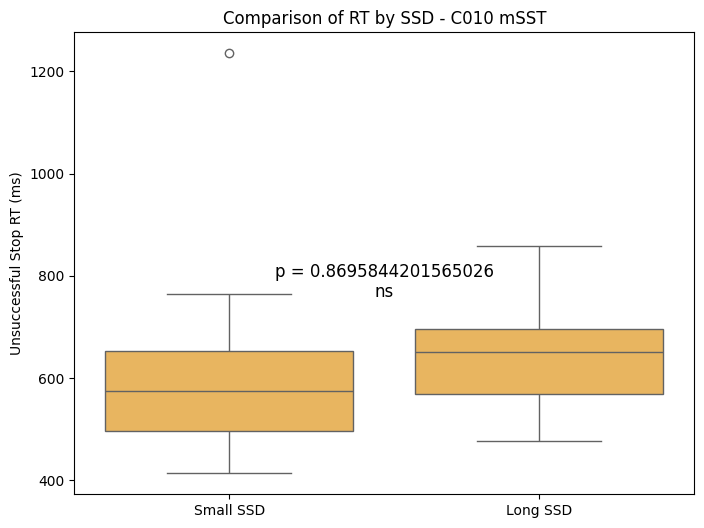

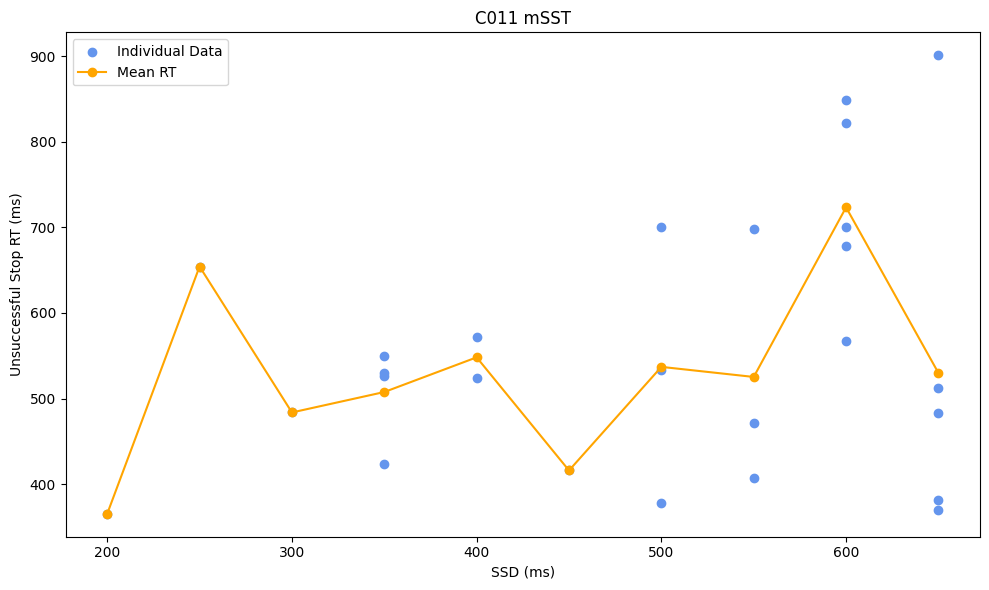

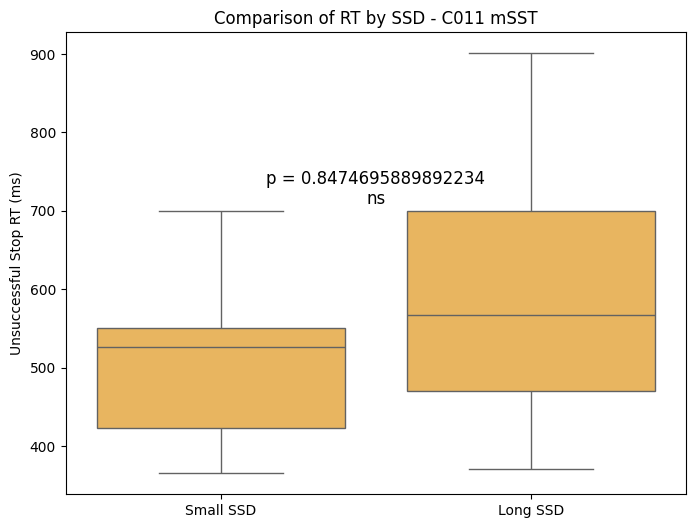

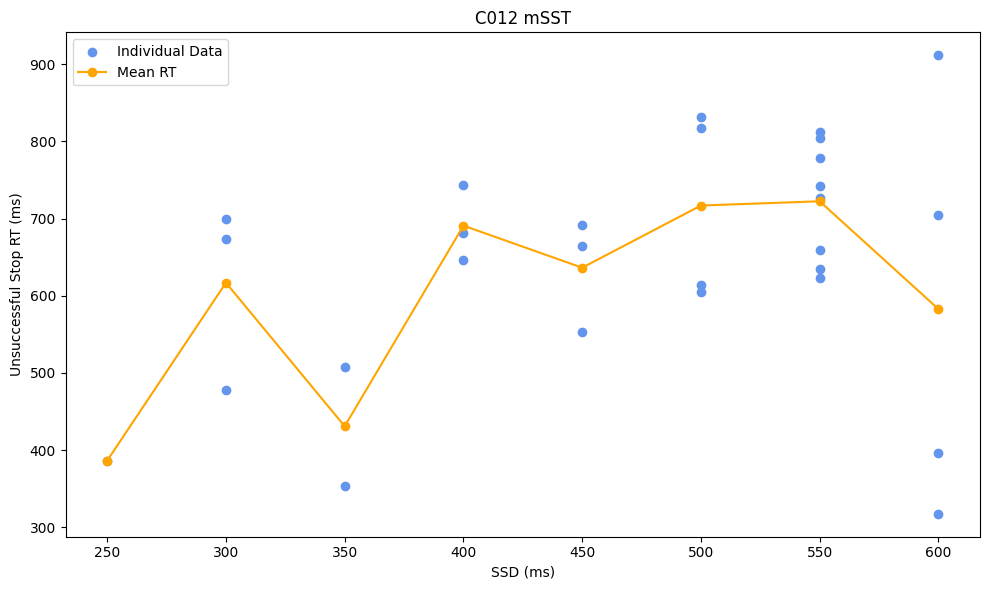

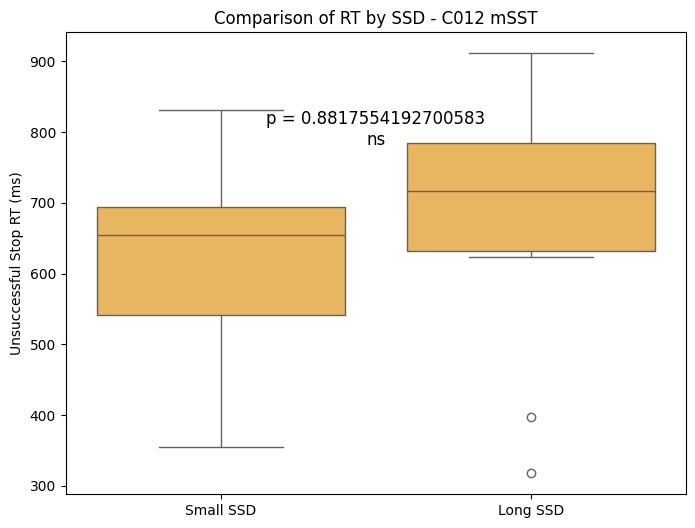

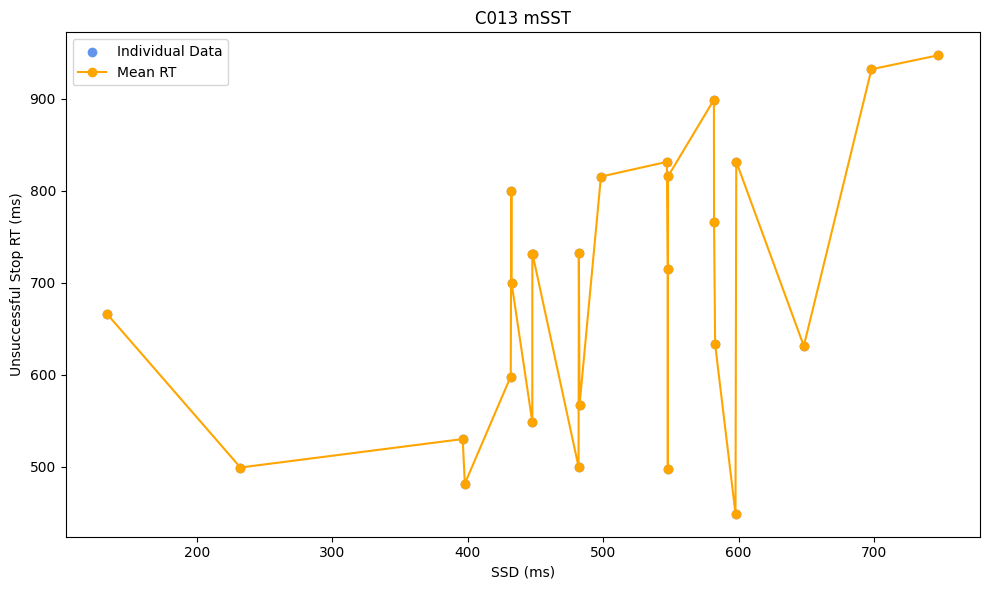

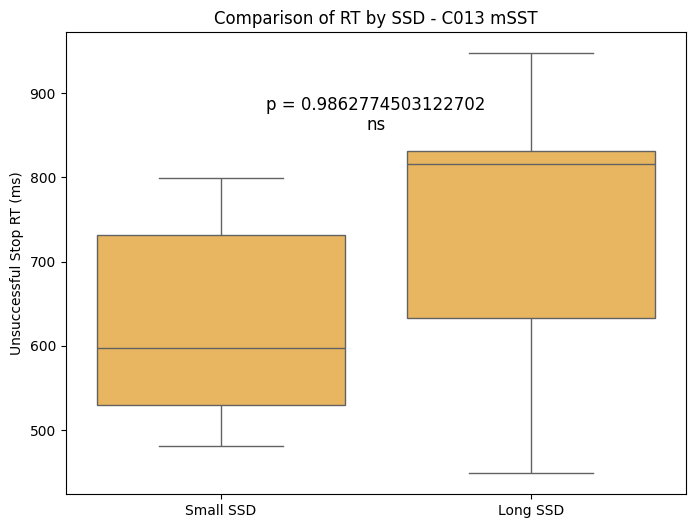

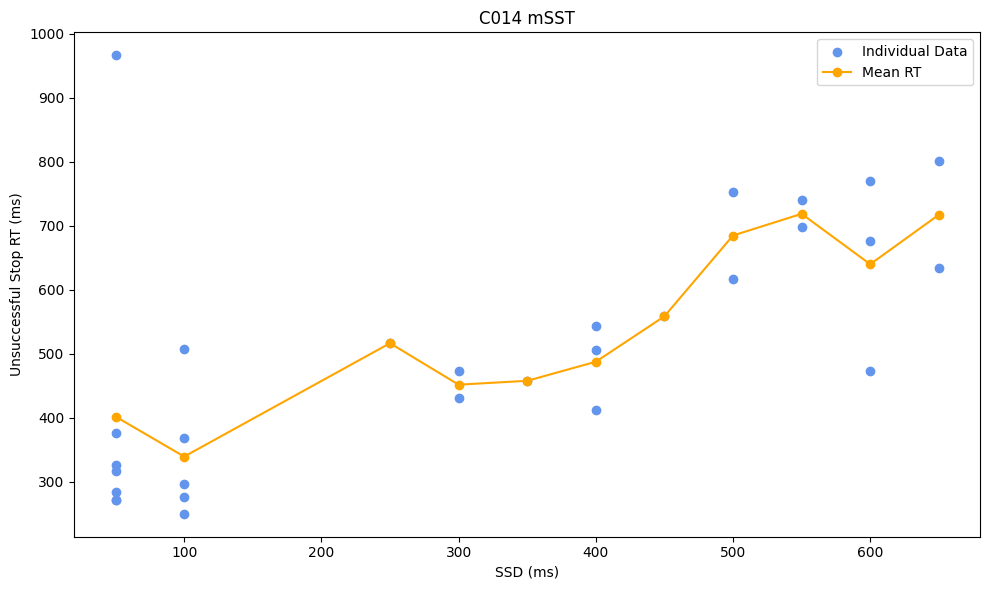

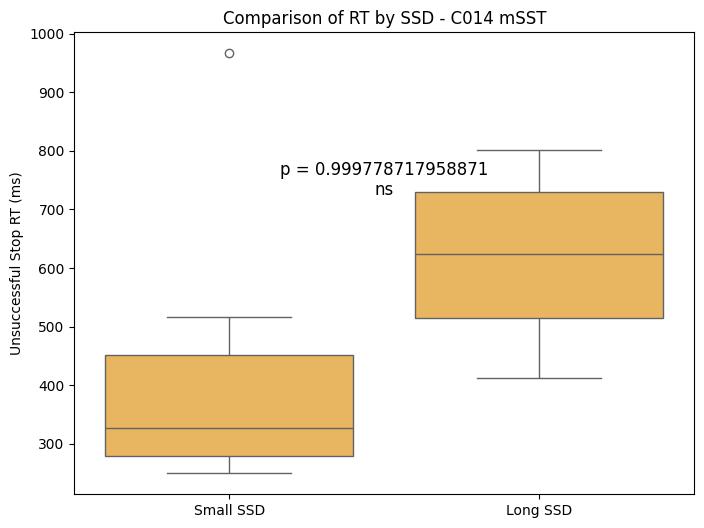

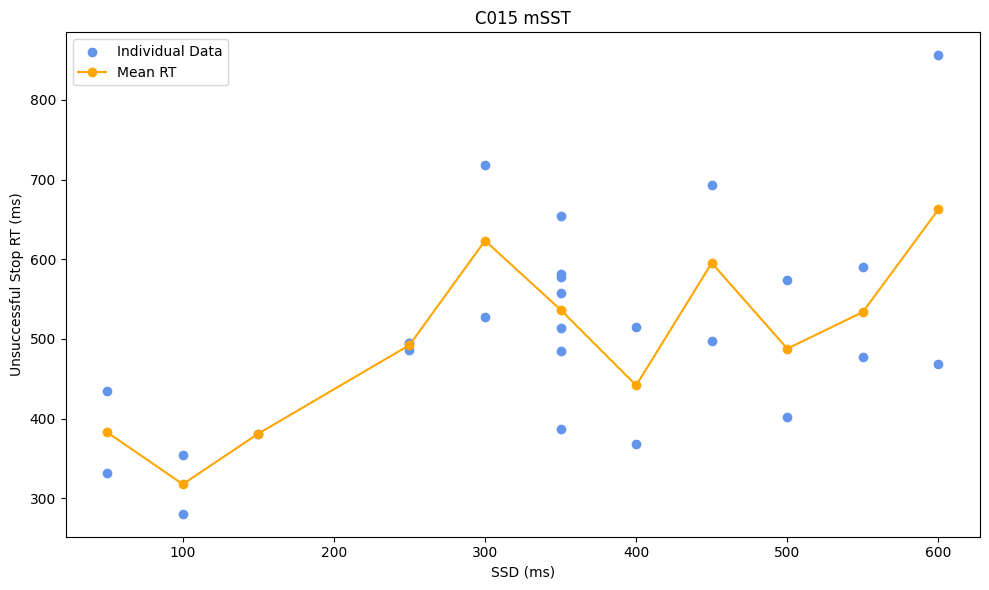

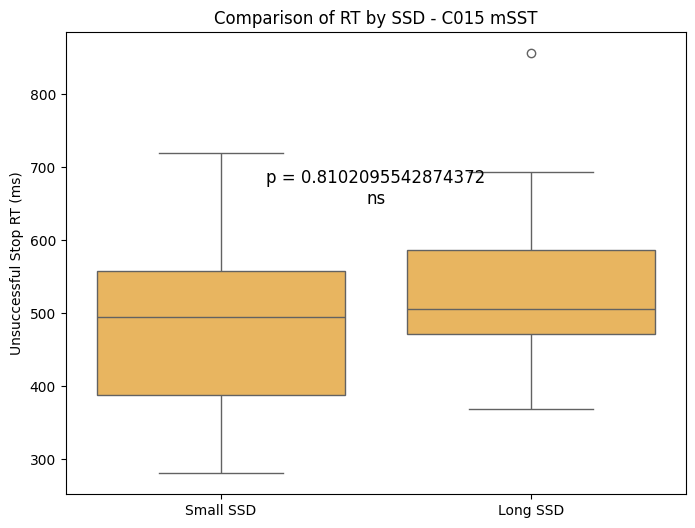

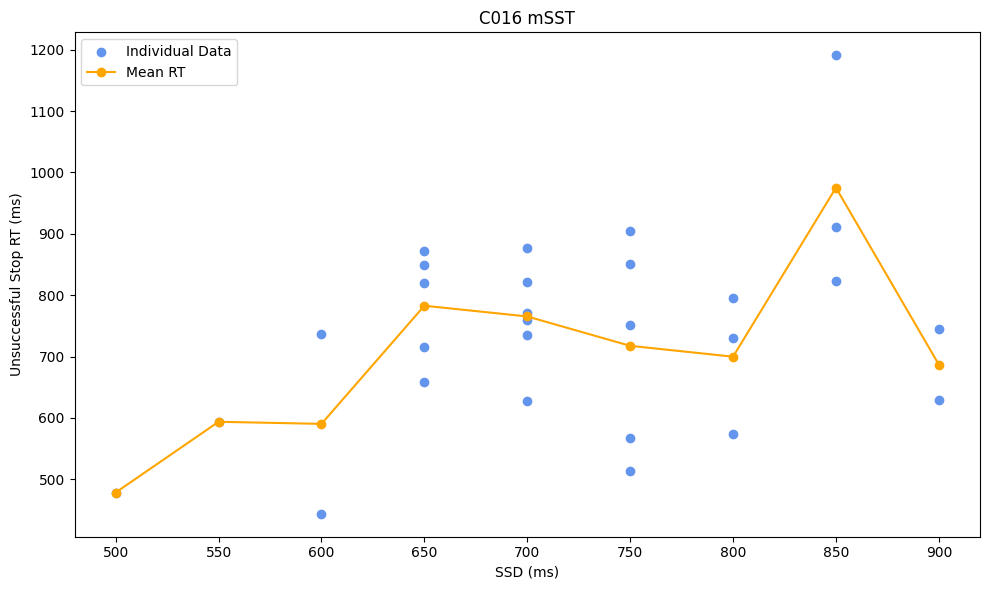

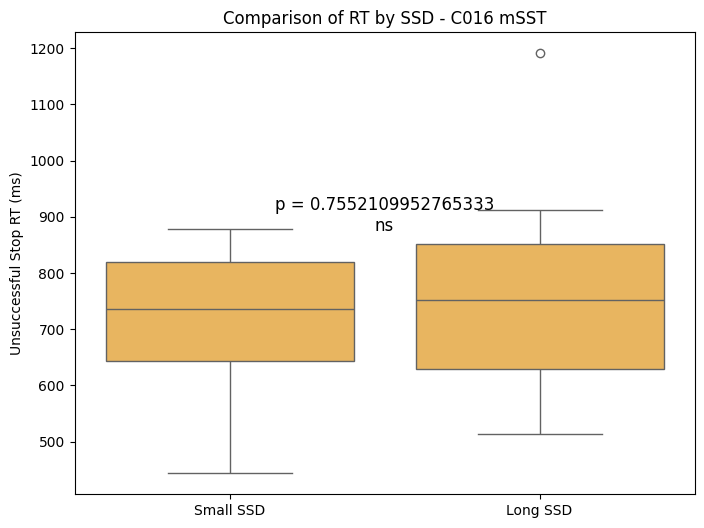

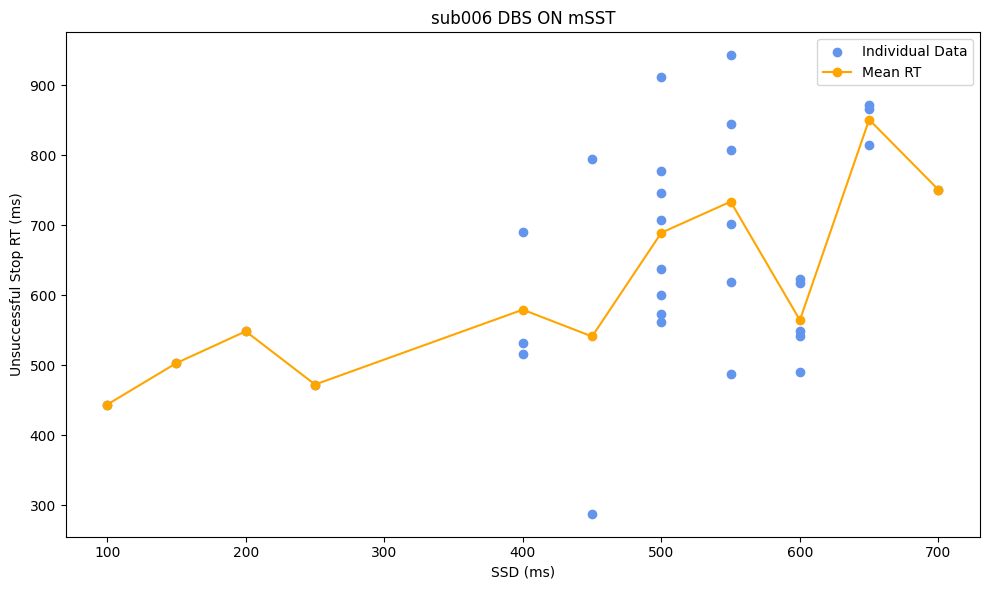

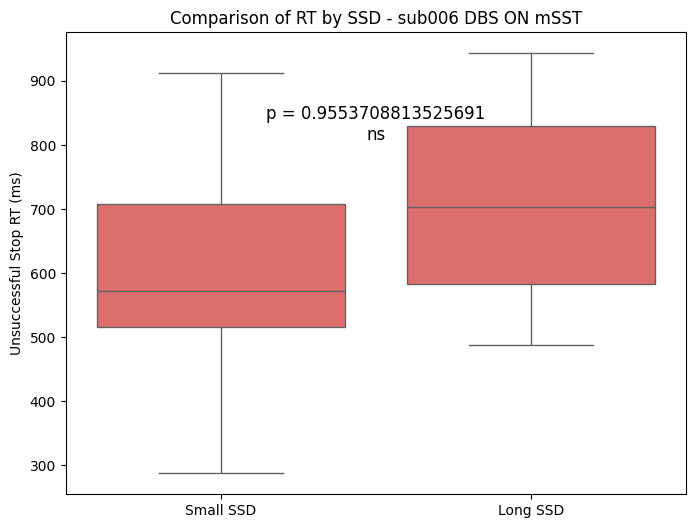

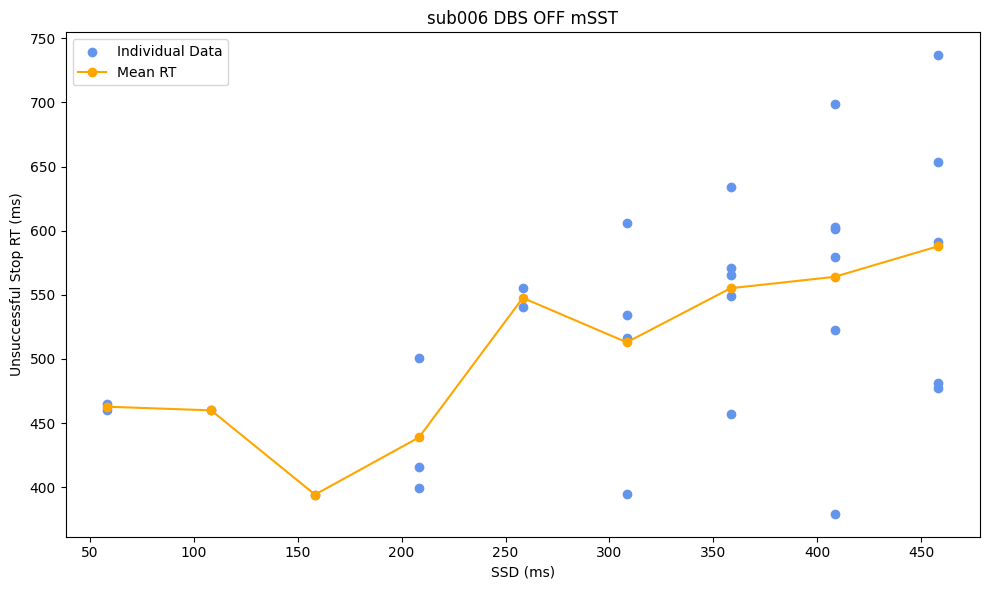

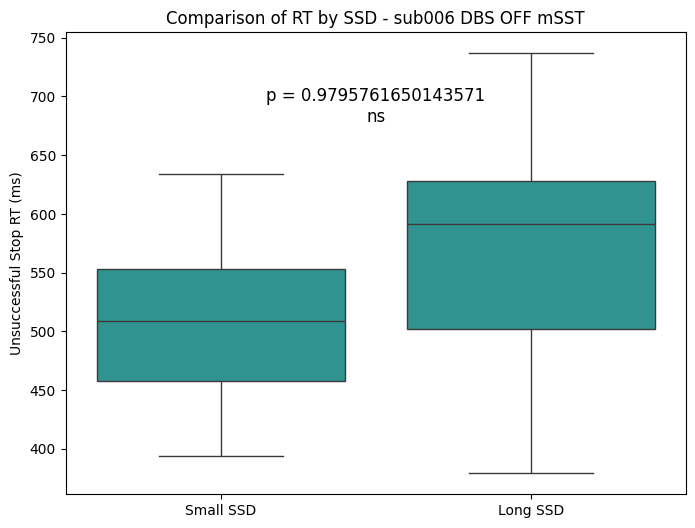

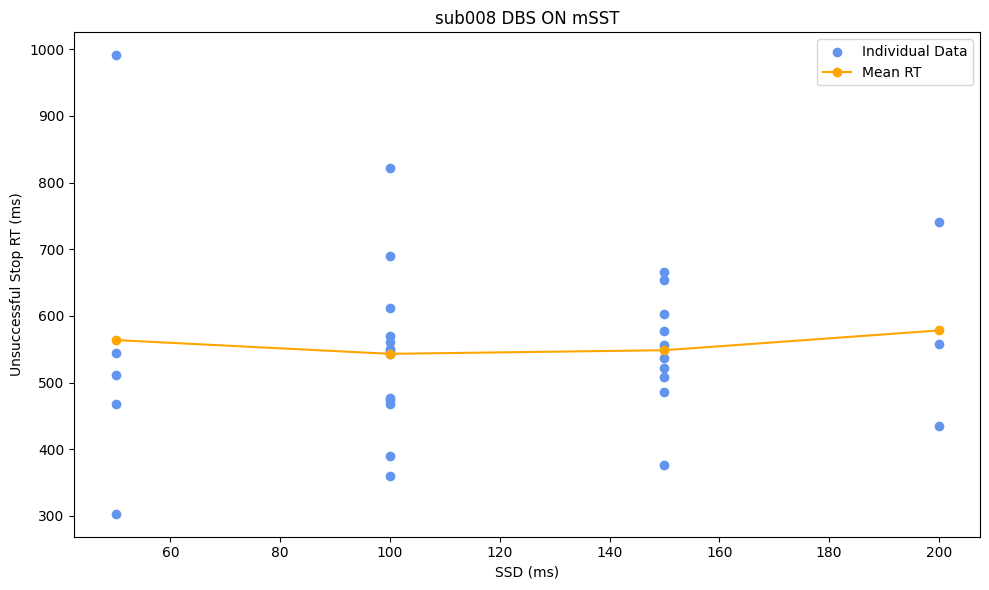

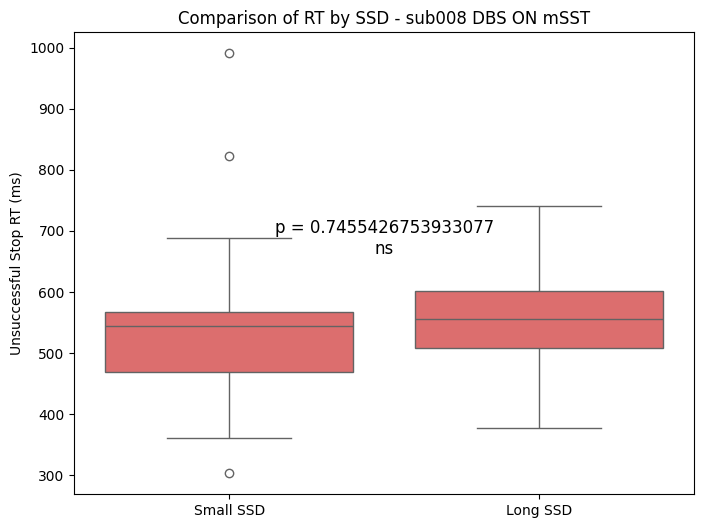

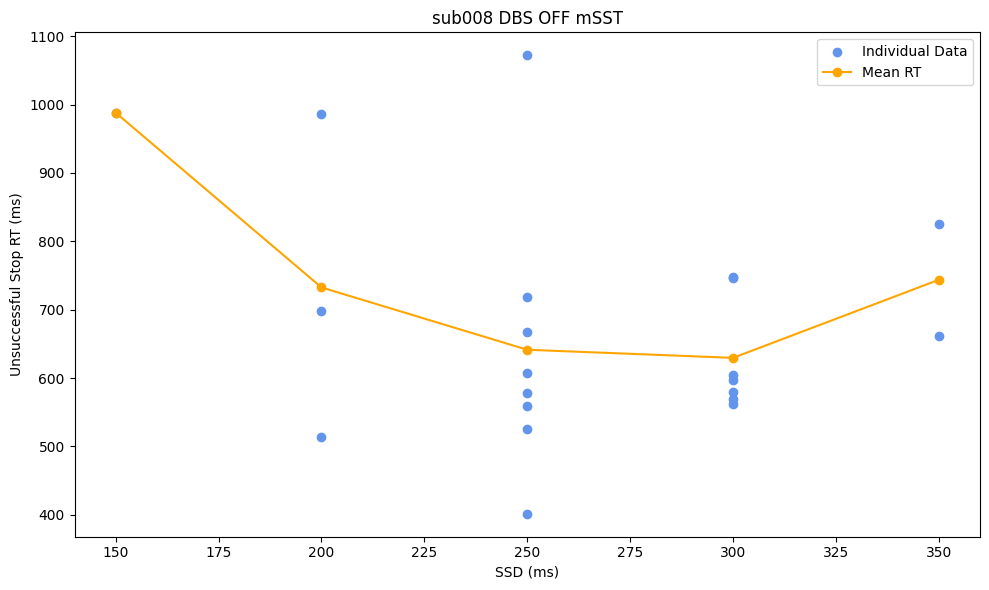

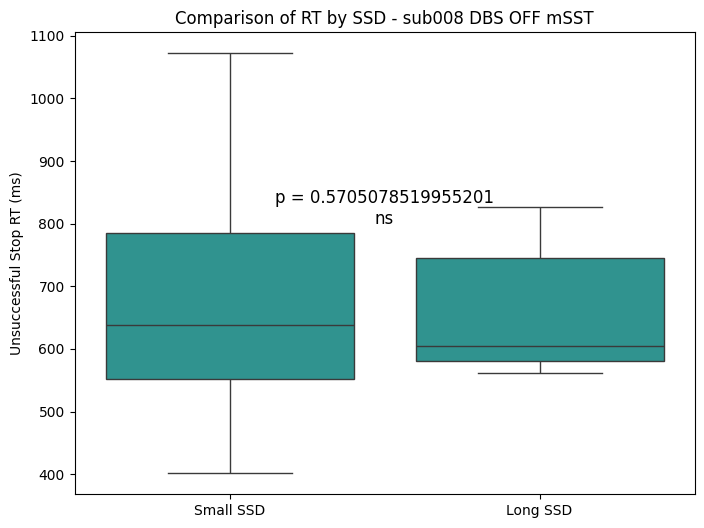

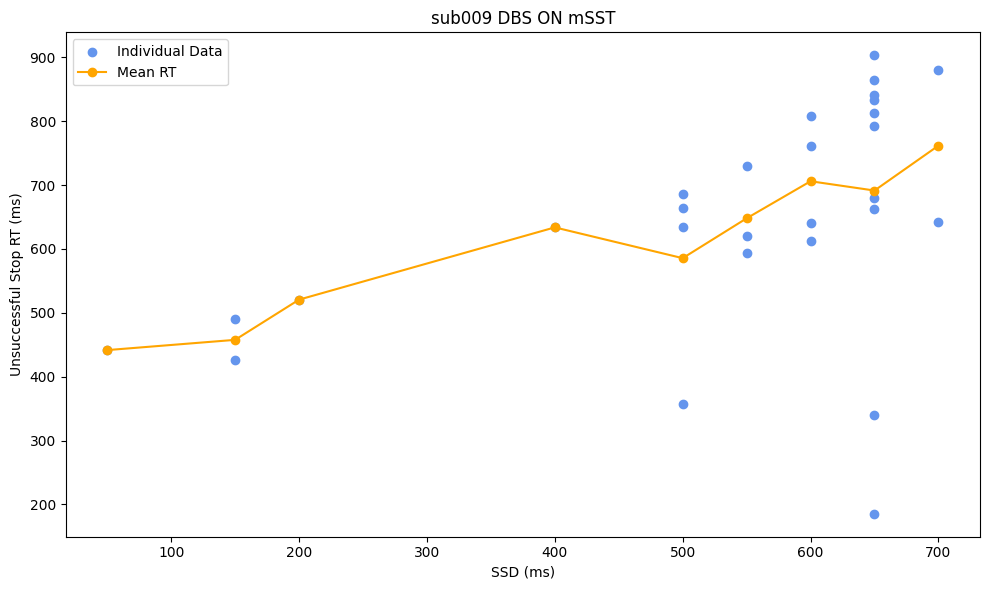

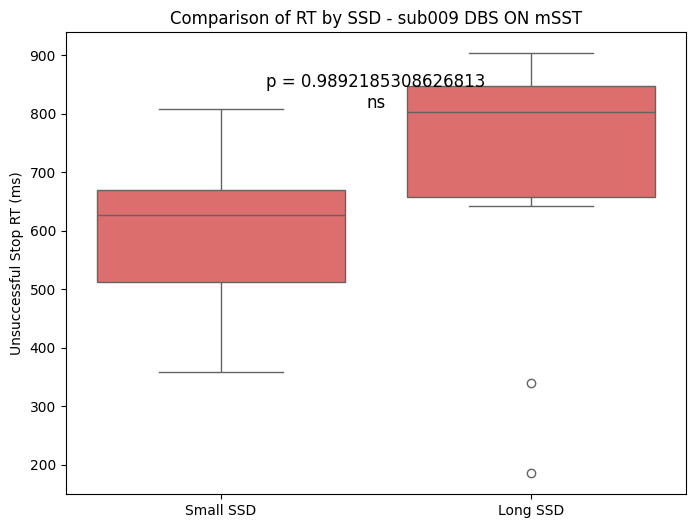

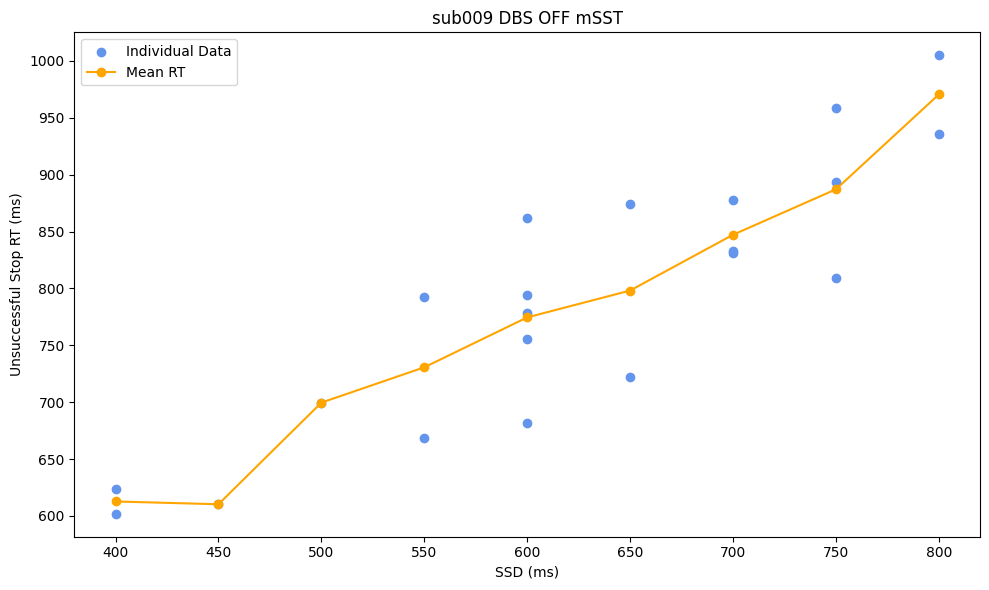

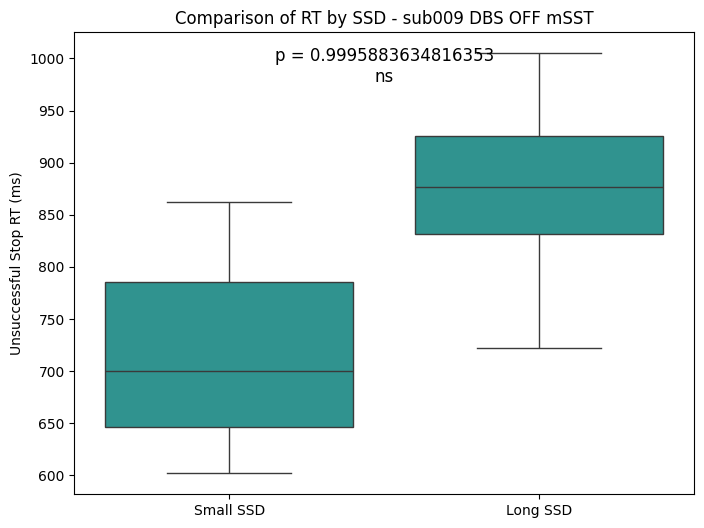

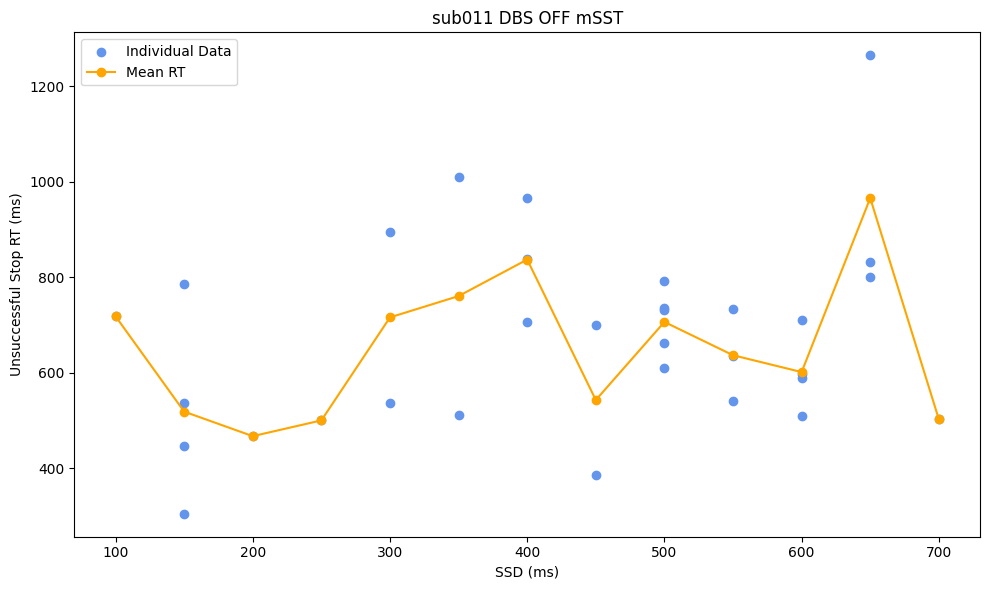

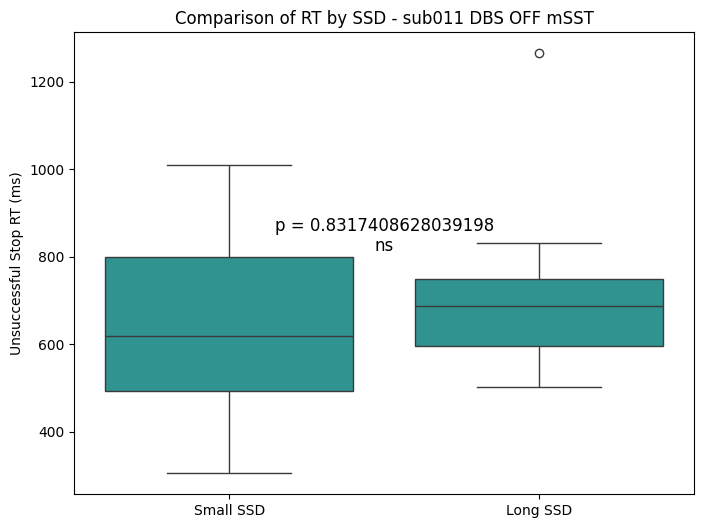

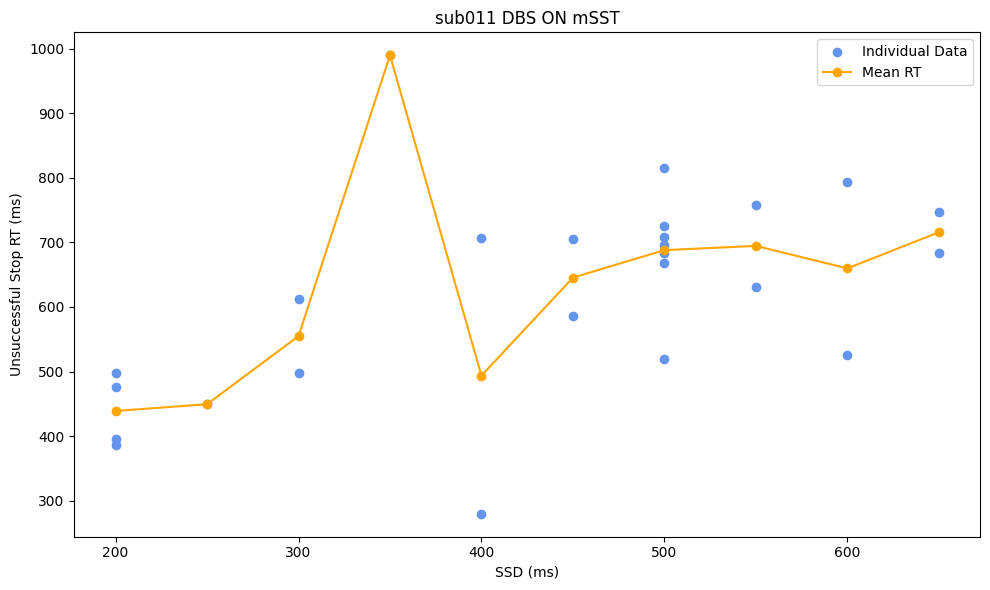

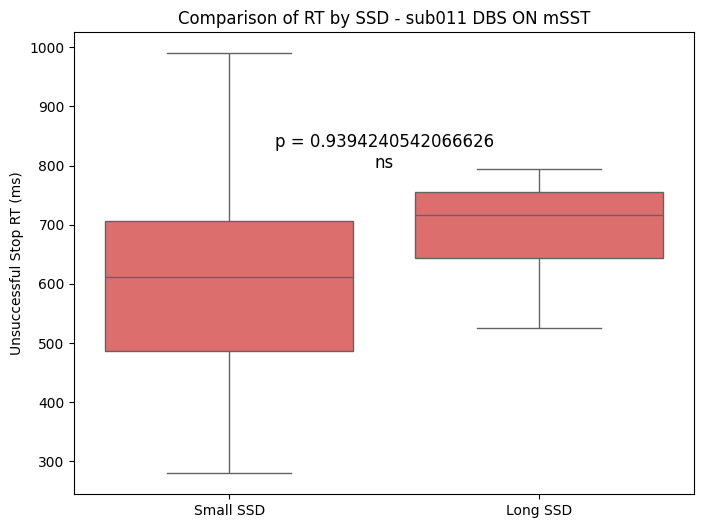

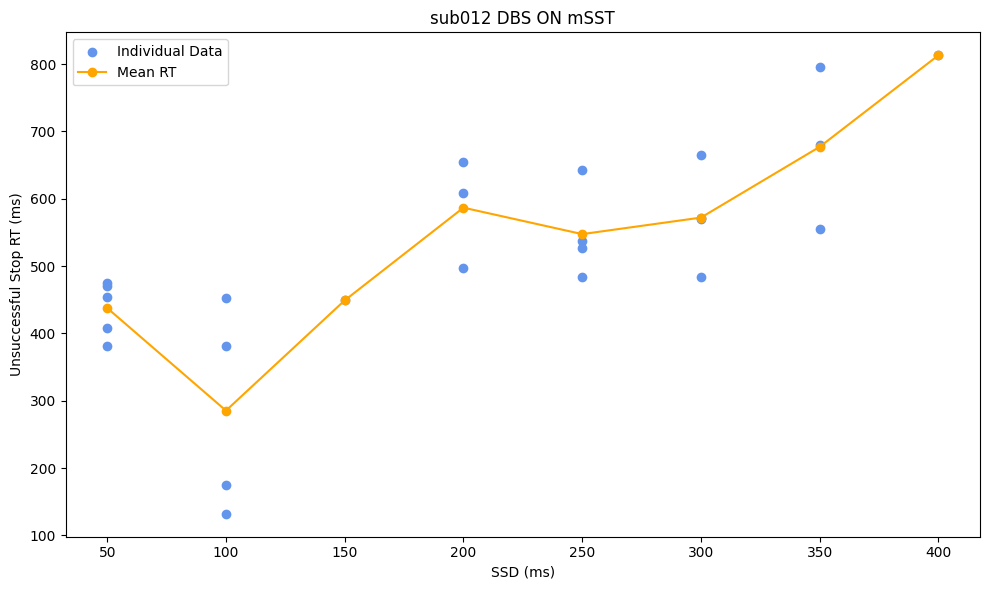

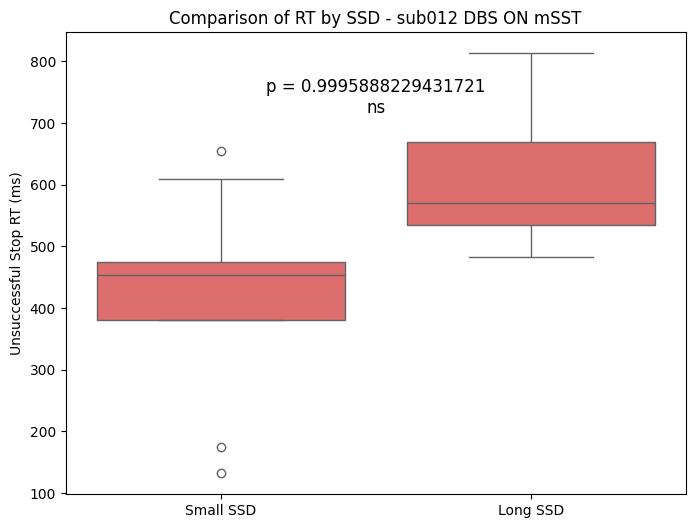

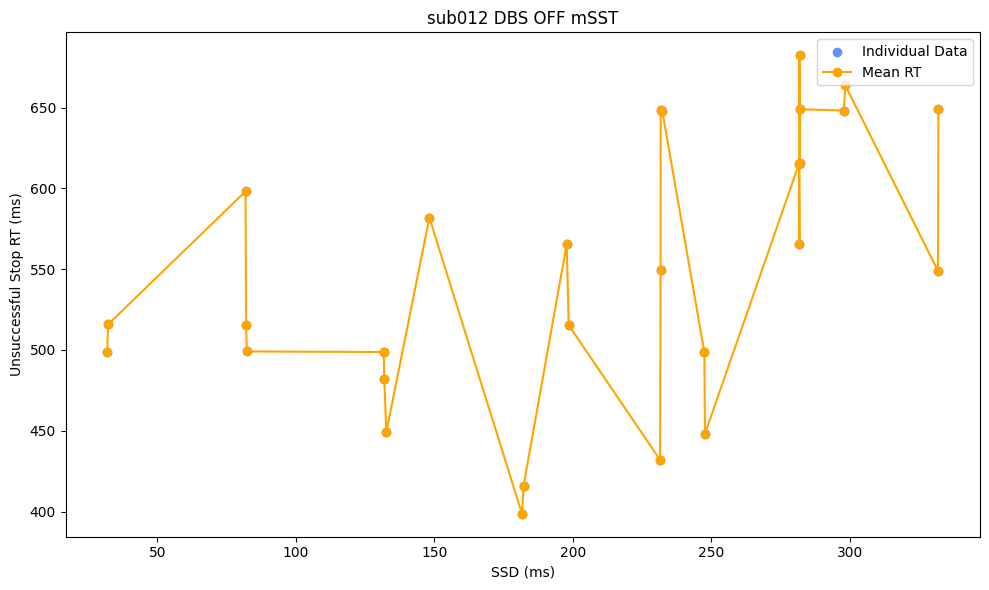

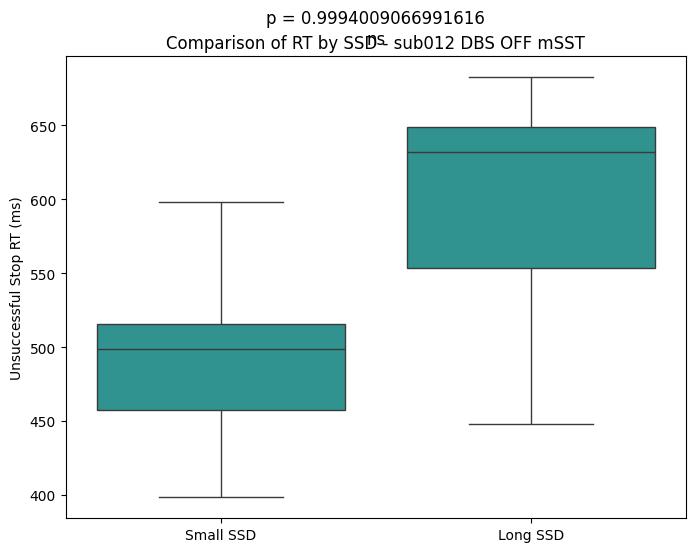

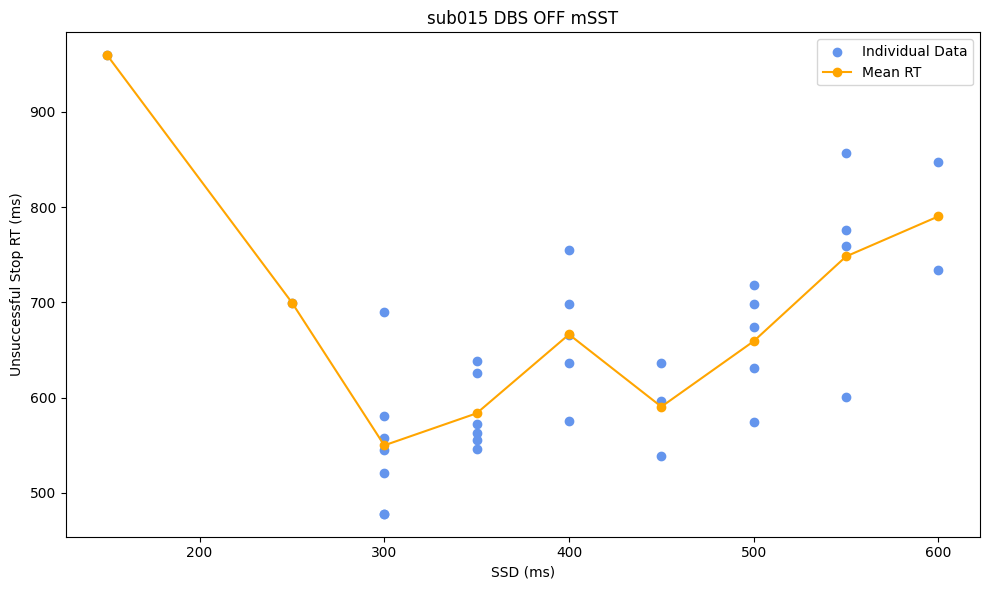

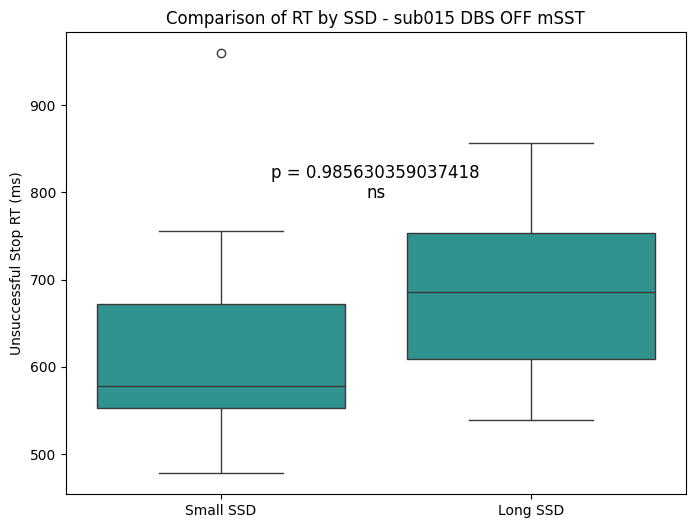

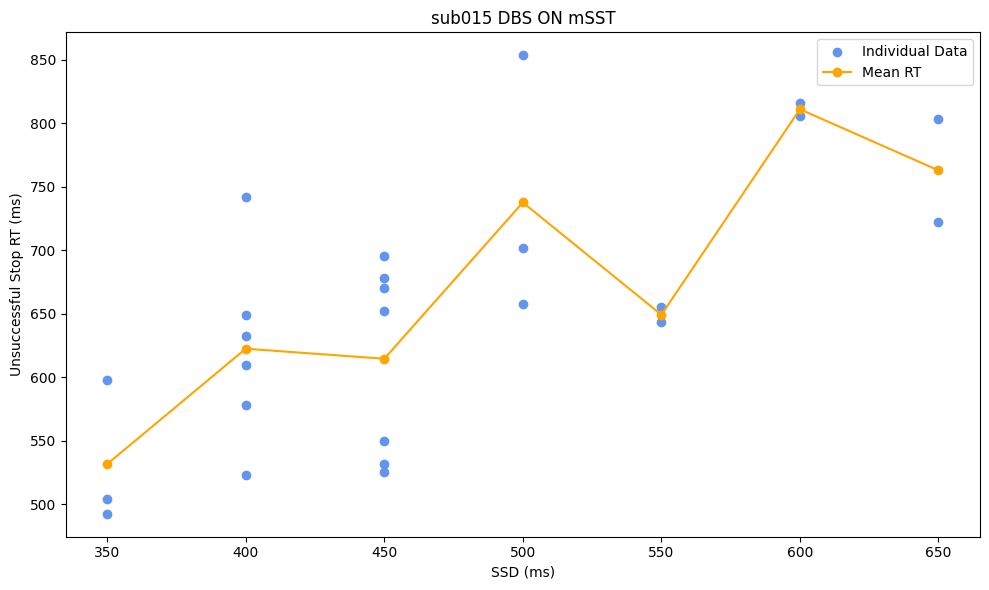

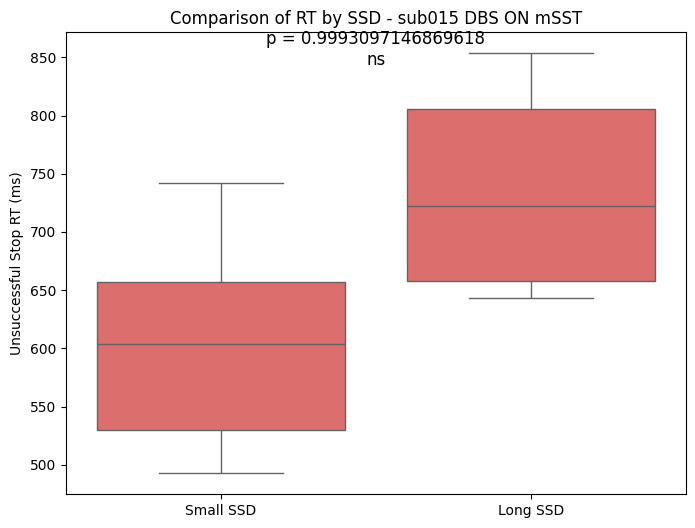

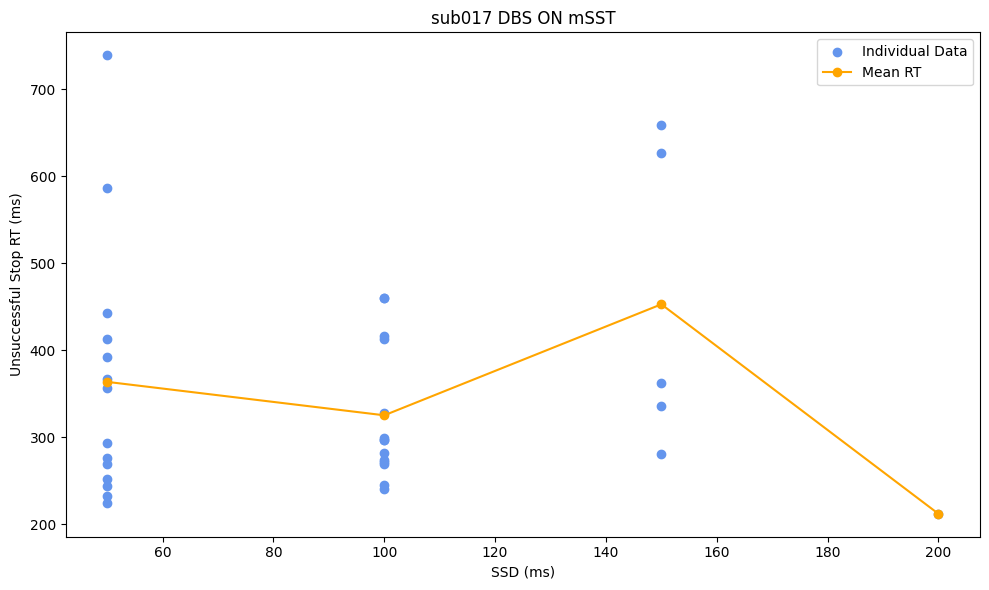

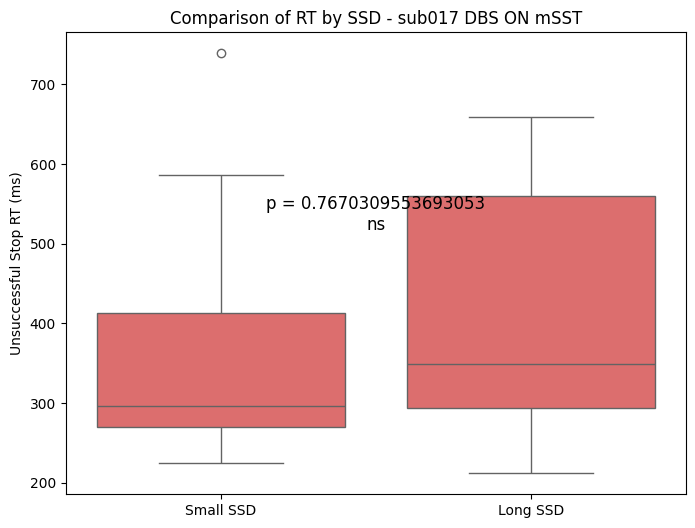

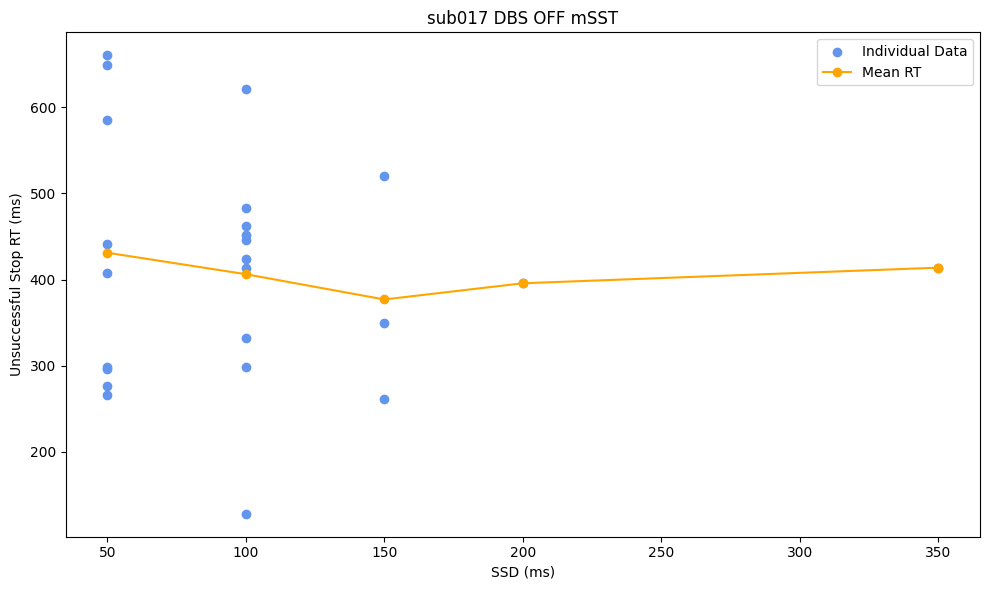

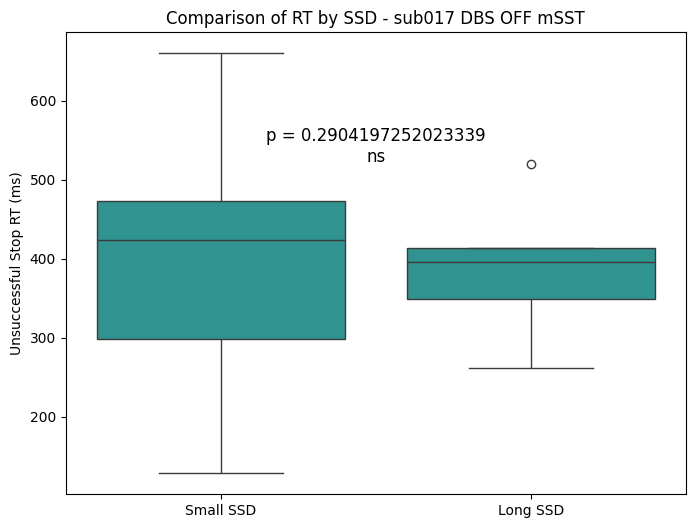

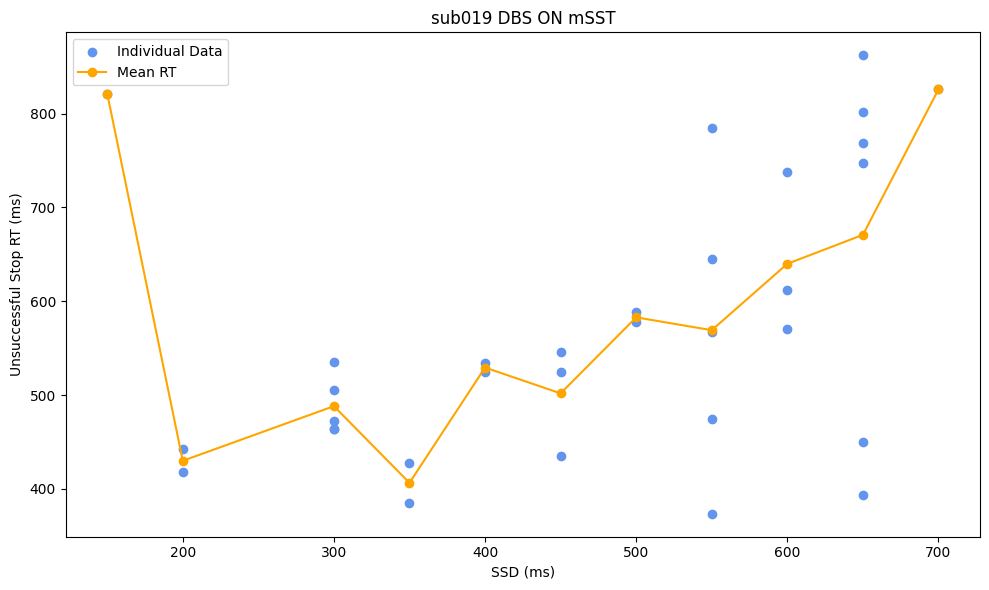

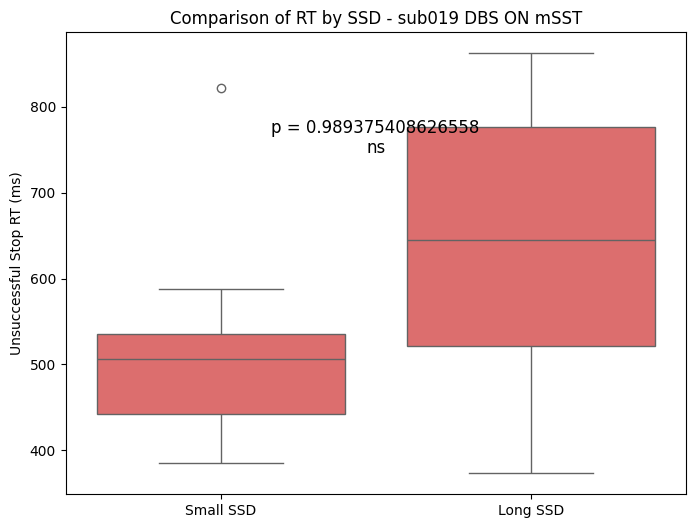

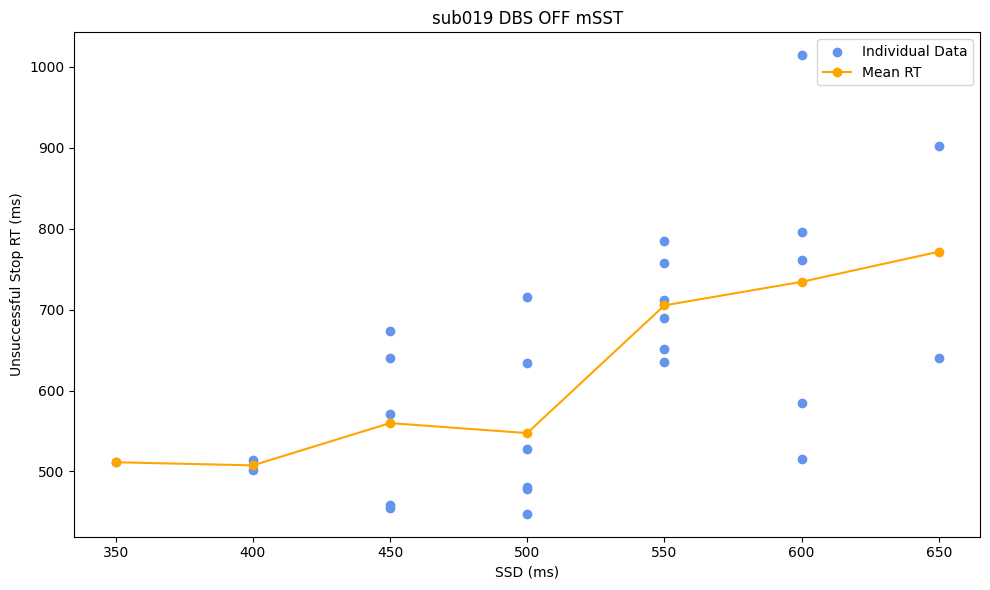

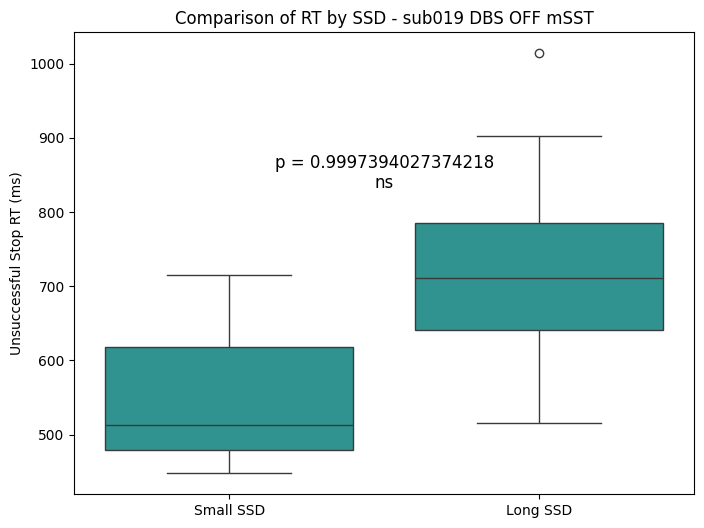

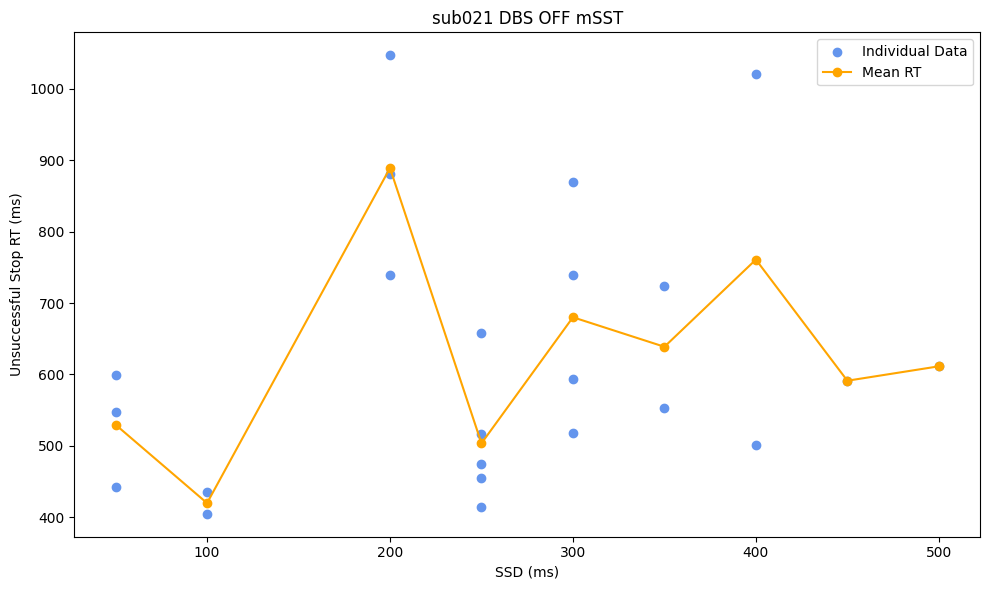

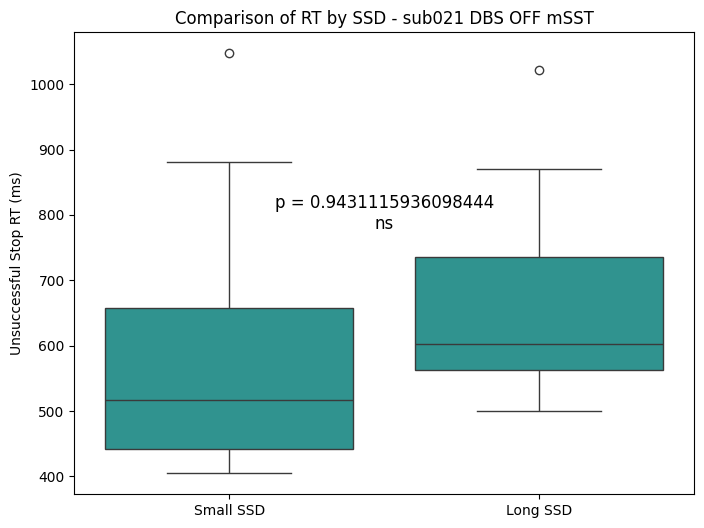

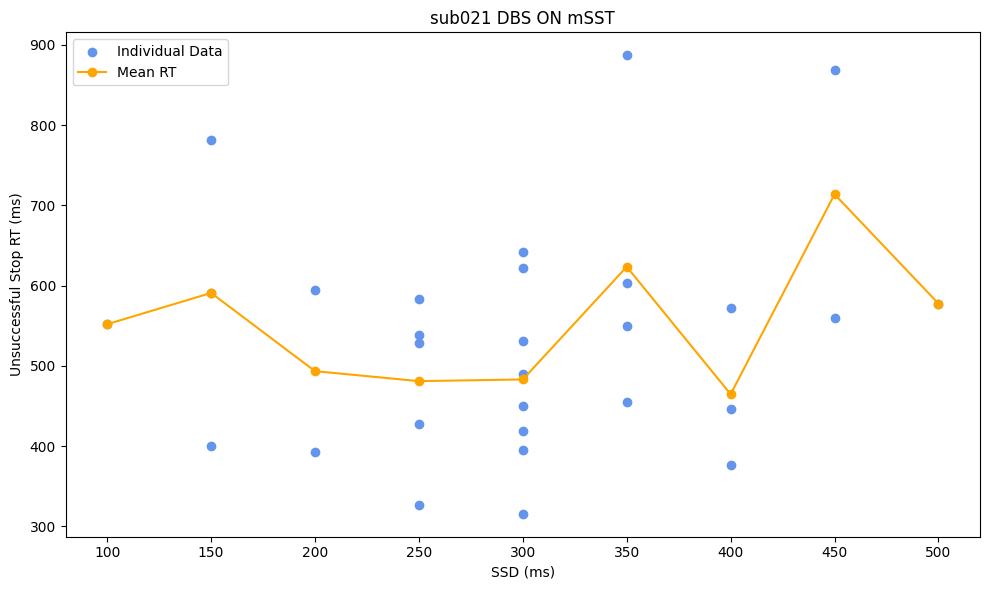

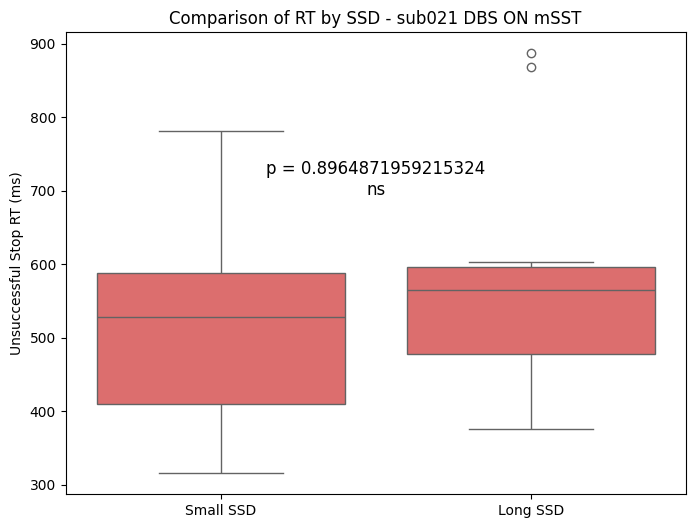

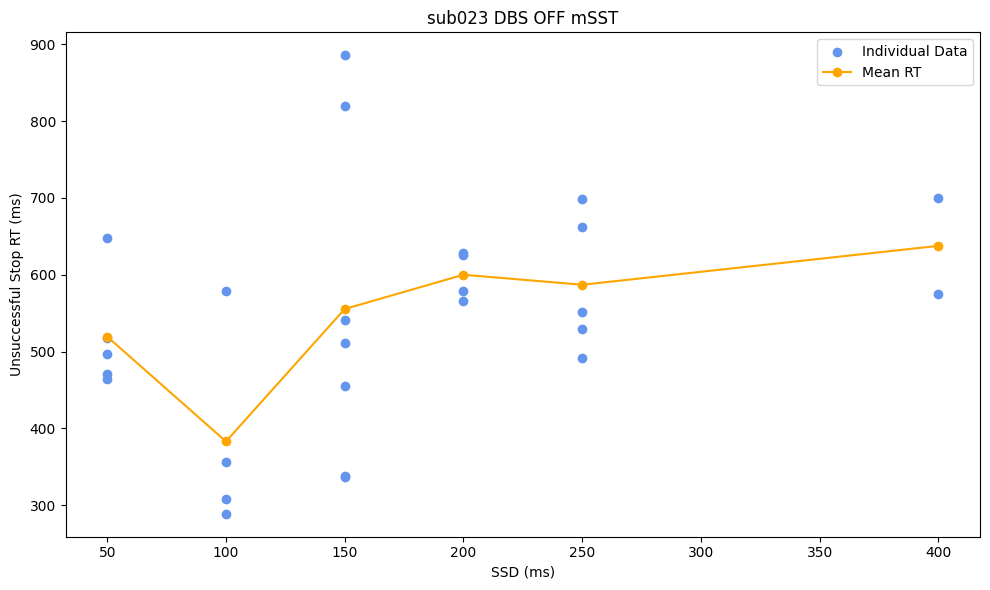

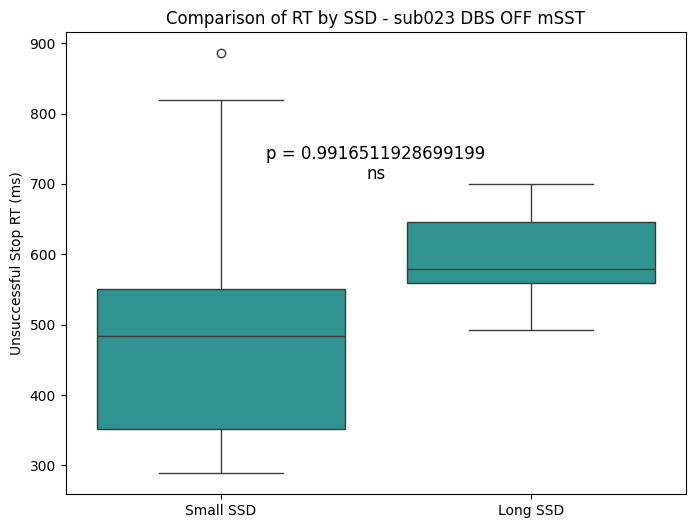

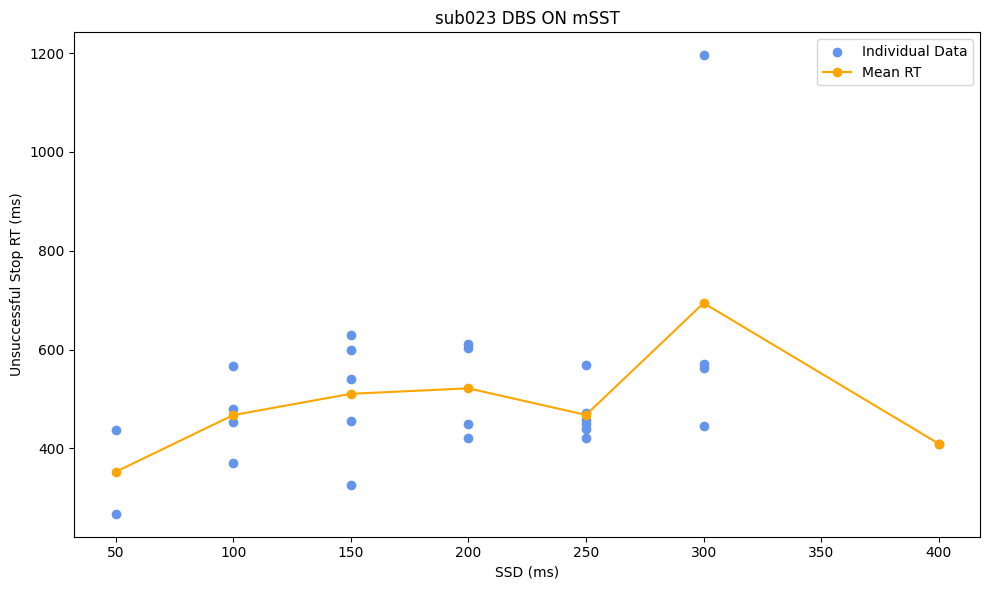

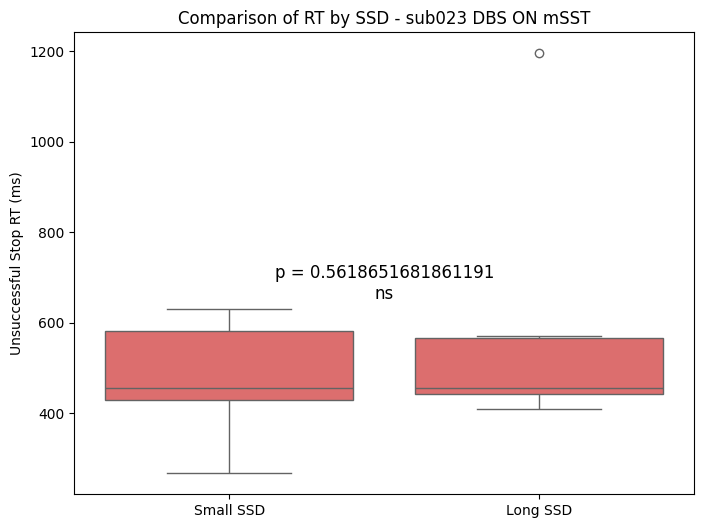

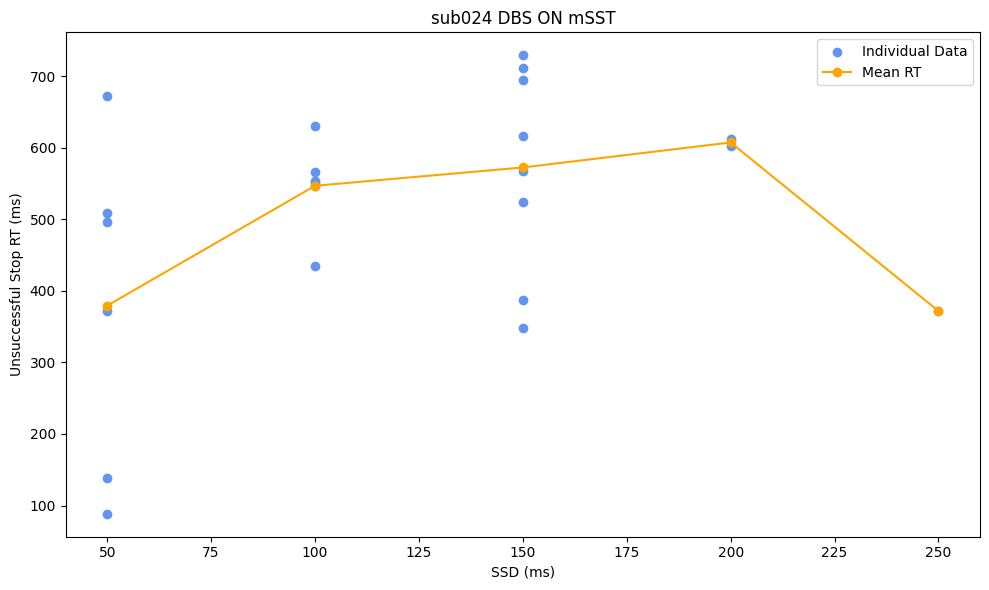

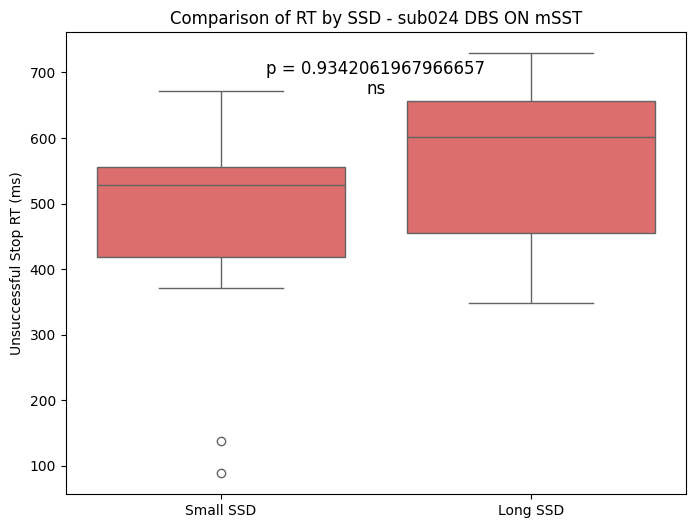

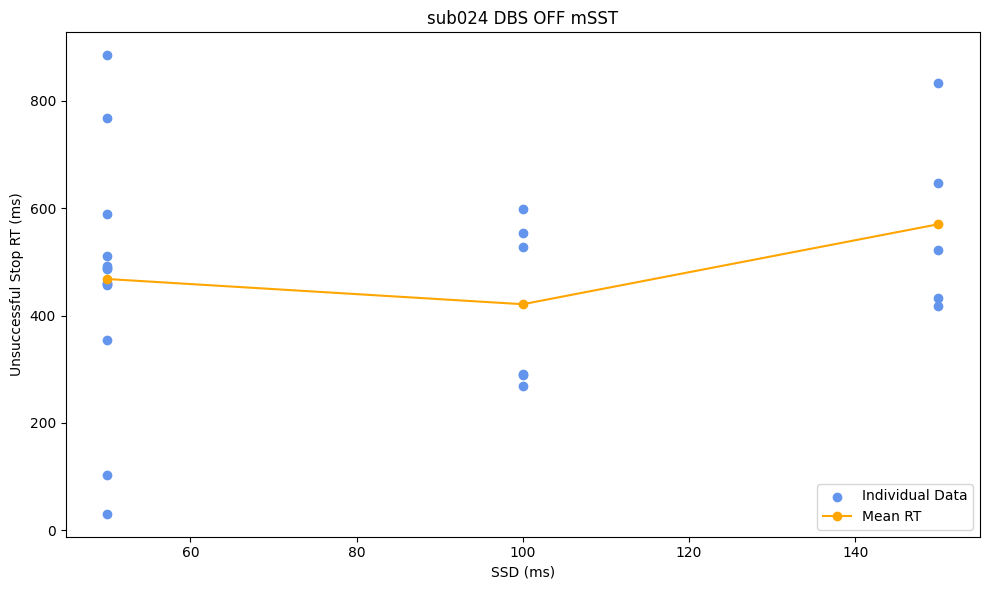

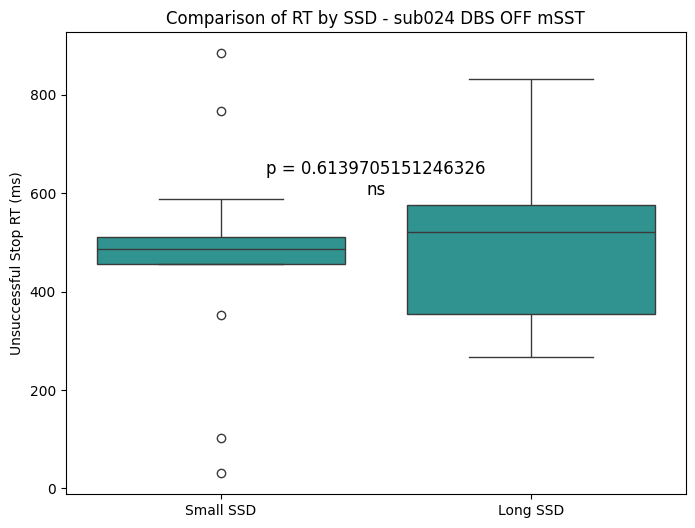

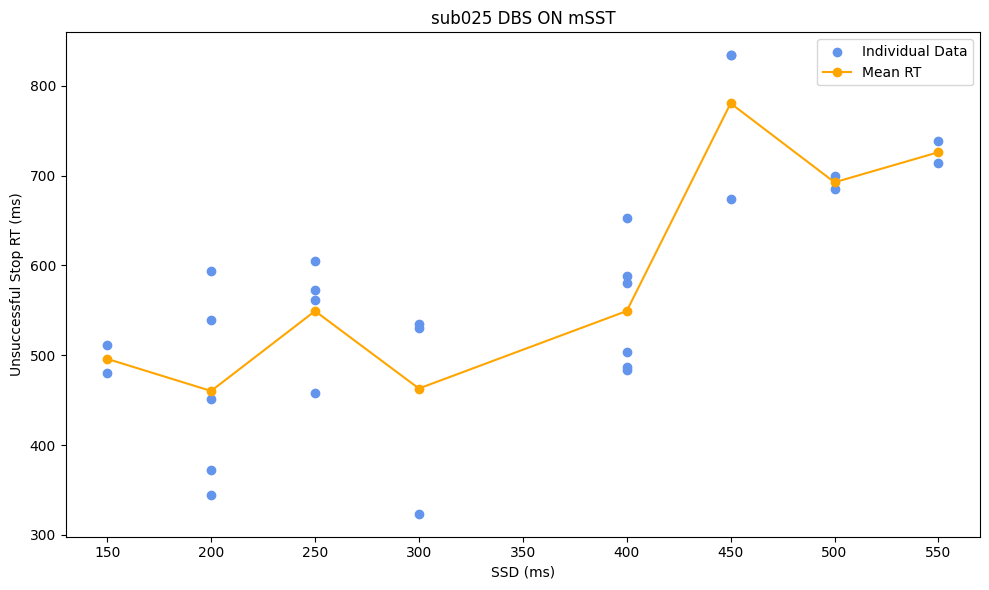

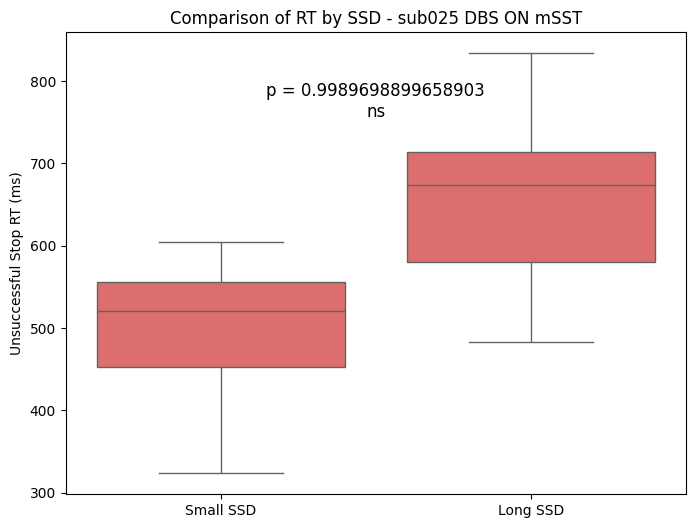

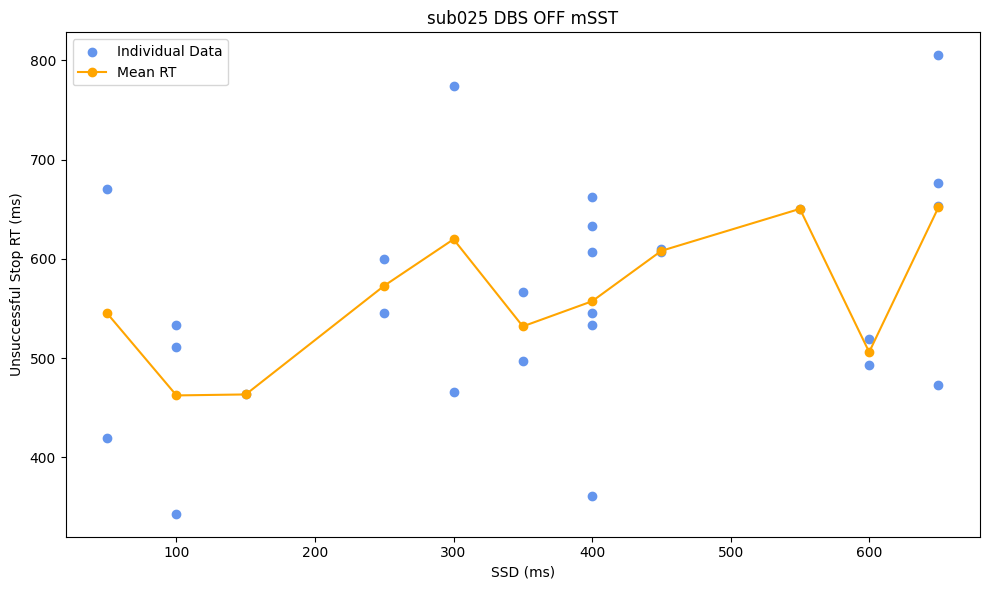

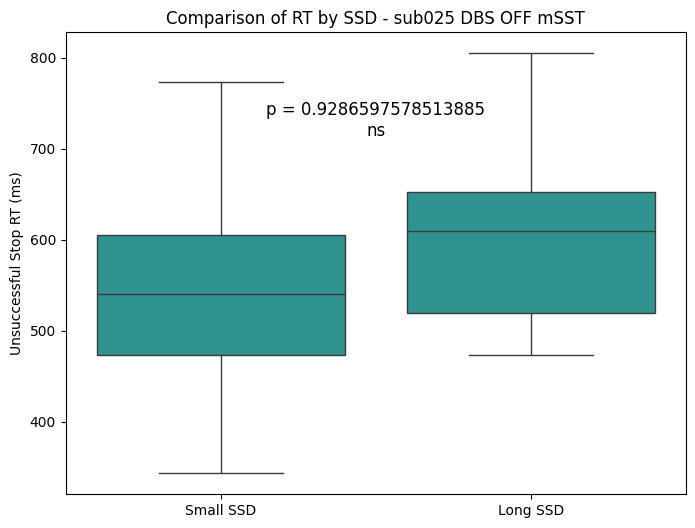

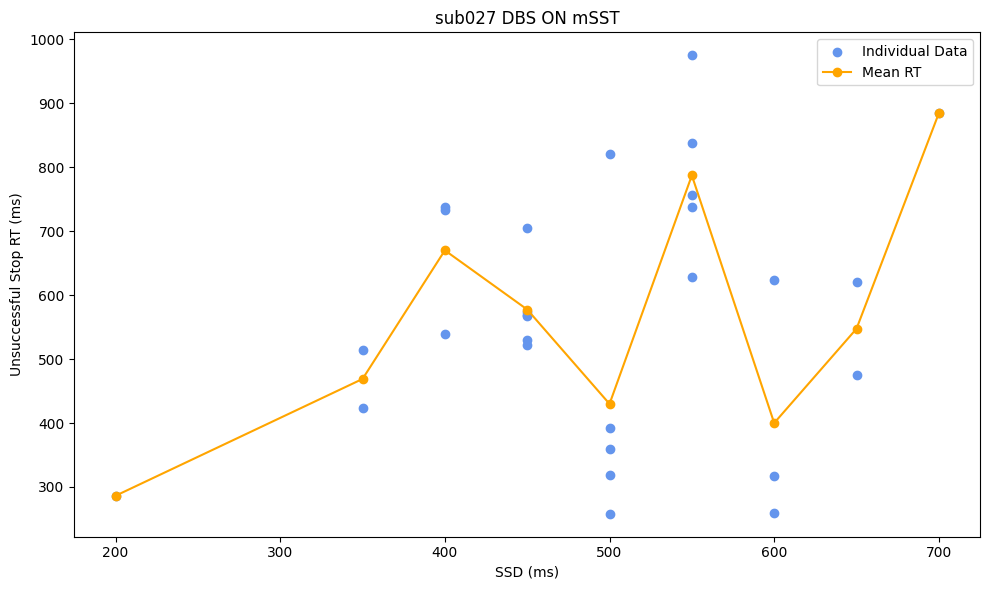

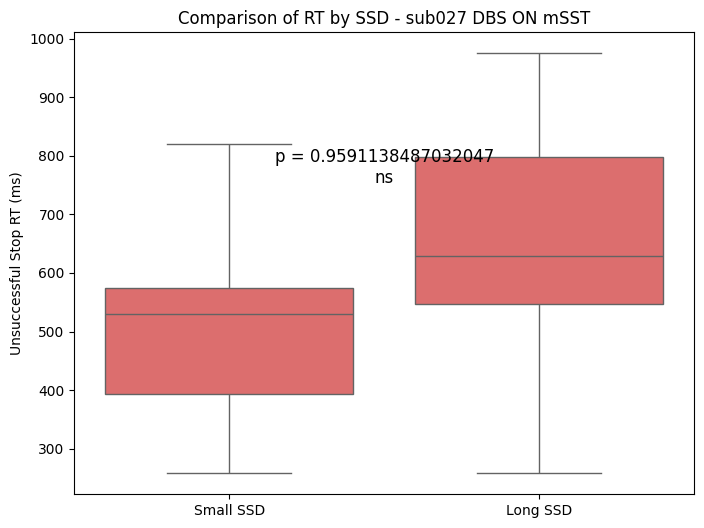

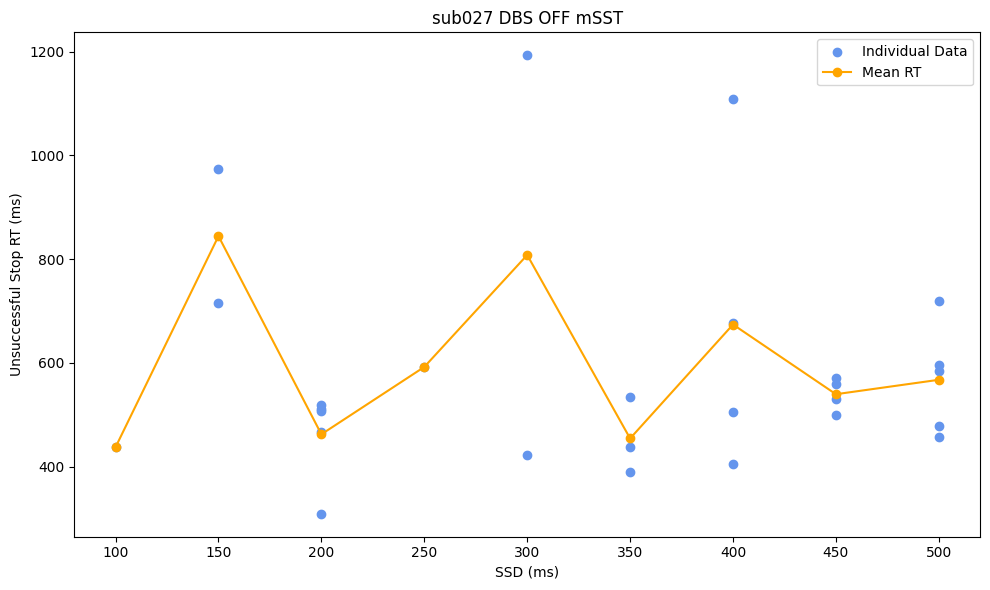

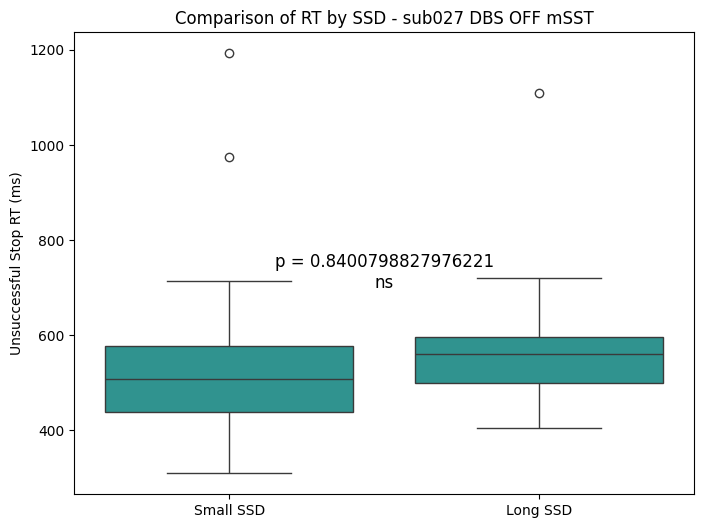

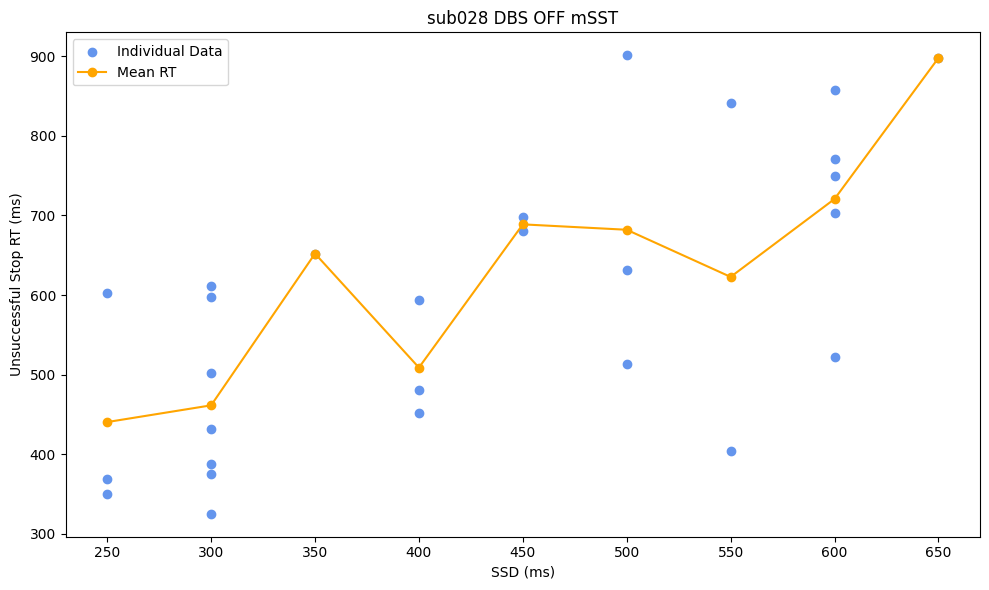

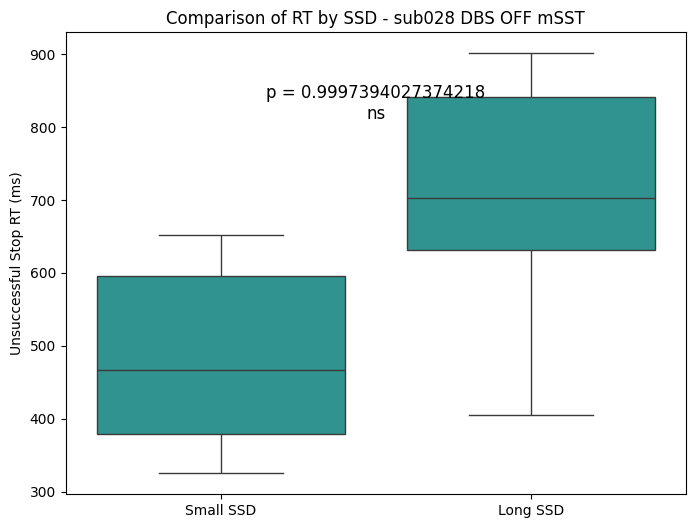

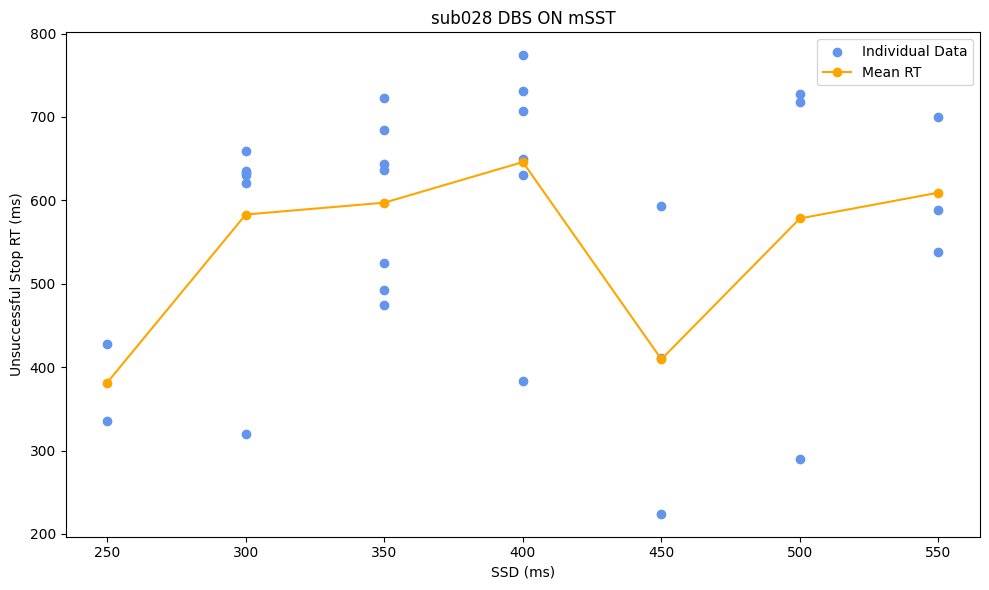

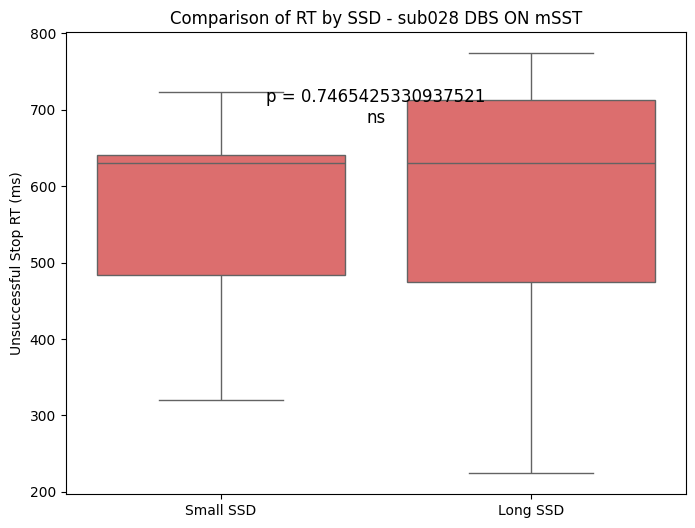

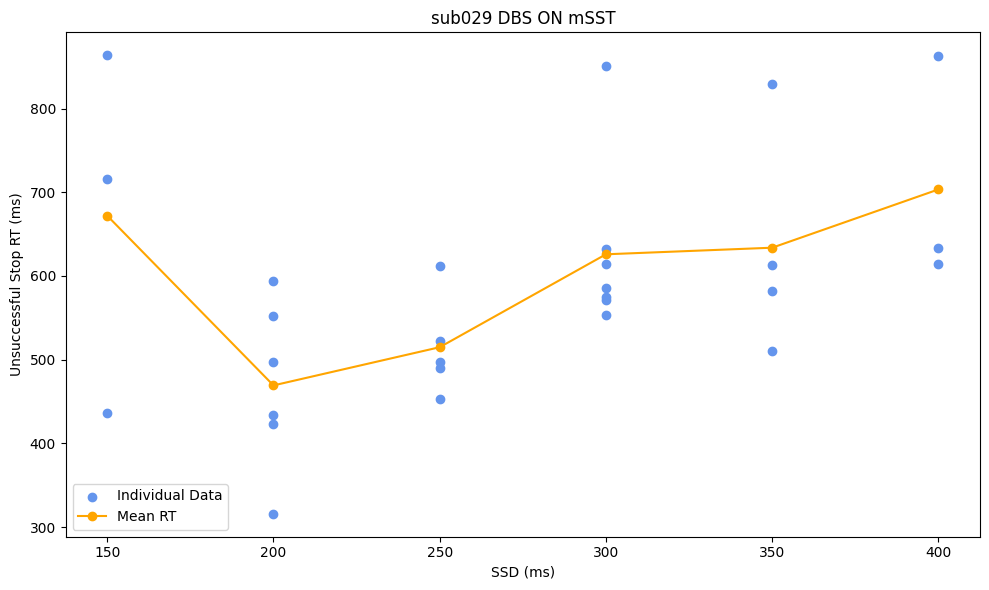

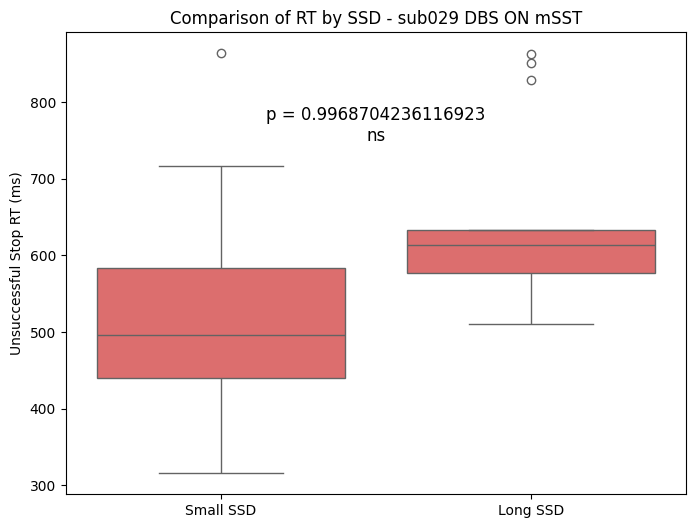

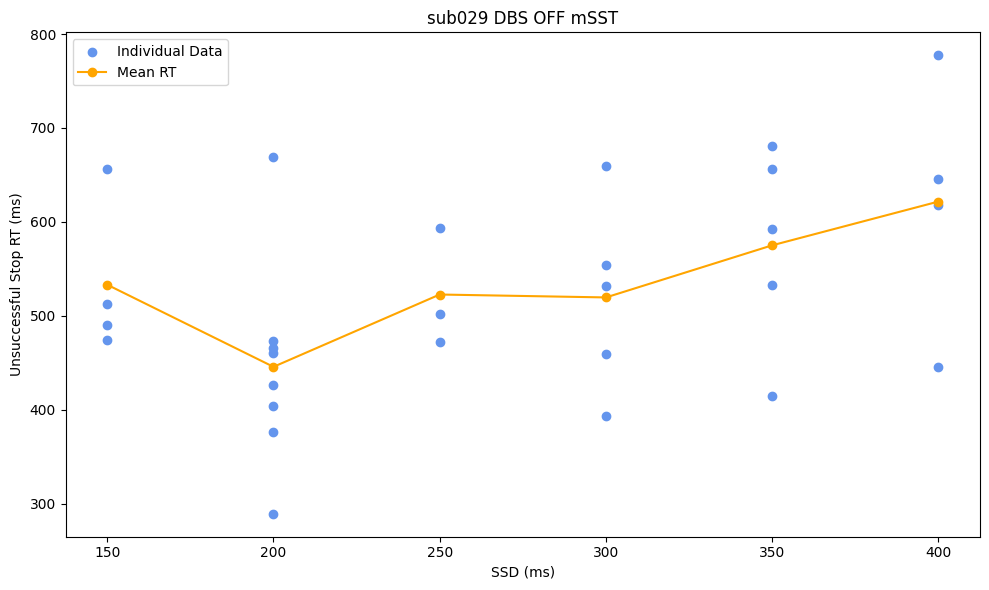

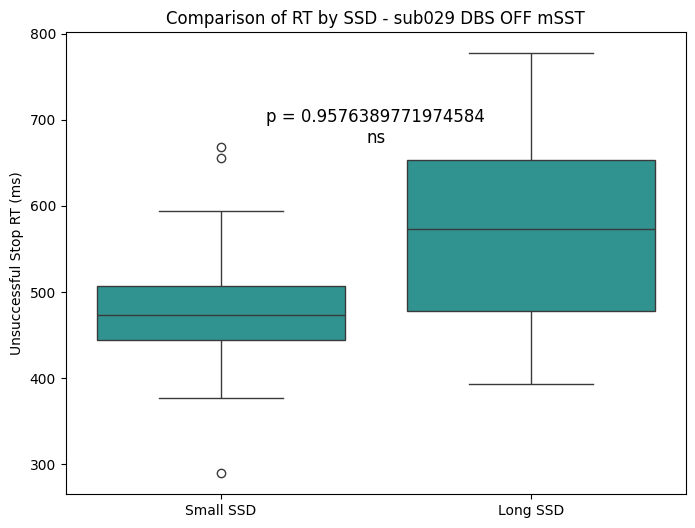

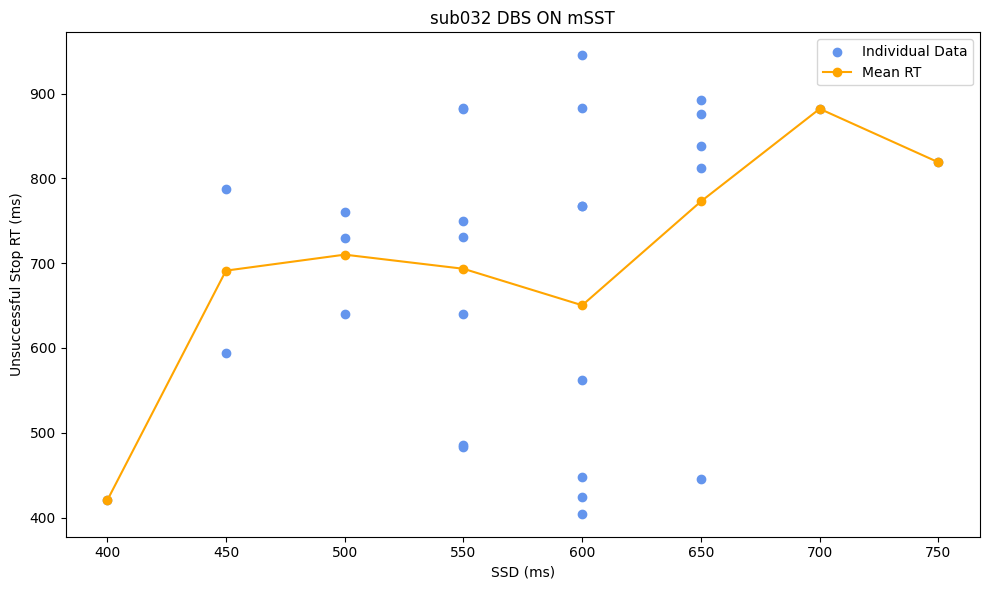

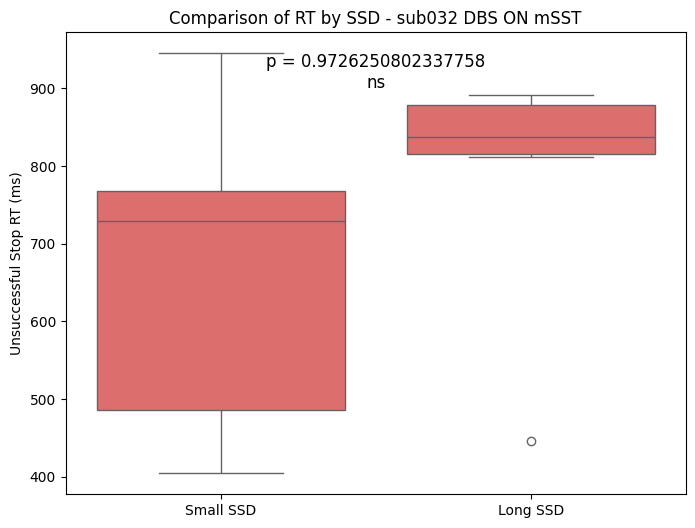

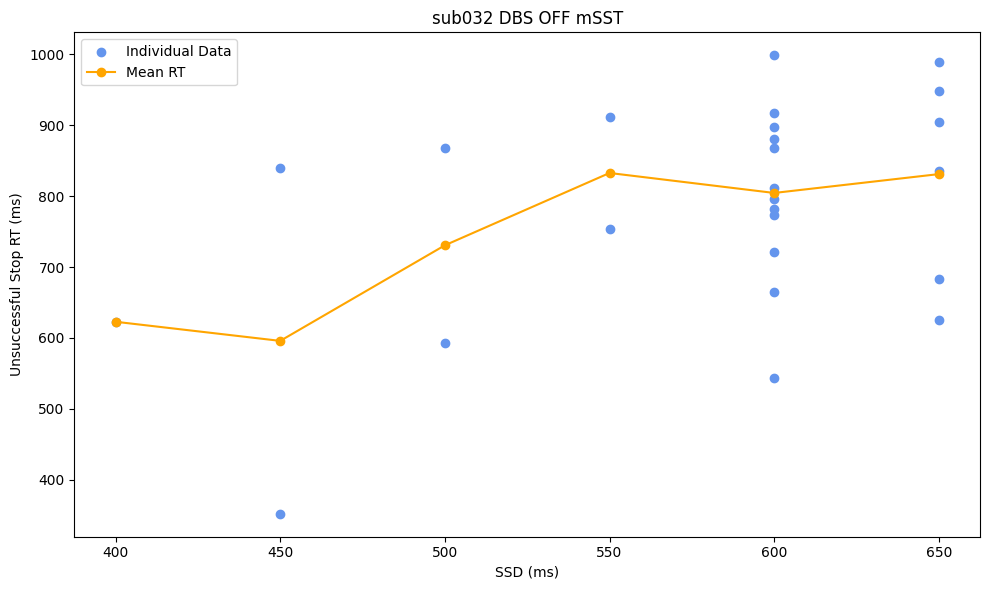

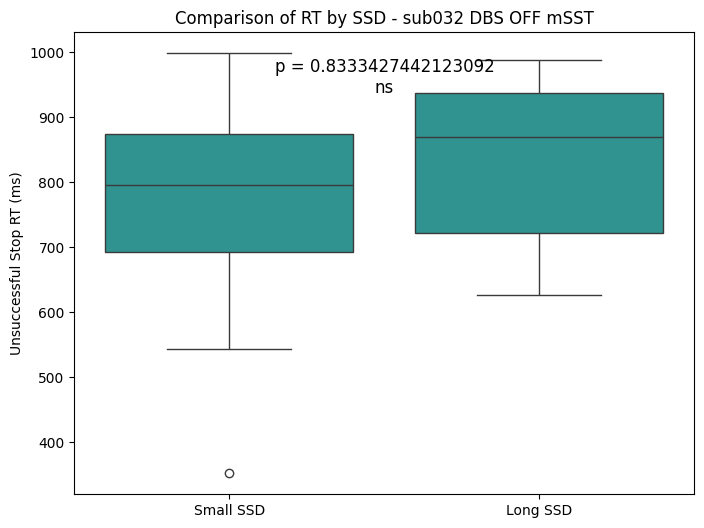

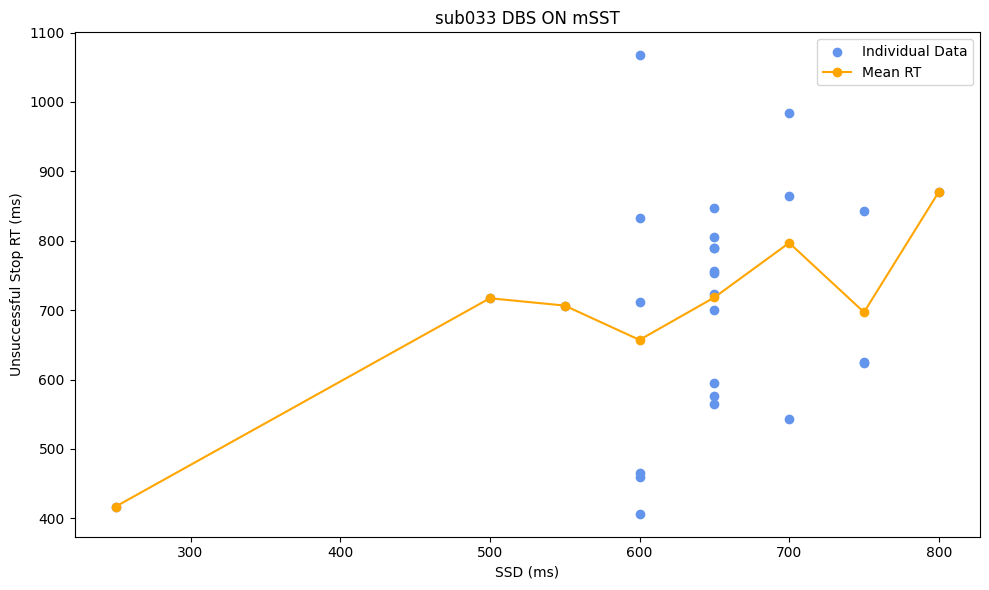

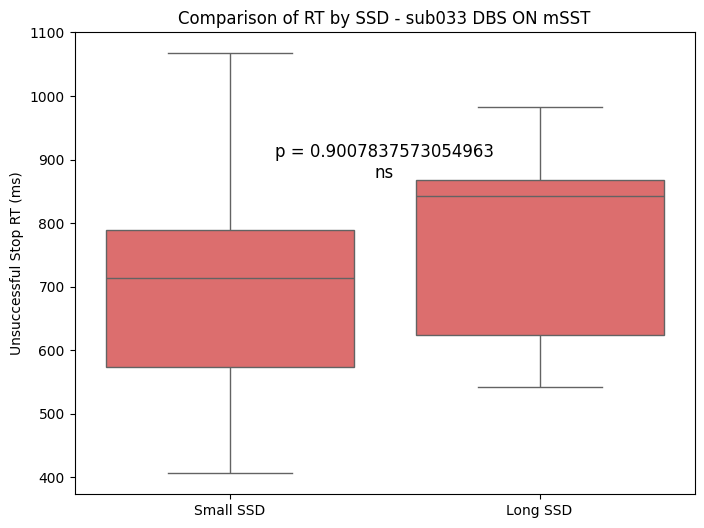

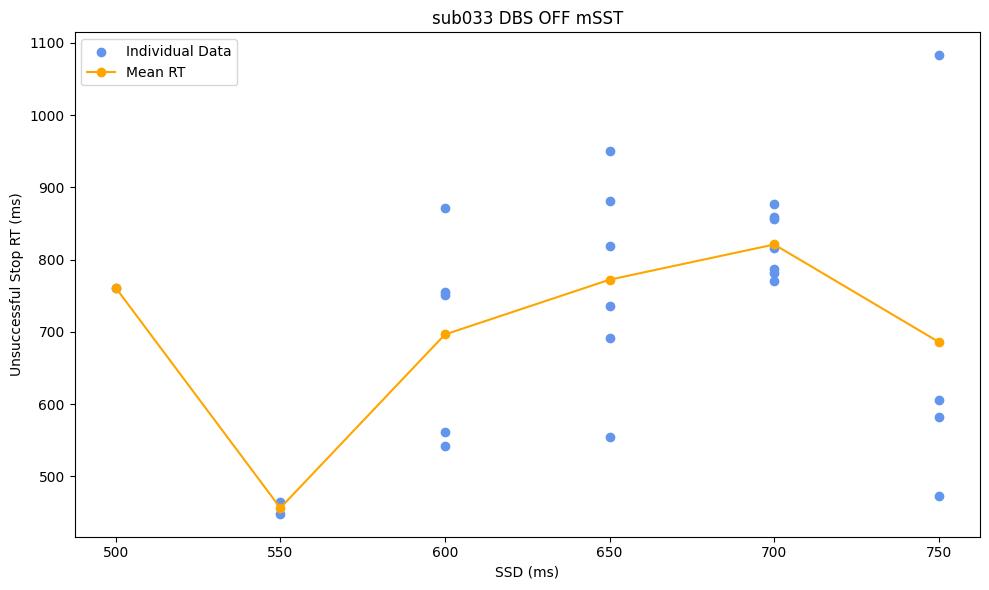

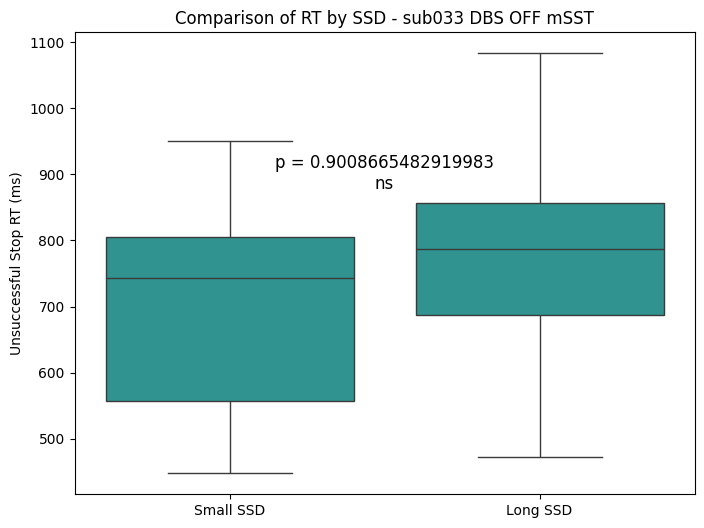

In [18]:
print("Testing RT-SSD relation at the single subject level...")
temp_save = join(behav_results_saving_path, "single sub RT-SSD relation")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)
excluded_subjects = hrm.check_independence_assumption_rt_ssd_relation(
    stats = stats, 
    excluded_subjects = excluded_subjects,
    color_dict = color_dict,   
    save_as = save_as,
    saving_path = temp_save,
    show_plot = True
)

In [19]:
excluded_subjects

['sub009 DBS OFF mSST', 'sub009 DBS ON mSST', 'C016 mSST']

## 3.4. OPTIONAL: a prediction of the model is that RT of unsuccessful stop trials should lengthen with increasing stop signal delay (ssd), because gradually more movements fail to be inhibited as the stop signal is delayed (replication from Hervault et al., 2021) ##

"A prediction of the model is that the RT in unsuccessful STOP trials should lengthen with increasing Stop signal delay (SSD), because gradually more movements fail to be inhibited as the STOP signal is delayed. In order to examine this prediction, RT from unsuccessful STOP trials were averaged across participants at each given SSD. From these mean values, the differences were then computed between each SSD and the immediately shorter SSD. A one–sided t-test showed the differential values to be significantly positive for both the pressing (t(6) = 3.42, p <.05) and the swiping type (t(6) = 3.47, p < .05), which confirmed the expected increase of the RT(unsuccessful STOP trials) as function of SSD". 

Testing RT-SSD relation at the group level...


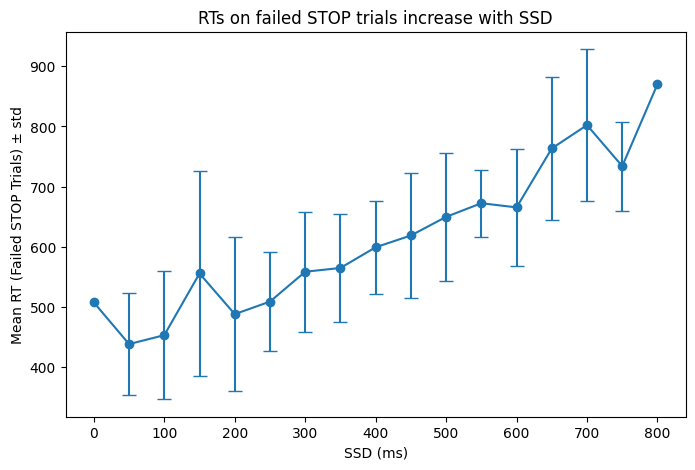

The differential values were significantly positive (t(15) =  1.536, p = 0.0726) which confirms the prediction of the model, that the RT in unsuccessful STOP trials should lengthen with increasing Stop signal delay (SSD).


In [20]:
print("Testing RT-SSD relation at the group level...")
temp_save = join(behav_results_saving_path, "group RT-SSD relation")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)
hrm.check_independence_assumption_rt_ssd_relation_group_level(
    stats = stats, 
    excluded_subjects = excluded_subjects,
    save_as = save_as,
    saving_path = temp_save,
    show_plot = True
) 

In [21]:
excluded_subjects

['sub009 DBS OFF mSST', 'sub009 DBS ON mSST', 'C016 mSST']

# 4. Check the success rate / omission #

Participants should have a good success rate to evaluate further behavioral measures. If the success rate is too low, they might have not understood the task sufficiently well to make any further deduction, and should be excluded.

Cut-offs:

    - Success rate on GO trials should be >70%
    
    - Success rate on Stop trials should be comprised between 35-65% (see Ray et al 2012 - Charlotte sent on Teams)

Here, percent correct trial for each trial type is calculated after removing 
early presses (therefore, it only takes into account trials during which the 
cue was actally presented).

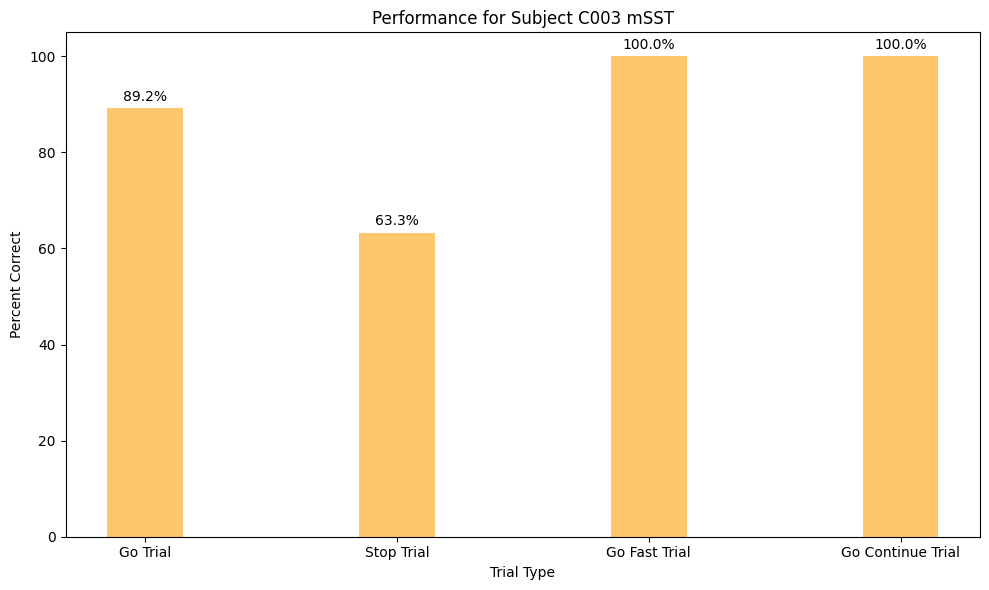

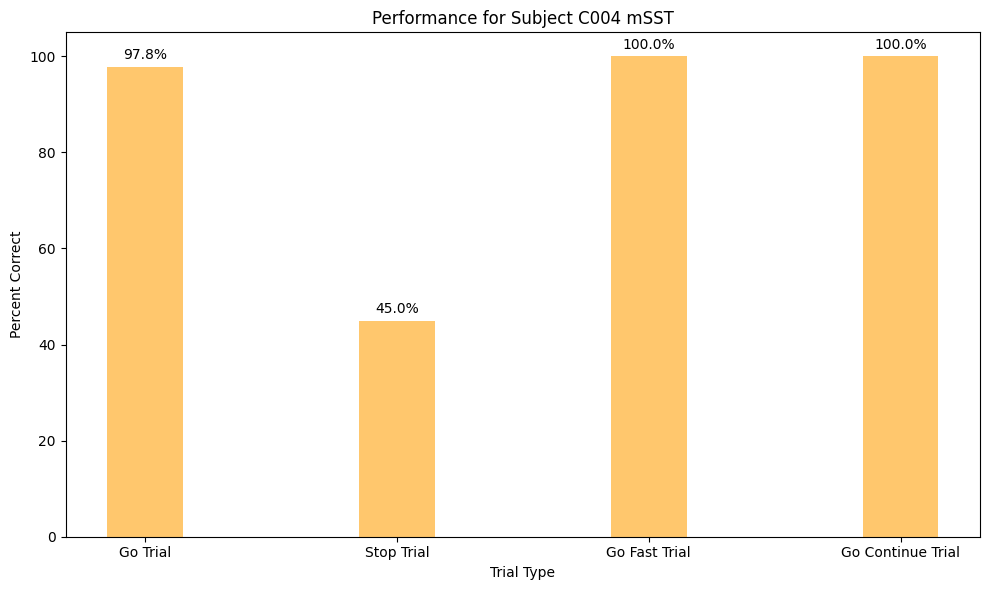

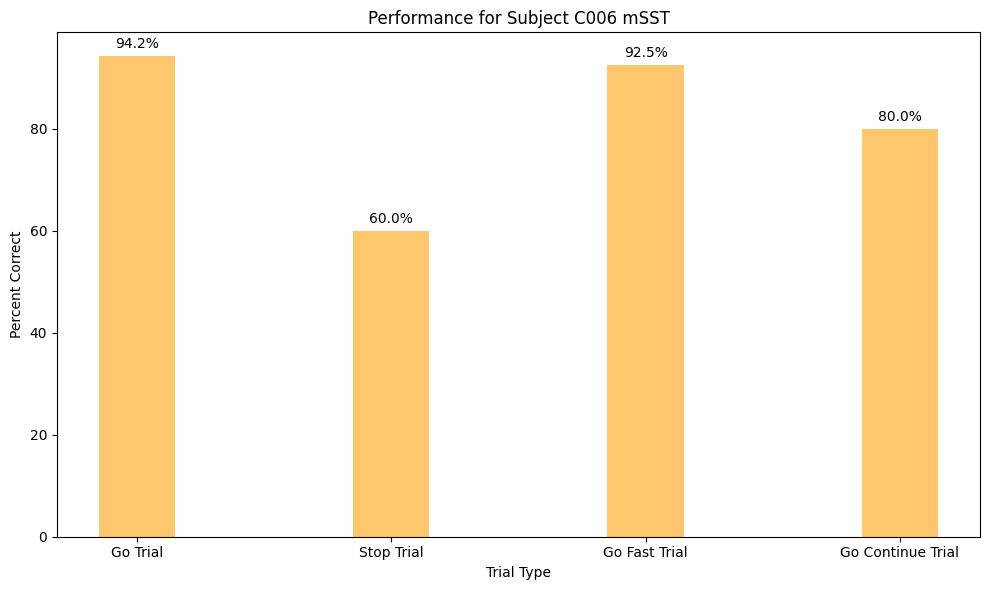

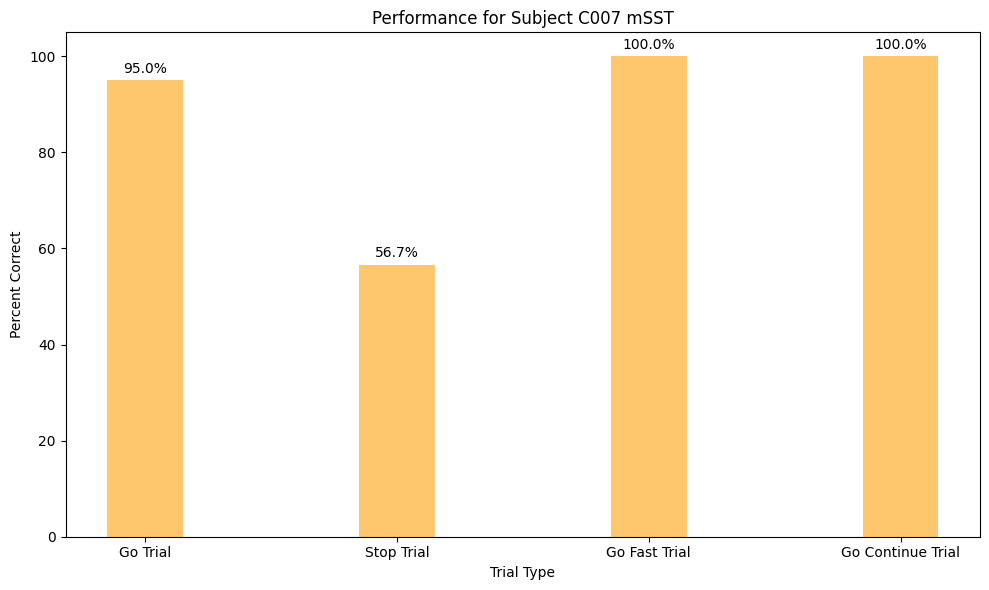

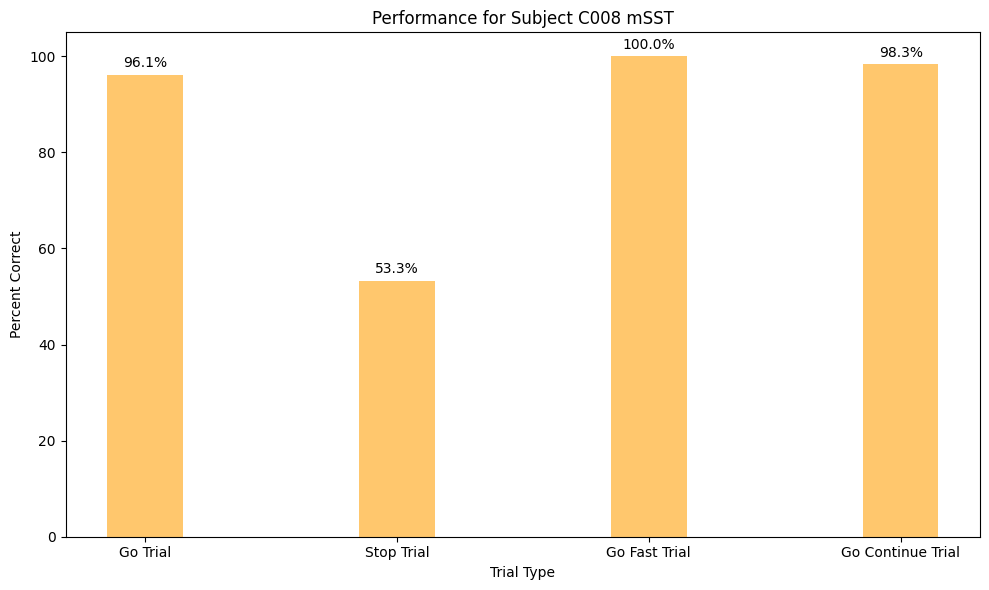

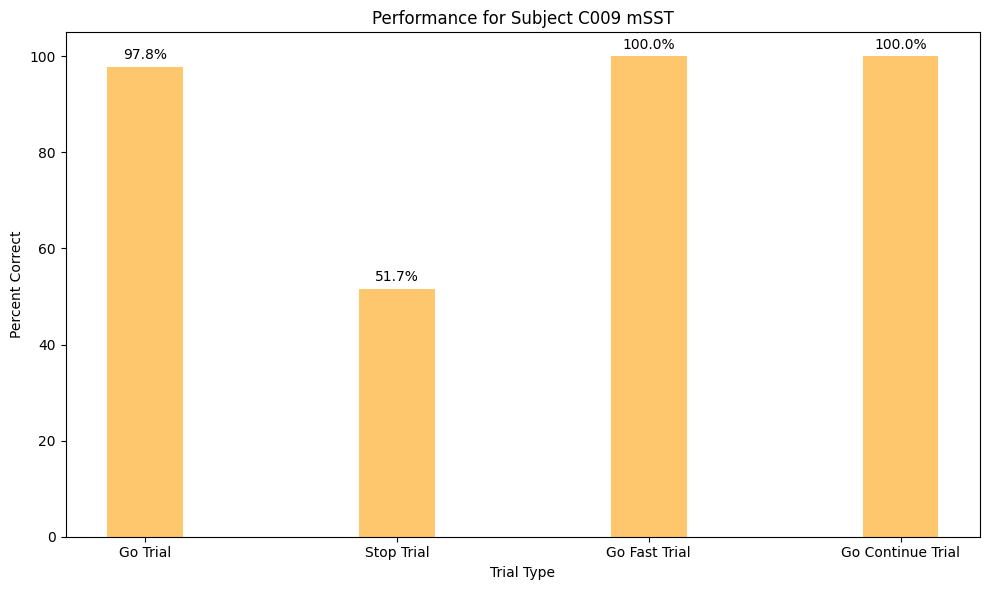

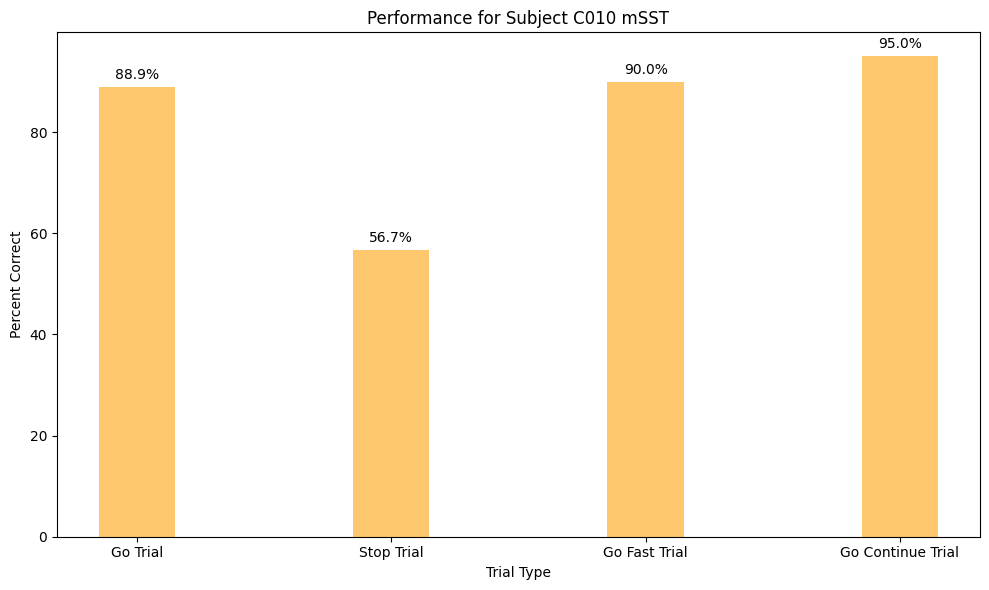

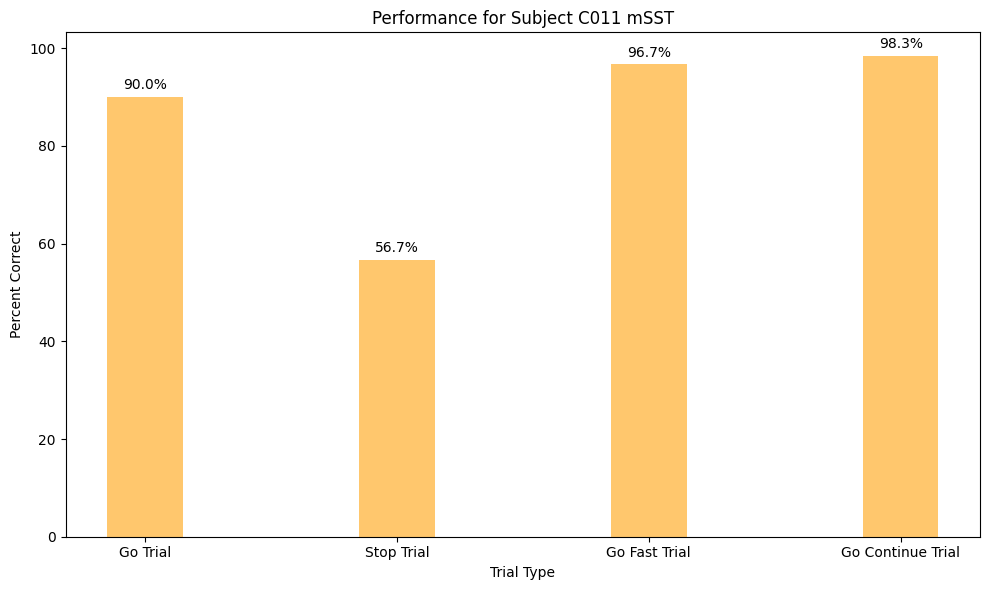

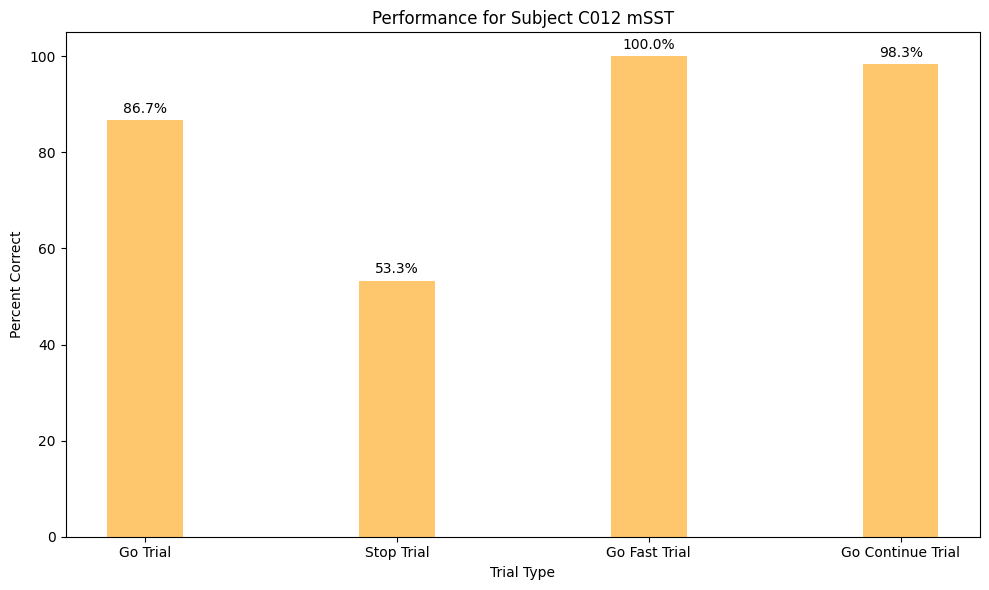

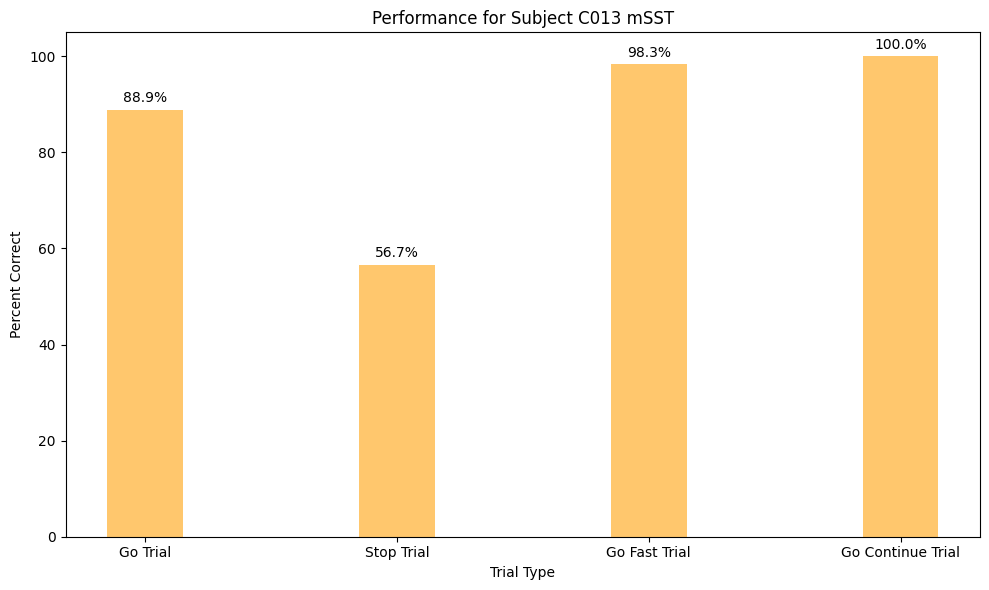

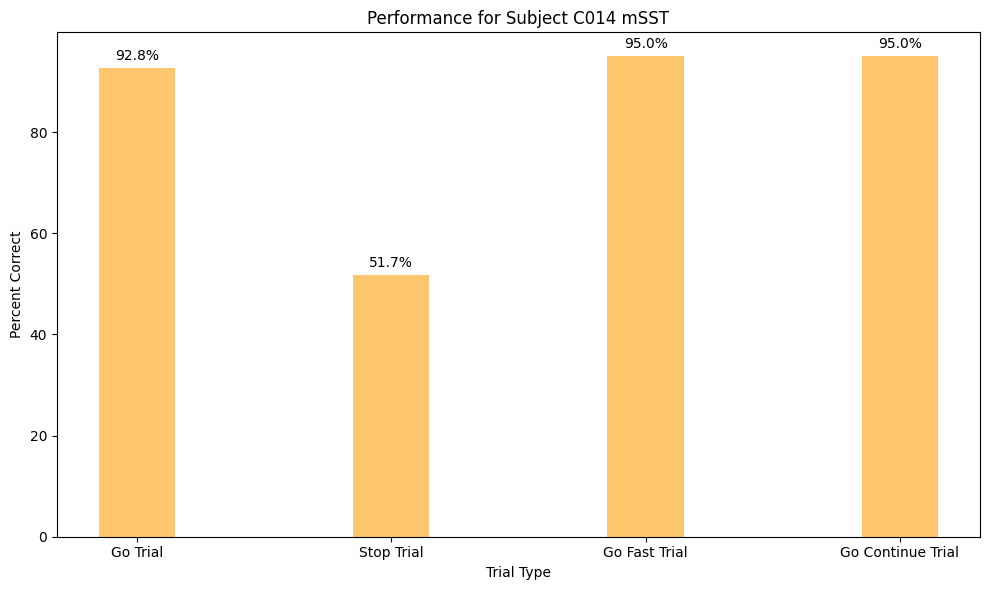

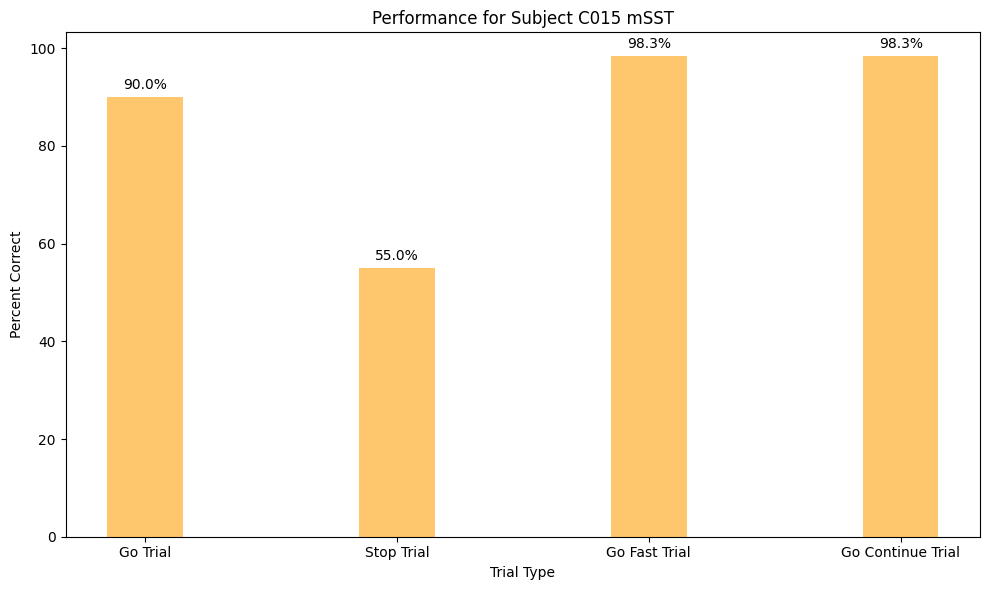

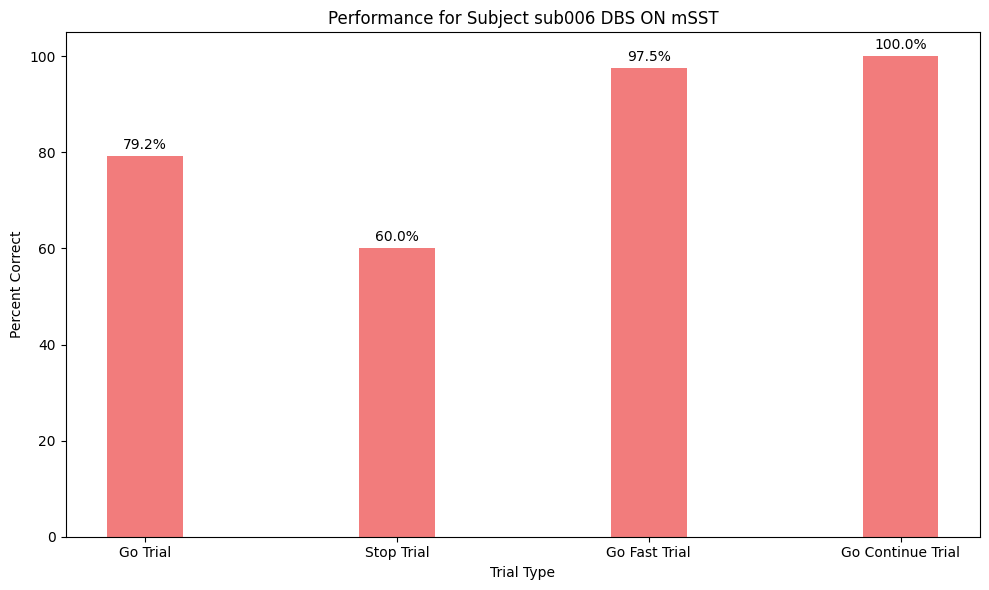

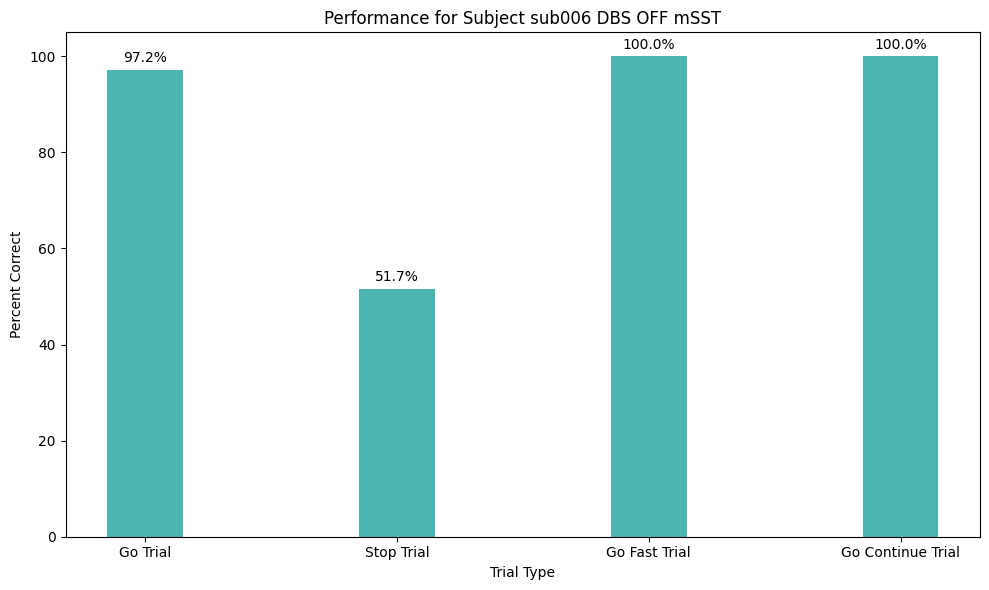

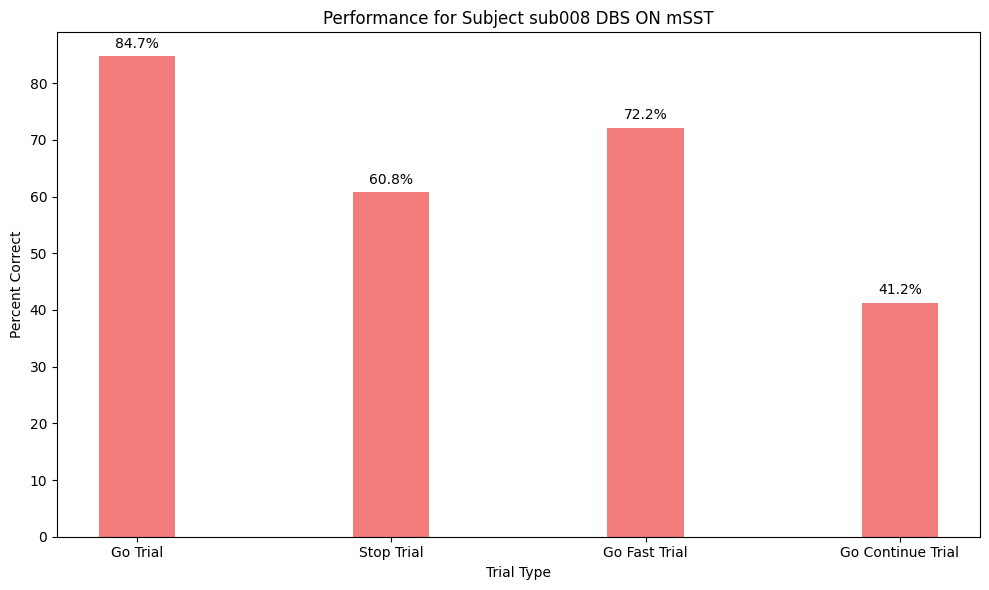

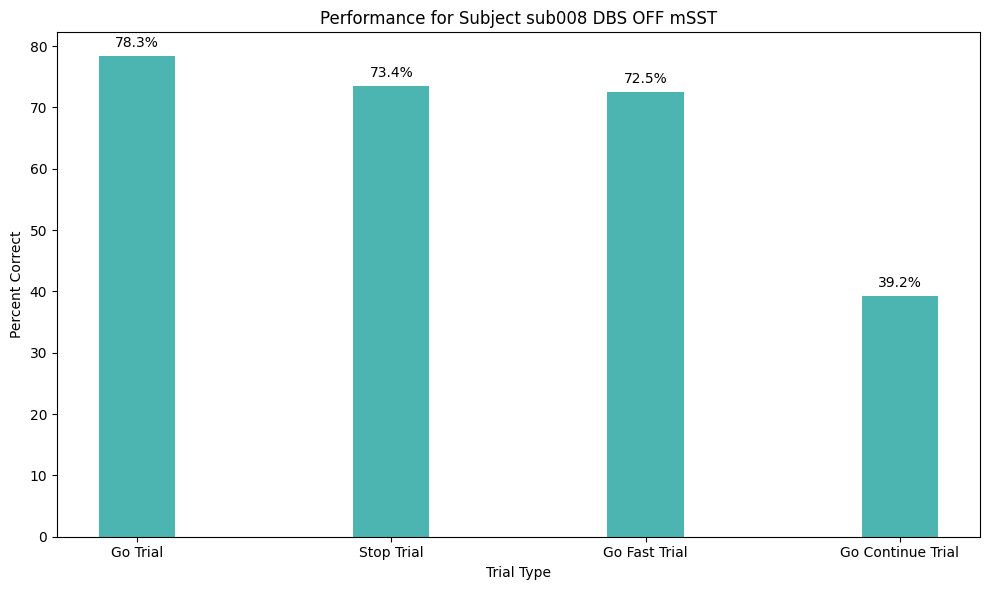

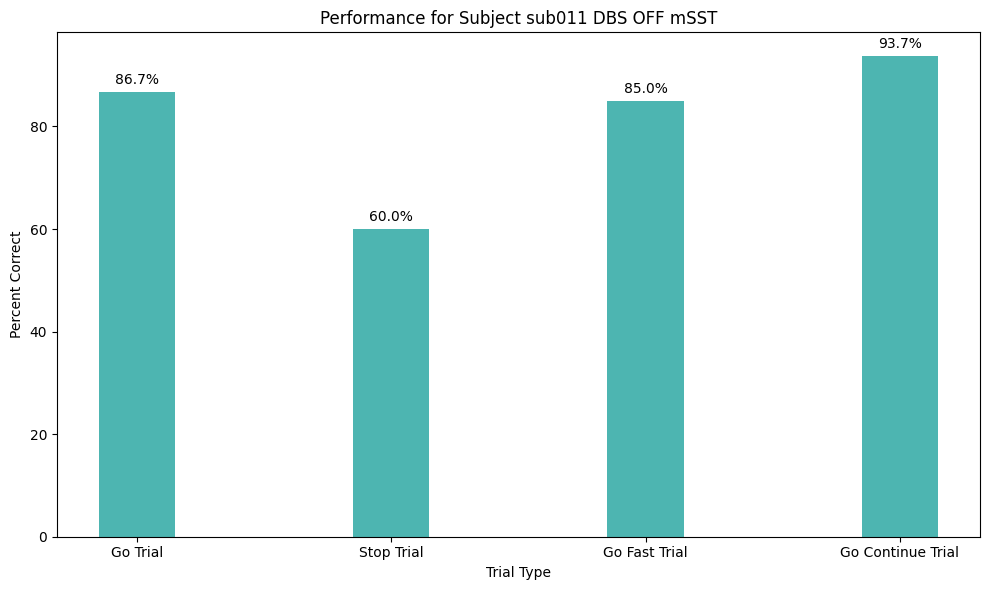

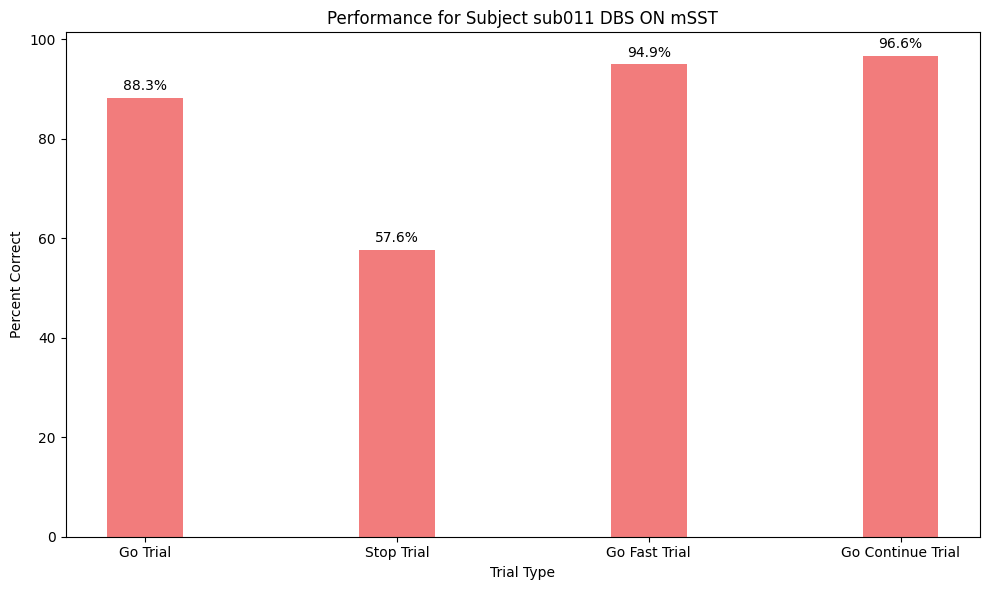

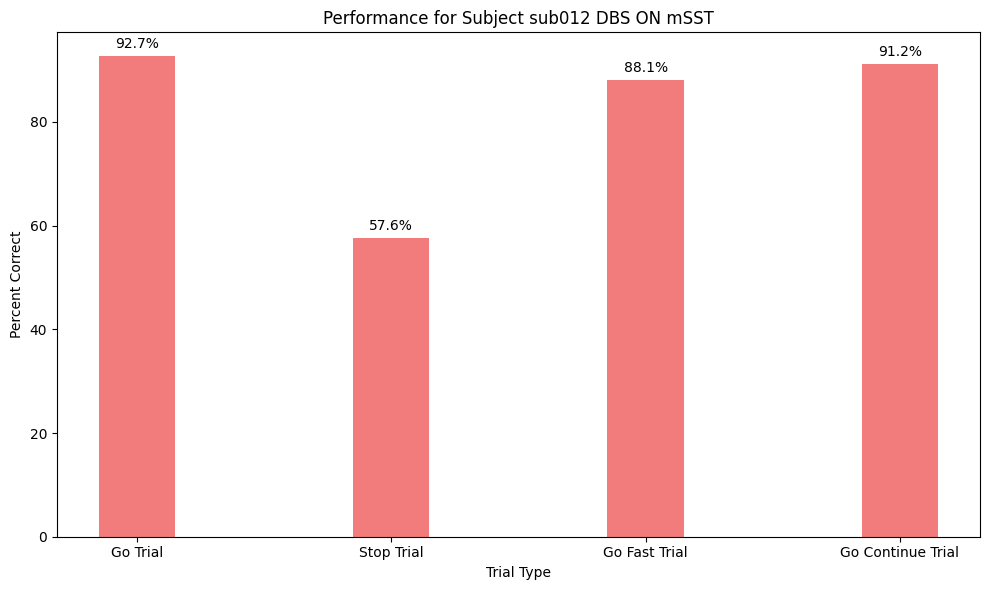

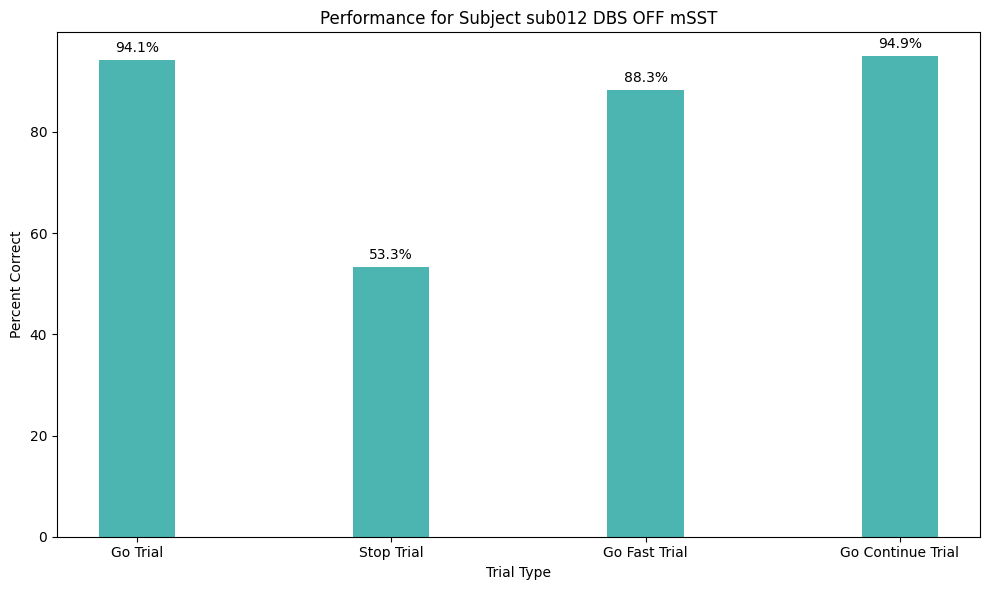

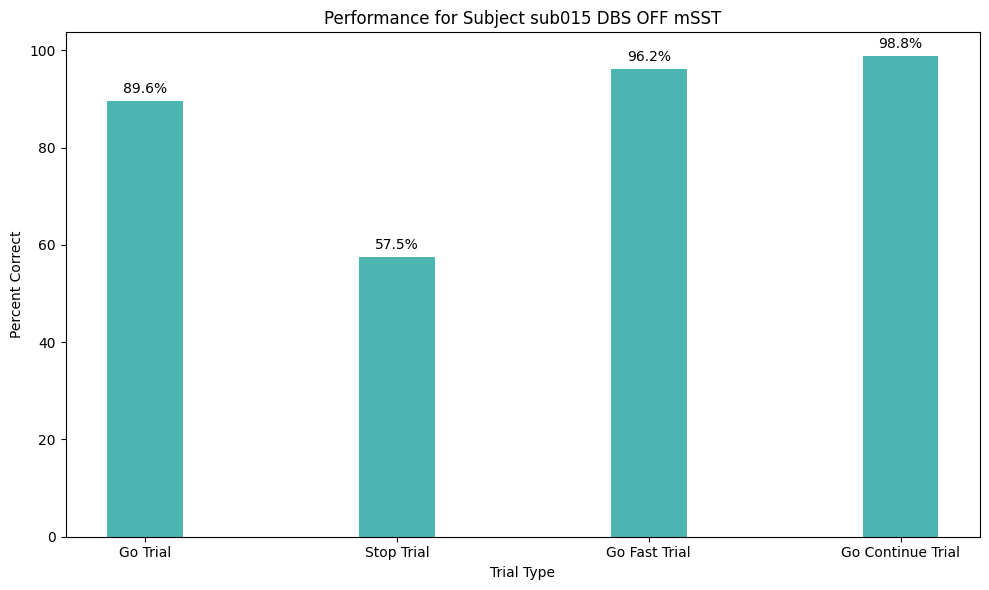

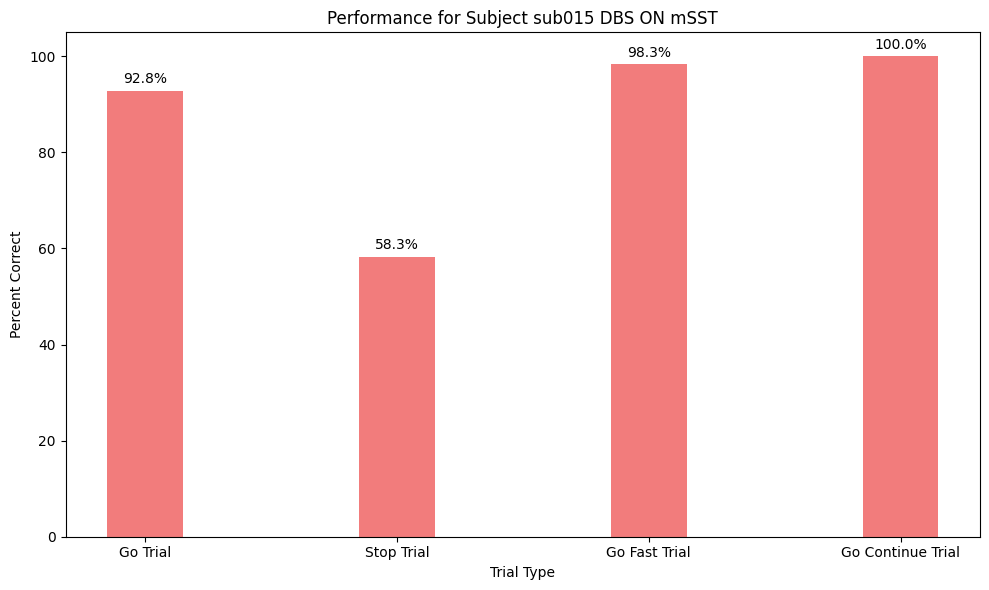

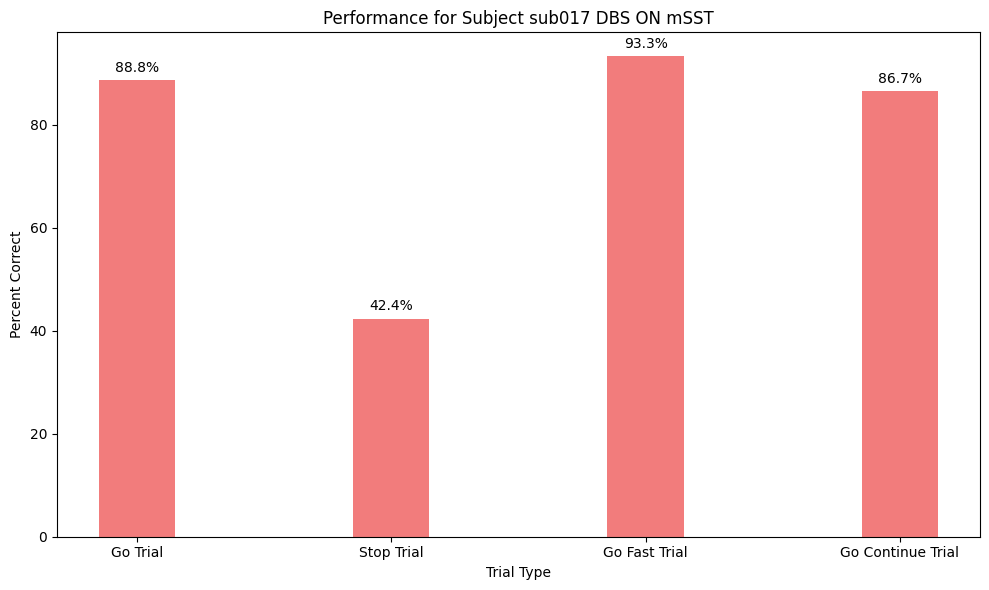

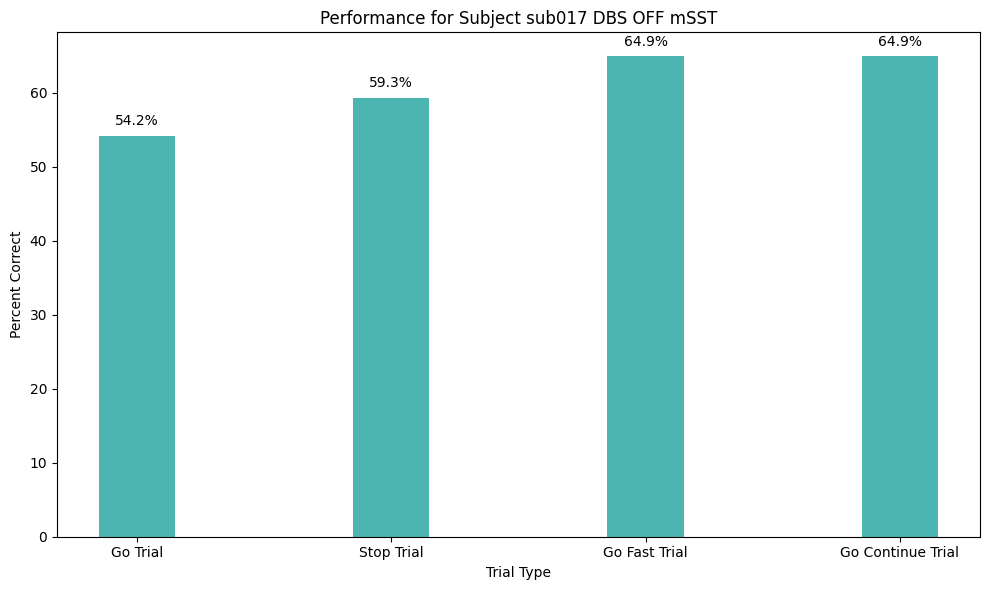

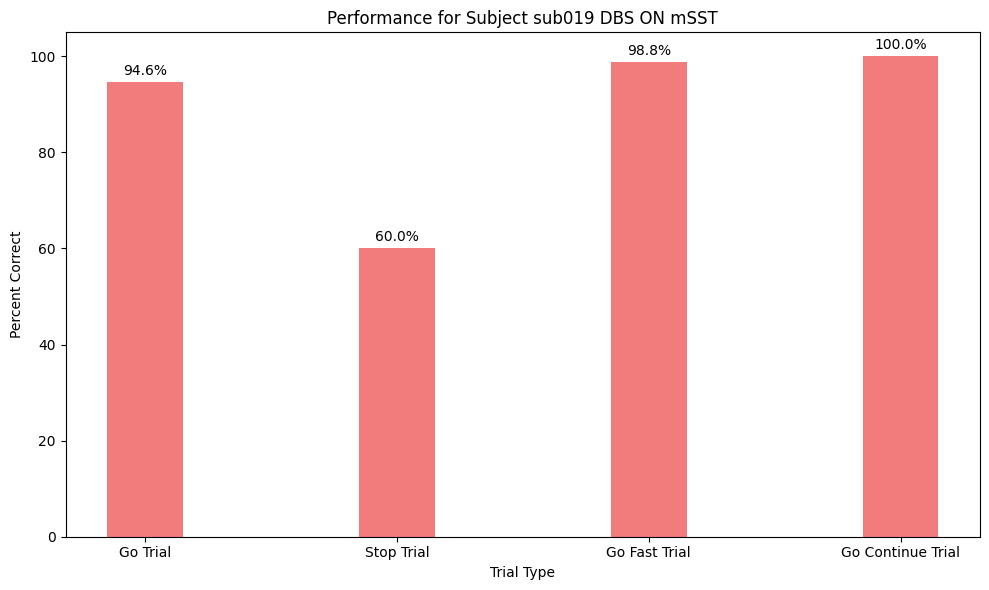

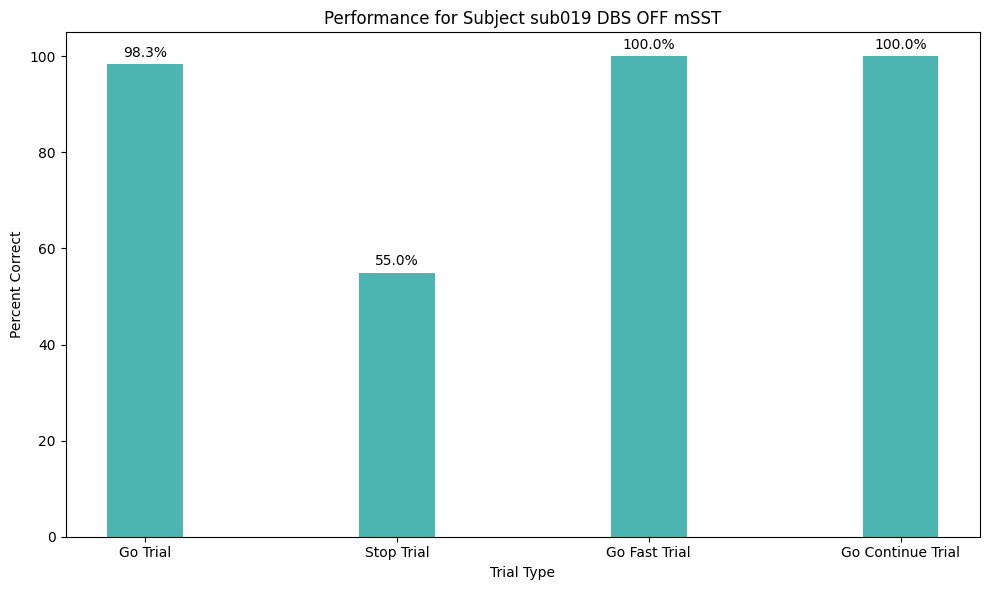

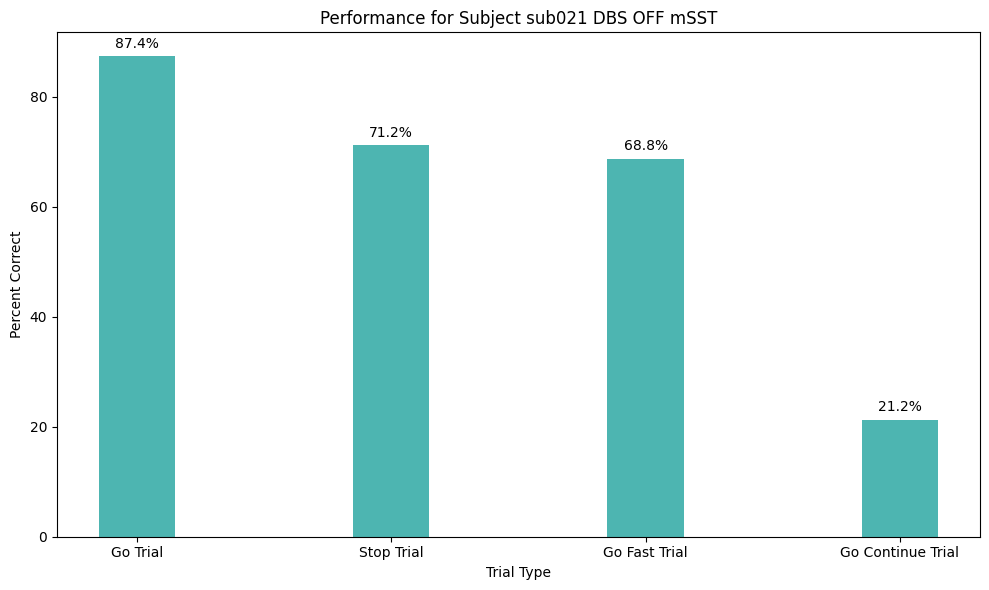

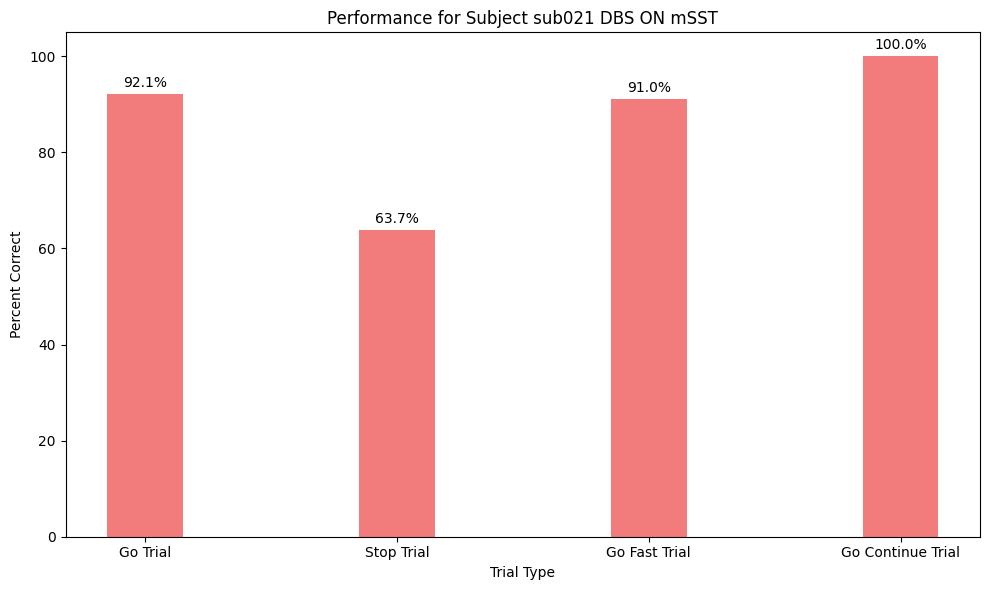

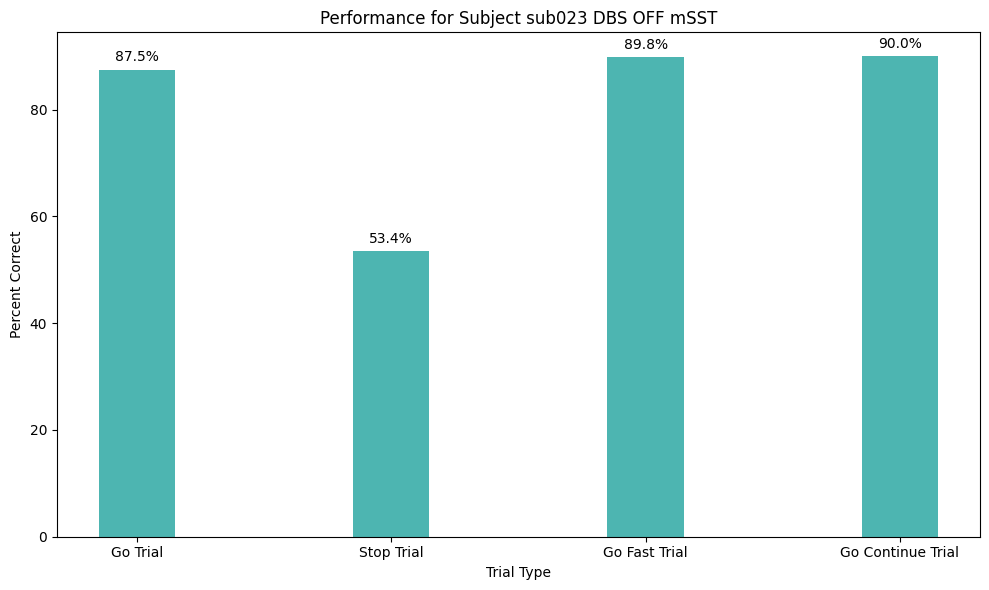

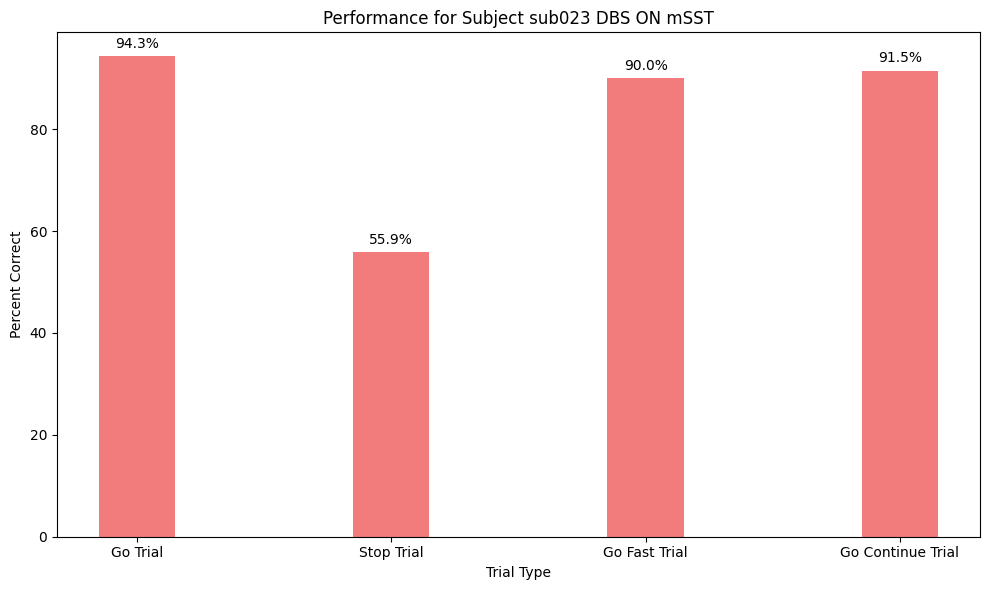

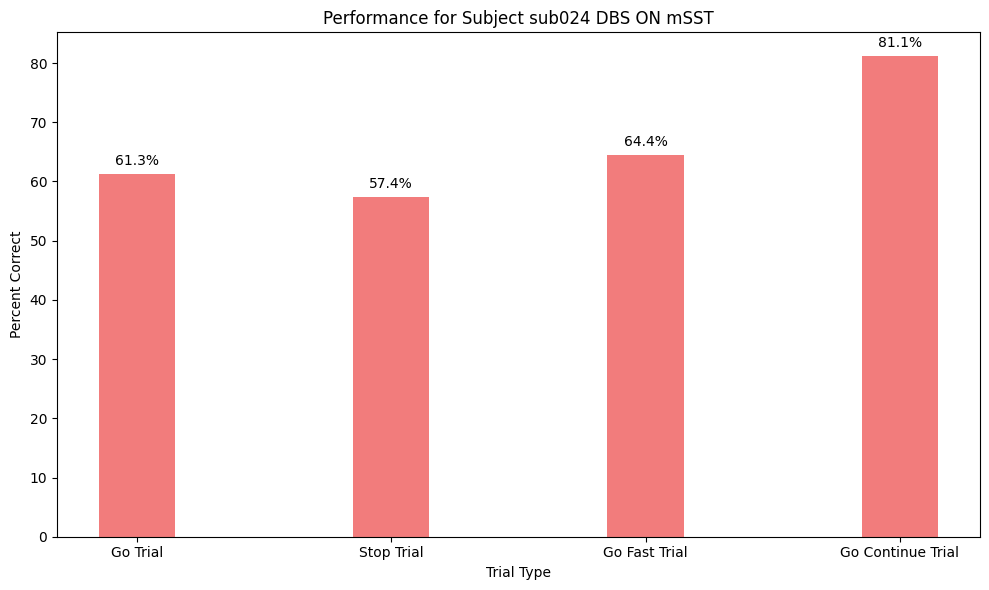

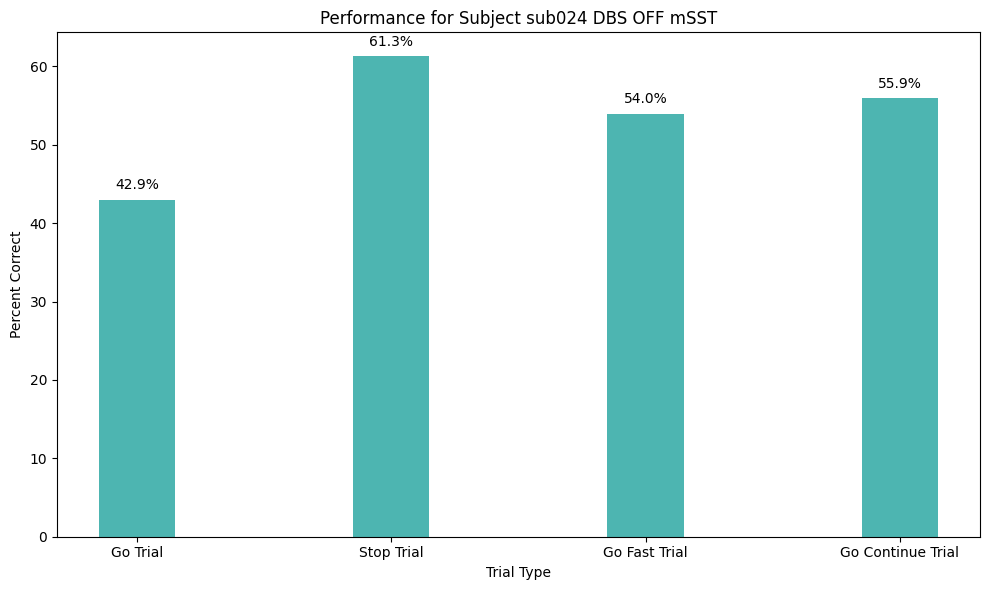

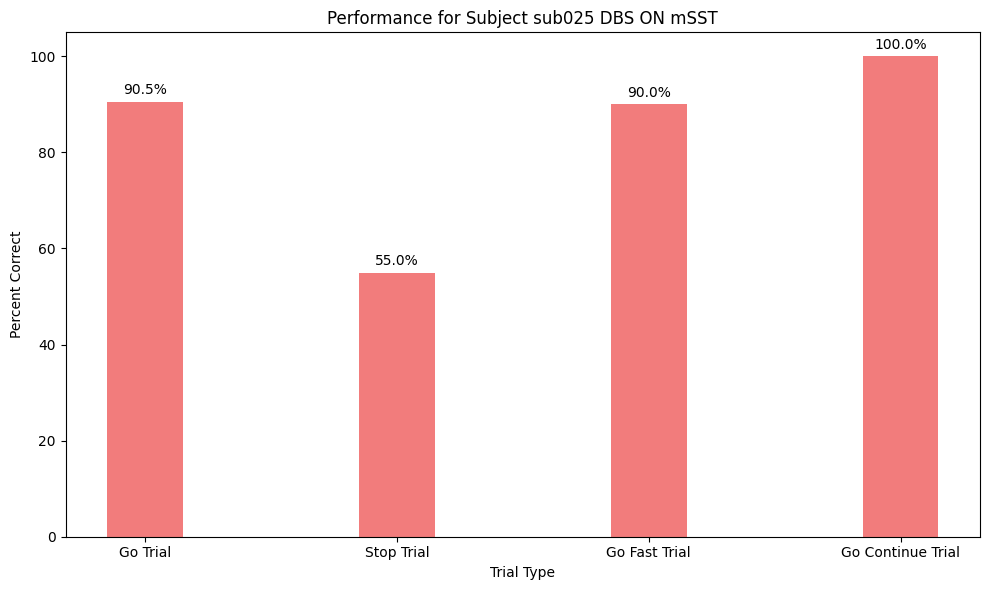

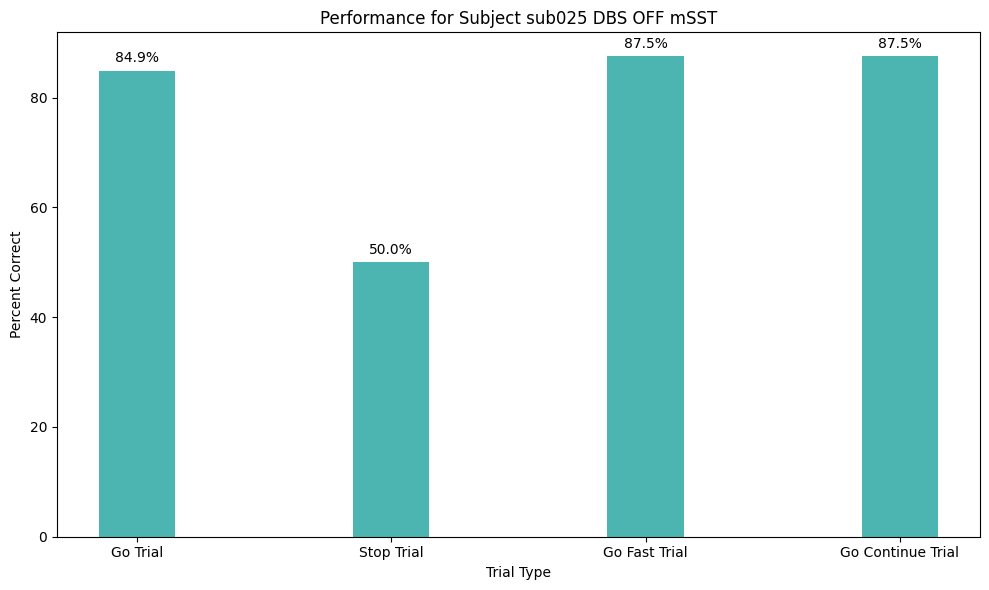

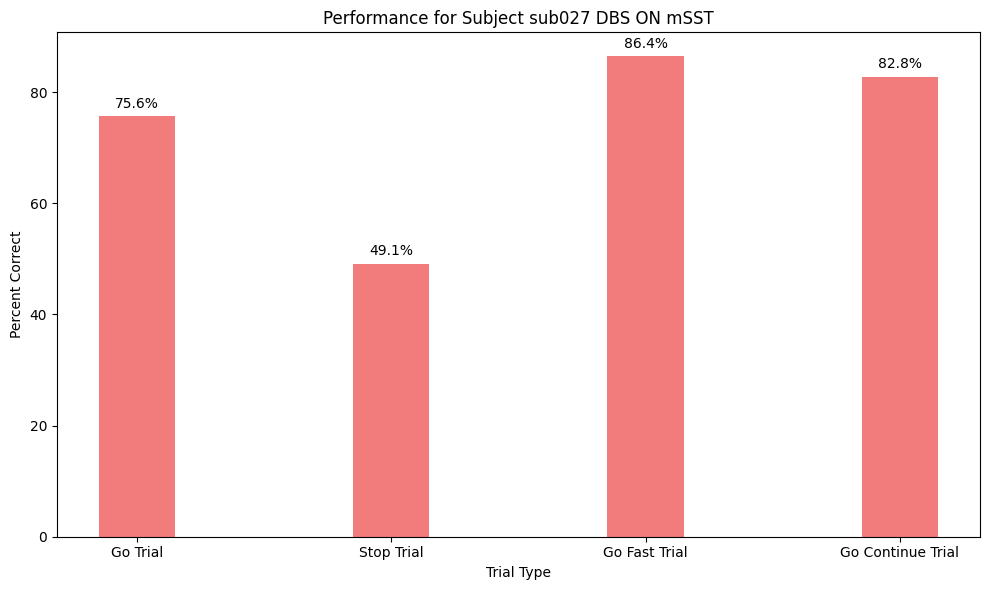

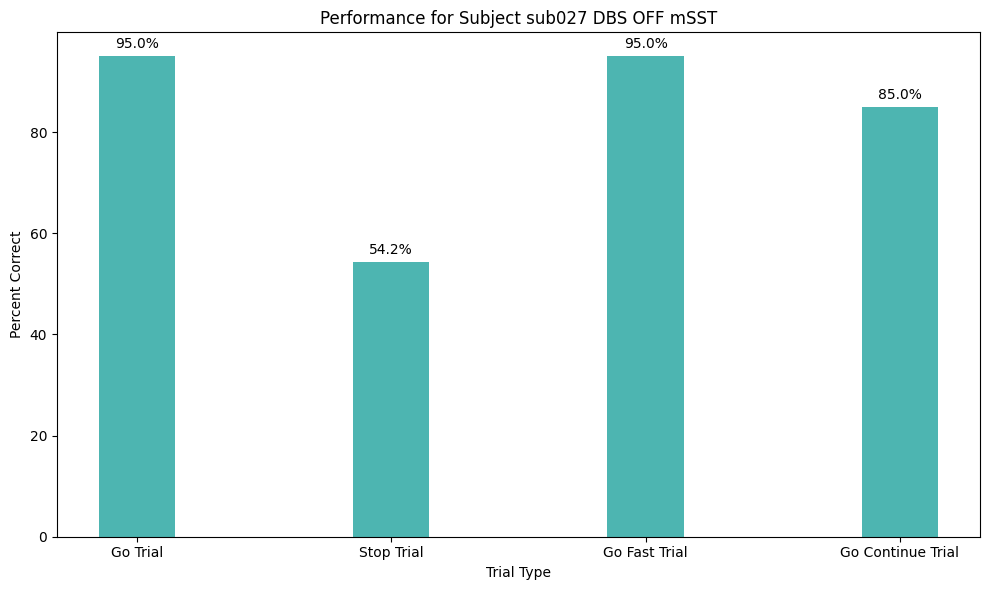

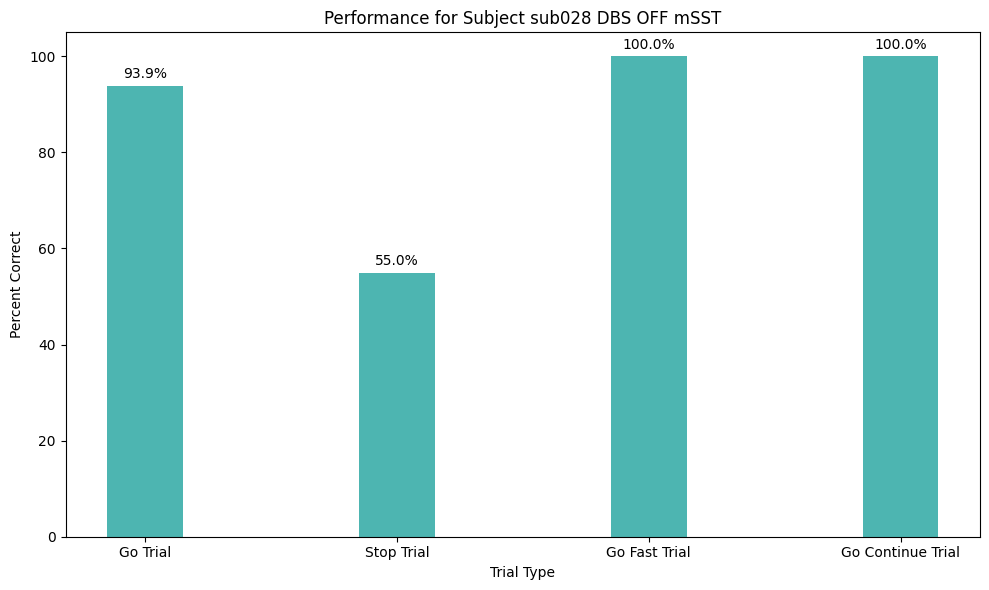

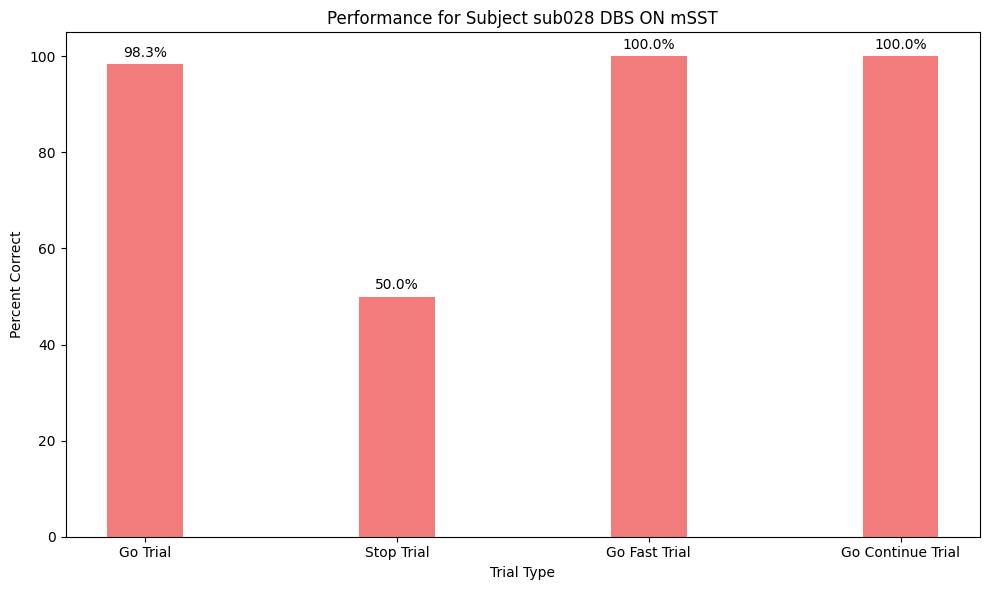

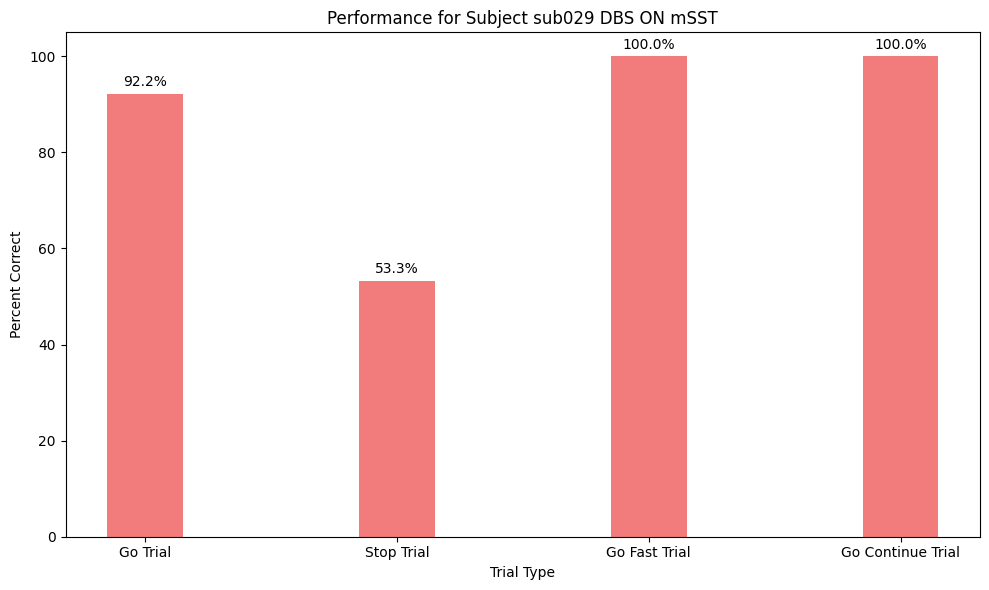

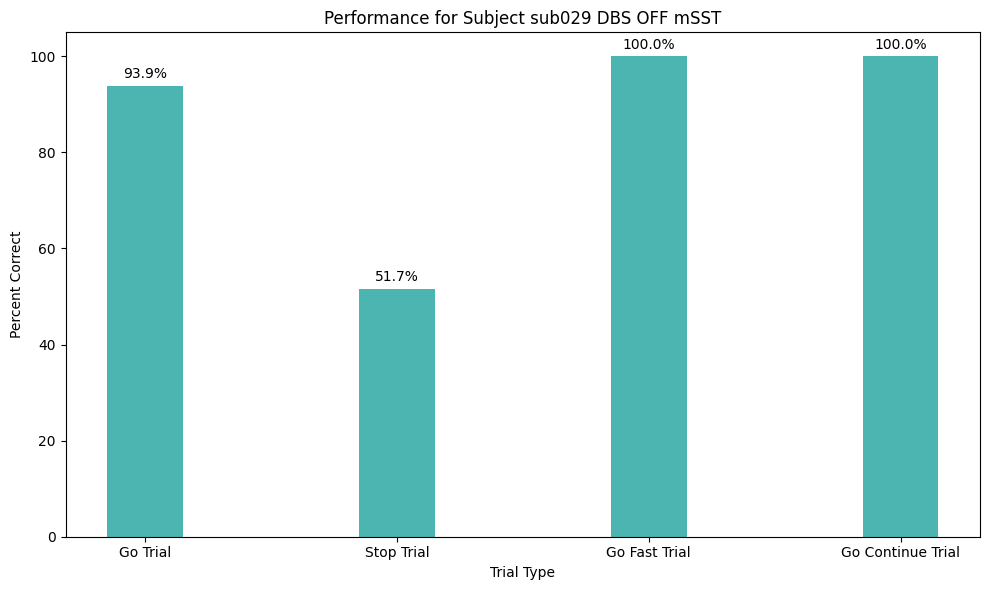

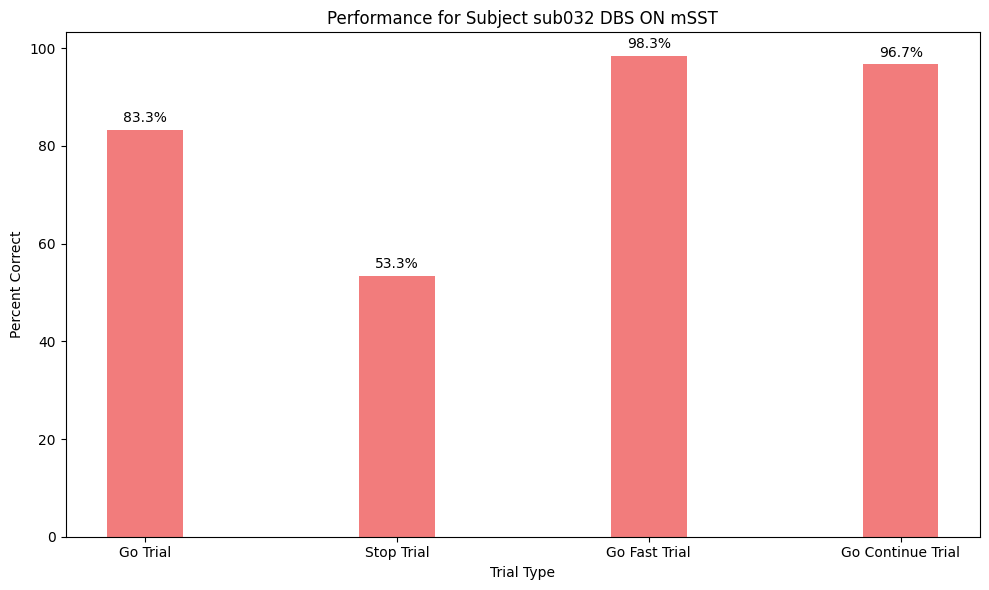

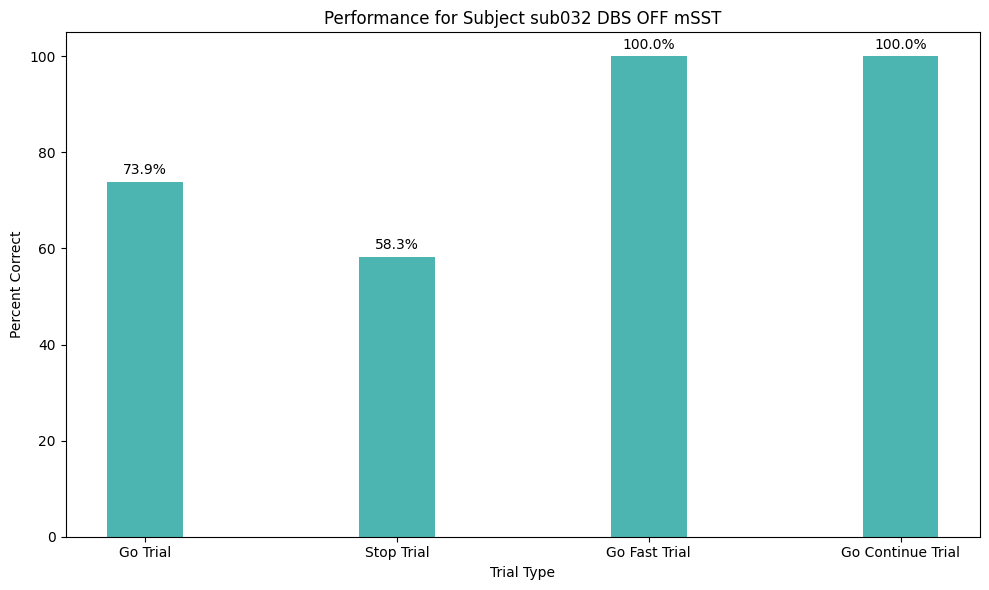

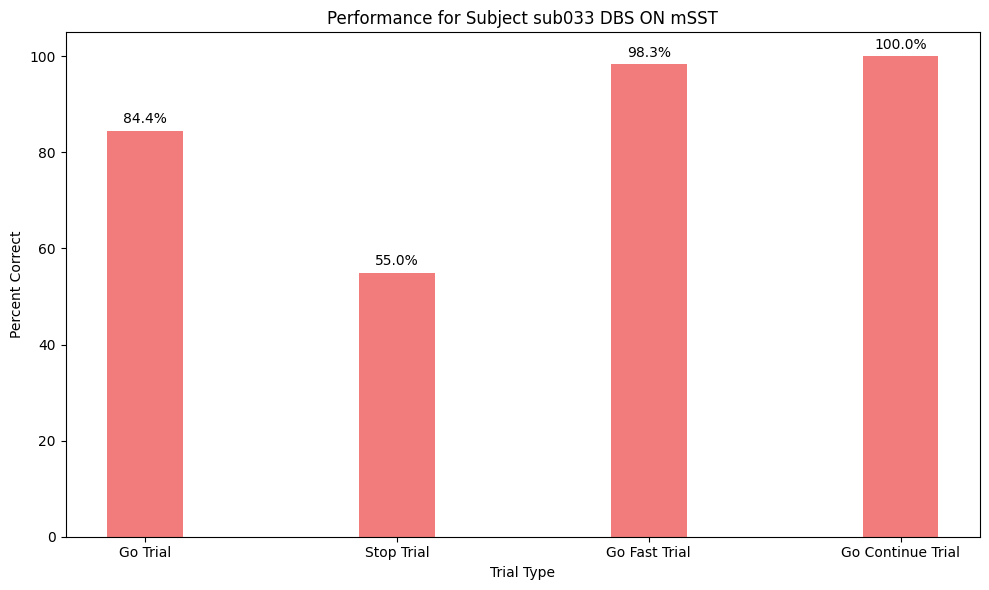

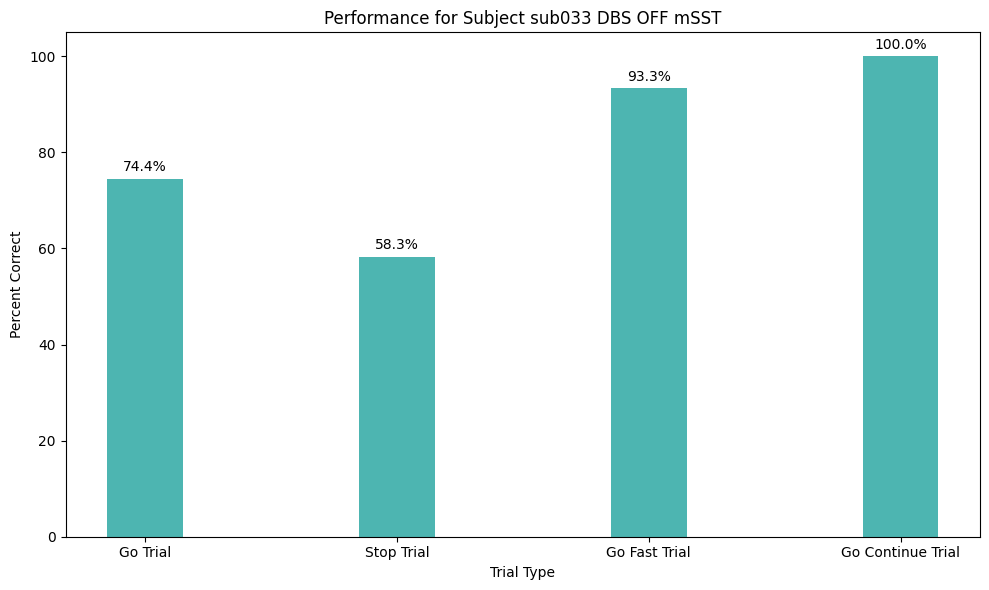

In [34]:
temp_save = join(behav_results_saving_path, "success rate")
if not os.path.isdir(temp_save):
    os.makedirs(temp_save)
excluded_subjects = hrm.check_success_rate(
    stats = stats,
    excluded_subjects = excluded_subjects,
    color_dict = color_dict,
    save_as = save_as,
    saving_path = temp_save,
    show_plot = True
)  

In [35]:
excluded_subjects

['sub024 DBS ON mSST',
 'sub021 DBS ON mSST',
 'C016 mSST',
 'sub008 DBS OFF mSST',
 'sub021 DBS OFF mSST',
 'sub024 DBS OFF mSST',
 'sub009 DBS OFF mSST',
 'sub017 DBS ON mSST',
 'sub009 DBS ON mSST',
 'sub017 DBS OFF mSST',
 'sub008 DBS ON mSST']

# 5. Save excluded and included subjects separately in txt and json files

In [36]:
# save excluded subjects in a txt file
with open(join(behav_results_saving_path, "excluded_subjects.txt"), "w") as f:
    for sub in excluded_subjects:
        f.write(sub + "\n")

# save remaining included_subjects in a txt file and a JSON file
included_subjects = [sub for sub in included_subjects if sub not in excluded_subjects]
with open(join(behav_results_saving_path, "included_subjects.txt"), "w") as f:
    for sub in included_subjects:
        f.write(sub + "\n")      
with open(join(results_path, 'final_included_subjects.json'), 'w') as f:
    json.dump(included_subjects, f, indent=4)
